In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
# import geopandas as gpd

In [2]:
import pandas as pd
import yaml
import json  # Don't forget to import json

with open("params.yaml", "r", encoding="utf-8") as f:
    params = yaml.safe_load(f)

# 1. Define columns to load BEFORE reading the parquet file
date_column = "meta_sale_date"
target_column = "meta_sale_price" # Adjust if your target column is named differently
predictor_cols = list(params["model"]["predictor"]["all"])
categorical_cols = list(params["model"]["predictor"]["categorical"])

# 2. Add the columns we need just for the row filters
filter_cols = ["ind_pin_is_multicard", "sv_is_outlier"]

# 3. Create a unique, consolidated list of columns we actually want to load into RAM
extra_cols = ["meta_class", "meta_triad_name", "meta_sale_deed_type", "sv_review_json"]#, "meta_modeling_group", "meta_sale_deed_type"] #["sv_review_json", "meta_class", "meta_sale_deed_type"]
cols_to_load = list(set(predictor_cols + [target_column, date_column] + filter_cols + extra_cols))

data_path = "./data/CCAO/2025/training_data.parquet"

# FIX: Pass `columns=cols_to_load` to PyArrow. 
df = pd.read_parquet(data_path, engine="pyarrow", columns=cols_to_load)

print("AAAA")
print(df.head())



# Safely filter out multicards and outliers
df = df[
    (df["ind_pin_is_multicard"] != True) & 
    (df["sv_is_outlier"] != True)
].copy()


# # ==========================================
# # --- NEW: PARSE THE sv_review_json DATA ---
# # ==========================================

# def parse_sv_json(json_string):
#     # Handle NAs explicitly
#     if pd.isna(json_string):
#         return {"is_flip": None, "has_class_change": None, 
#                 "has_characteristic_change": None, "is_arms_length": None}
#     else:
#         try:
#             return json.loads(json_string)
#         except json.JSONDecodeError:
#             # Safety catch for any malformed strings
#             return {"is_flip": None, "has_class_change": None, 
#                     "has_characteristic_change": None, "is_arms_length": None}

# # Apply the parser and normalize into columns
# parsed_df = pd.json_normalize(df['sv_review_json'].apply(parse_sv_json))

# # CRITICAL FIX: Align the index of the new columns with the filtered dataframe
# parsed_df.index = df.index

# # Join the new columns back to the main dataframe
# df = pd.concat([df, parsed_df], axis=1)

# # Remove the raw json column from extra_cols since we expanded it
# extra_cols.remove("sv_review_json")
# json_extracted_cols = ["is_flip", "has_class_change", "has_characteristic_change", "is_arms_length"]

# ==========================================


# Ensure the sale date column is a datetime object
df[date_column] = pd.to_datetime(df[date_column], errors="coerce")

# Limit the year to at most 2023 for training, isolate 2024 for out-of-time testing
# df_2024 = df[df[date_column].dt.year == 2024]
# df = df[df[date_column].dt.year <= 2023]

# Now that filtering is done, drop the filter columns so we only have the final keep_cols
# We now include our newly extracted JSON columns in the final keep list
final_keep_cols = list(set(predictor_cols + [target_column, date_column] + extra_cols)) #+ json_extracted_cols))
df = df.loc[:, final_keep_cols]
# df_2024 = df_2024.loc[:, final_keep_cols]

# Take a random sample safely
sample_size = 50000
if len(df) > sample_size:
    df = df.sample(sample_size, random_state=42)
# if len(df_2024) > sample_size:
#     df_2024 = df_2024.sample(sample_size, random_state=42)

AAAA
   char_beds  prox_num_foreclosure_per_1000_pin_past_5_years  \
0        3.0                                           22.23   
1        2.0                                           34.96   
2        2.0                                           34.96   
3        3.0                                           23.33   
4        3.0                                           18.95   

   loc_access_cmap_walk_total_score  meta_sale_price char_type_resd  \
0                              37.5         135000.0              1   
1                              -3.0         100000.0              1   
2                              -3.0         189900.0              1   
3                              16.5          84500.0              1   
4                               7.0         125000.0              4   

   other_tax_bill_rate  prox_nearest_road_arterial_daily_traffic char_apts  \
0               21.672                                   13700.0      NONE   
1               18.116     

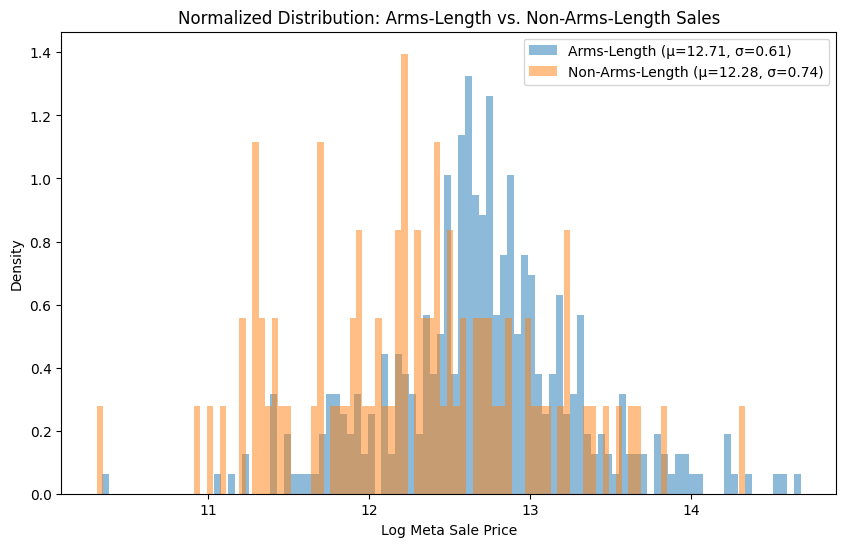

,arms_length_group,count,mean,std,min,25%,50%,75%,max
0,Arms-Length,365.0,12.705611,0.610973,10.341742,12.409013,12.706848,12.999540,14.680508
1,Missing Data,49546.0,12.548131,0.768838,9.210440,12.154779,12.577636,12.977179,15.784719
2,Non-Arms-Length,89.0,12.279223,0.743680,10.308953,11.759786,12.296827,12.751300,14.334304


Clean dataframe shape: (49911, 104)


,char_beds,prox_num_foreclosure_per_1000_pin_past_5_years,loc_access_cmap_walk_total_score,meta_sale_price,char_type_resd,other_tax_bill_rate,prox_nearest_road_arterial_daily_traffic,char_apts,prox_nearest_metra_route_dist_ft,prox_nearest_cemetery_dist_ft,...,char_ncu,time_sale_year,prox_nearest_stadium_dist_ft,prox_nearest_golf_course_dist_ft,char_gar1_size,loc_env_flood_fs_factor,time_sale_post_covid,is_arms_length,arms_length_group,log_price
22228,4.0,79.84,100.5,320000.0,2,7.266,7150.0,NONE,3732.138840,8513.910019,...,0.0,2017.0,11232.002302,12396.584127,1,1.0,False,None,Missing Data,12.676076
158849,4.0,33.15,94.0,292000.0,2,7.020,9100.0,TWO,4036.583207,7594.271063,...,0.0,2025.0,32387.641688,5019.710360,3,1.0,True,None,Missing Data,12.584509
196373,3.0,10.78,75.0,395000.0,1,7.035,16450.0,NONE,4054.867452,3946.565848,...,0.0,2022.0,44468.876711,7098.989604,7,1.0,True,None,Missing Data,12.886641
384639,4.0,6.85,55.0,1120000.0,2,7.923,9150.0,NONE,766.842105,9701.556059,...,0.0,2020.0,62681.441319,4016.181835,3,1.0,True,None,Missing Data,13.928839
125368,3.0,19.68,67.0,210000.0,1,8.055,9900.0,NONE,5807.535046,3369.460936,...,0.0,2017.0,49215.012853,2139.751880,1,1.0,False,None,Missing Data,12.254863
54341,2.0,18.20,41.0,260000.0,1,7.033,18800.0,NONE,3908.649262,9284.864985,...,0.0,2023.0,28391.270608,1130.863906,1,1.0,True,None,Missing Data,12.468437
269053,6.0,40.39,51.0,40000.0,2,27.809,11100.0,THREE,3385.503848,16357.547994,...,0.0,2019.0,70239.285454,11614.520606,3,3.0,False,None,Missing Data,10.596635
181255,4.0,4.04,-1.5,530000.0,1,9.964,32700.0,NONE,8598.215824,5550.112953,...,0.0,2024.0,97120.758347,2995.185017,3,1.0,True,None,Missing Data,13.180632
163442,4.0,13.30,31.5,407000.0,4,8.297,38300.0,NONE,3102.657632,1327.559130,...,0.0,2024.0,56451.890085,3525.117002,3,1.0,True,None,Missing Data,12.916568
390364,2.0,5.98,85.0,228000.0,5,7.033,23800.0,NONE,3347.615876,5962.251873,...,0.0,2023.0,13995.427722,20109.691959,7,4.0,True,None,Missing Data,12.337101


In [3]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def safe_parse_json(val):
    if isinstance(val, dict): return val
    if pd.isna(val) or val in ['None', None]: return {} 
    if isinstance(val, str):
        try: return json.loads(val)
        except json.JSONDecodeError: return {}
    return {}

# 1. Parse JSON and assign it directly to a column so we can group by it
df['is_arms_length'] = df['sv_review_json'].apply(lambda x: safe_parse_json(x).get('is_arms_length'))

# Map to clean labels for the plot/table (treating None as 'Missing')
df['arms_length_group'] = df['is_arms_length'].map({
    True: 'Arms-Length', 
    False: 'Non-Arms-Length'
}).fillna('Missing Data')

# Calculate log price
df['log_price'] = np.log(df['meta_sale_price'])

# 2. Plotting the distributions
plt.figure(figsize=(10, 6))

# Plot only the True/False groups (ignoring missing data for a cleaner chart)
for group_name in ['Arms-Length', 'Non-Arms-Length']:
    group = df[df['arms_length_group'] == group_name]
    
    if not group.empty:
        label_text = f"{group_name} (μ={group['log_price'].mean():.2f}, σ={group['log_price'].std():.2f})"
        plt.hist(group['log_price'], bins=100, alpha=0.5, density=True, label=label_text)

plt.xlabel('Log Meta Sale Price')
plt.ylabel('Density')
plt.title('Normalized Distribution: Arms-Length vs. Non-Arms-Length Sales')
plt.legend()
plt.show()

# 3. Generate the summary statistics table
statistics_table_arms = df.groupby('arms_length_group')['log_price'].describe().reset_index()
display(statistics_table_arms)

# 4. Execute your original filtering logic to create the clean dataset
# (Keeping rows where the flag is NOT False)
df_new = df.loc[df['is_arms_length'] != False].copy()

# Check your results
print(f"Clean dataframe shape: {df_new.shape}")
display(df_new.head(10))

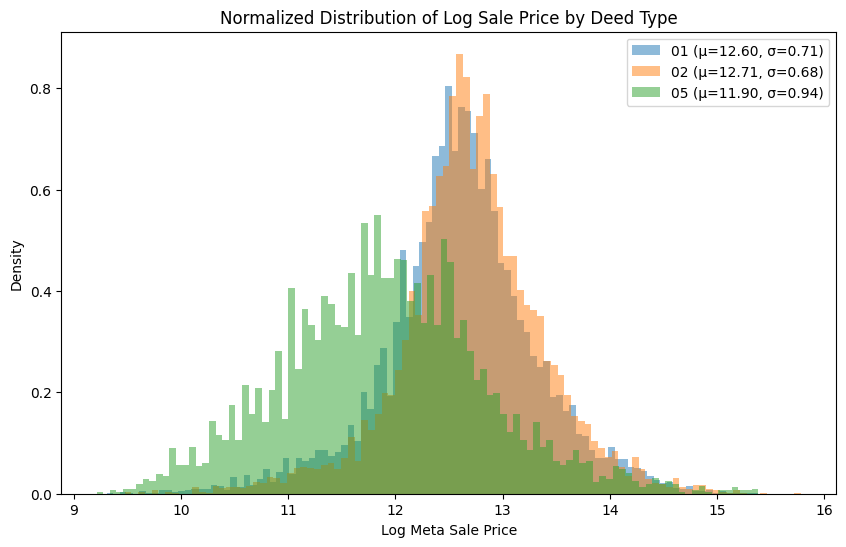

,meta_sale_deed_type,count,mean,std,min,25%,50%,75%,max
0,01,37589.0,12.604899,0.714583,9.305651,12.230765,12.611538,12.994530,15.384126
1,02,7261.0,12.711236,0.676362,9.472705,12.352335,12.696185,13.085699,15.784719
2,05,5061.0,11.903853,0.943225,9.210440,11.288531,11.884489,12.487485,15.384126


In [4]:
# Pre-calculate the log once
df_new['log_price'] = np.log(df_new['meta_sale_price'])

plt.figure(figsize=(10, 6))

for deed_type, group in df_new.groupby('meta_sale_deed_type'):
    label_text = f"{deed_type} (μ={group['log_price'].mean():.2f}, σ={group['log_price'].std():.2f})"
    
    # Added density=True to normalize the distributions
    plt.hist(group['log_price'], bins=100, alpha=0.5, density=True, label=label_text)

plt.xlabel('Log Meta Sale Price')
plt.ylabel('Density') # Changed to reflect normalized data
plt.title('Normalized Distribution of Log Sale Price by Deed Type')
plt.legend()
plt.show()

# Generate the statistics table
statistics_table = df_new.groupby('meta_sale_deed_type')['log_price'].describe().reset_index()
display(statistics_table)

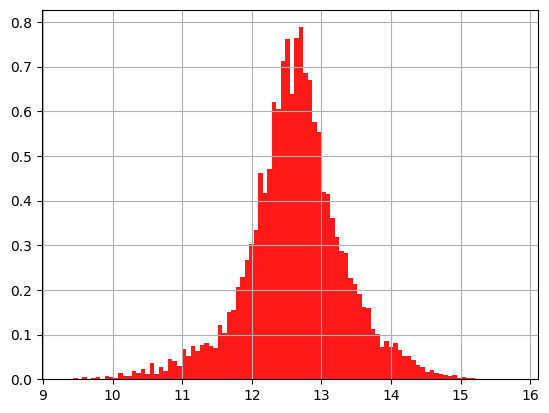

,char_beds,prox_num_foreclosure_per_1000_pin_past_5_years,loc_access_cmap_walk_total_score,meta_sale_price,char_type_resd,other_tax_bill_rate,prox_nearest_road_arterial_daily_traffic,char_apts,prox_nearest_metra_route_dist_ft,prox_nearest_cemetery_dist_ft,...,char_ncu,time_sale_year,prox_nearest_stadium_dist_ft,prox_nearest_golf_course_dist_ft,char_gar1_size,loc_env_flood_fs_factor,time_sale_post_covid,is_arms_length,arms_length_group,log_price
22228,4.0,79.84,100.5,320000.0,2,7.266,7150.0,NONE,3732.138840,8513.910019,...,0.0,2017.0,11232.002302,12396.584127,1,1.0,False,None,Missing Data,12.676076
158849,4.0,33.15,94.0,292000.0,2,7.020,9100.0,TWO,4036.583207,7594.271063,...,0.0,2025.0,32387.641688,5019.710360,3,1.0,True,None,Missing Data,12.584509
196373,3.0,10.78,75.0,395000.0,1,7.035,16450.0,NONE,4054.867452,3946.565848,...,0.0,2022.0,44468.876711,7098.989604,7,1.0,True,None,Missing Data,12.886641
384639,4.0,6.85,55.0,1120000.0,2,7.923,9150.0,NONE,766.842105,9701.556059,...,0.0,2020.0,62681.441319,4016.181835,3,1.0,True,None,Missing Data,13.928839
125368,3.0,19.68,67.0,210000.0,1,8.055,9900.0,NONE,5807.535046,3369.460936,...,0.0,2017.0,49215.012853,2139.751880,1,1.0,False,None,Missing Data,12.254863
54341,2.0,18.20,41.0,260000.0,1,7.033,18800.0,NONE,3908.649262,9284.864985,...,0.0,2023.0,28391.270608,1130.863906,1,1.0,True,None,Missing Data,12.468437
269053,6.0,40.39,51.0,40000.0,2,27.809,11100.0,THREE,3385.503848,16357.547994,...,0.0,2019.0,70239.285454,11614.520606,3,3.0,False,None,Missing Data,10.596635
181255,4.0,4.04,-1.5,530000.0,1,9.964,32700.0,NONE,8598.215824,5550.112953,...,0.0,2024.0,97120.758347,2995.185017,3,1.0,True,None,Missing Data,13.180632
163442,4.0,13.30,31.5,407000.0,4,8.297,38300.0,NONE,3102.657632,1327.559130,...,0.0,2024.0,56451.890085,3525.117002,3,1.0,True,None,Missing Data,12.916568
390364,2.0,5.98,85.0,228000.0,5,7.033,23800.0,NONE,3347.615876,5962.251873,...,0.0,2023.0,13995.427722,20109.691959,7,4.0,True,None,Missing Data,12.337101


In [5]:
# Filter from df_new the deed types to keep inly 01 and 02
df_new_2 = df_new[df_new.meta_sale_deed_type.isin(["01", "02"])].copy()
np.log(df_new_2.meta_sale_price).hist(bins=100, density=True, alpha=0.9, label="01 and 02", color="red")
plt.show()

# df_new_2.drop(columns=["meta_sale_deed_type"], inplace=True)
df_new_2.head(10)

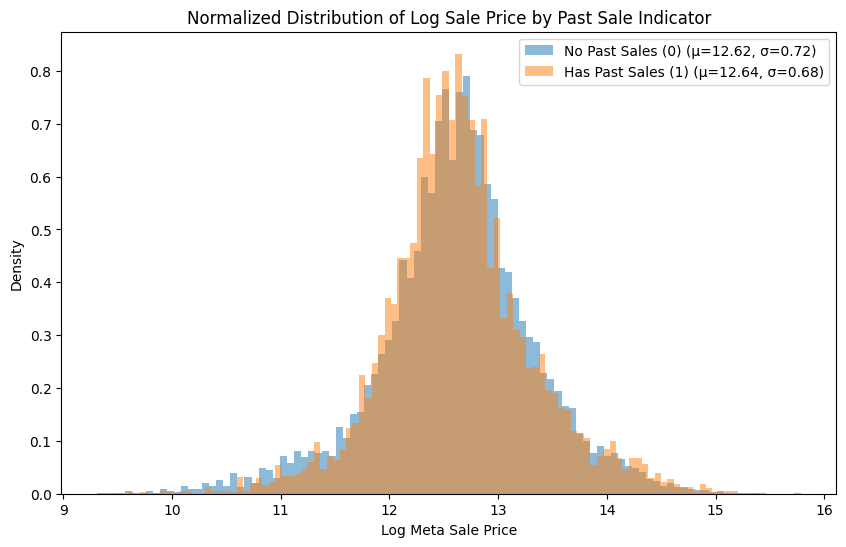

,past_sale_indicator,count,mean,std,min,25%,50%,75%,max
0,0,36475.0,12.618658,0.716882,9.305651,12.254863,12.628067,13.017003,15.784719
1,1,8375.0,12.637169,0.676863,9.472705,12.254863,12.606190,12.983101,15.383084


In [6]:
# 1. Vectorized indicator creation (Magnitudes faster than using .apply with a lambda)
df_new_2['past_sale_indicator'] = (df_new_2['meta_sale_count_past_n_years'] > 0).astype(int)

# 2. Pre-calculate the log price (if you haven't already on this specific dataframe)
df_new_2['log_price'] = np.log(df_new_2['meta_sale_price'])

# 3. Plotting the distributions
plt.figure(figsize=(10, 6))

for indicator, group in df_new_2.groupby('past_sale_indicator'):
    # Define cleaner labels based on the 0/1 values
    label_name = "Has Past Sales (1)" if indicator == 1 else "No Past Sales (0)"
    label_text = f"{label_name} (μ={group['log_price'].mean():.2f}, σ={group['log_price'].std():.2f})"
    
    # Dropped alpha to 0.5 so you can actually see where the distributions overlap
    plt.hist(group['log_price'], bins=100, alpha=0.5, density=True, label=label_text)

plt.xlabel('Log Meta Sale Price')
plt.ylabel('Density')
plt.title('Normalized Distribution of Log Sale Price by Past Sale Indicator')
plt.legend()
plt.show()

# 4. Generate the one-liner statistics table
statistics_table_2 = df_new_2.groupby('past_sale_indicator')['log_price'].describe().reset_index()
display(statistics_table_2)

In [7]:
df_new_2.meta_class.unique()

array(['210', '211', '203', '206', '202', '234', '295', '205', '212',
       '278', '204', '208', '207', '209', '218'], dtype=object)

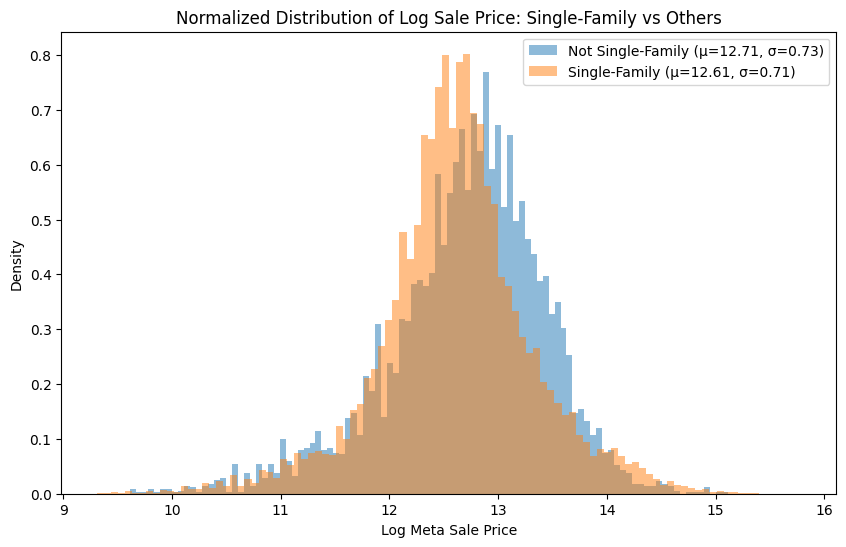

,property_group,count,mean,std,min,25%,50%,75%,max
0,Single-Family,38511.0,12.607614,0.705507,9.305651,12.245293,12.611204,12.971540,15.784719
1,Not Single-Family,6339.0,12.710208,0.727914,9.615805,12.323856,12.779873,13.185807,15.111607


In [8]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

meta_class_group = {
    "202": "Single-family",
    "203": "Single-family",
    "204": "Single-family",
    "205": "Single-family",
    "206": "Single-family",
    "207": "Single-family",
    "208": "Single-family",
    "209": "Single-family",
    "210": "Single-family / townhome-rowhouse",
    "234": "Single-family / split-level",
    "278": "Single-family",
    "295": "Single-family / townhome-rowhouse",
    "211": "Multi-family",
    "212": "Multi-family / mixed-use residential-commercial",
    "218": "Bed & breakfast; treated like single-family for modeling, usually hand-valued",
}

# 1. Map the dictionary to your column (forcing strings to ensure a clean map)
mapped_classes = df_new_2['meta_class'].astype(str).map(meta_class_group)

# 2. Create the binary grouping
# This checks if the mapped description contains the phrase "single-family". 
# If it's missing from the dictionary (NaN) or doesn't contain it, it goes to "Not Single-Family".
df_new_2['property_group'] = np.where(
    mapped_classes.fillna('').str.lower().str.contains('single-family'),
    'Single-Family',
    'Not Single-Family'
)

# Ensure log_price is calculated
if 'log_price' not in df_new_2.columns:
    df_new_2['log_price'] = np.log(df_new_2['meta_sale_price'])

# 3. Plot the distributions
plt.figure(figsize=(10, 6))

for group_name, group in df_new_2.groupby('property_group'):
    label_text = f"{group_name} (μ={group['log_price'].mean():.2f}, σ={group['log_price'].std():.2f})"
    plt.hist(group['log_price'], bins=100, alpha=0.5, density=True, label=label_text)

plt.xlabel('Log Meta Sale Price')
plt.ylabel('Density')
plt.title('Normalized Distribution of Log Sale Price: Single-Family vs Others')
plt.legend()
plt.show()

# 4. Generate the exact same statistics table for the two new groups
statistics_table_group = df_new_2.groupby('property_group')['log_price'].describe().reset_index()

# Sort to show the larger group first
statistics_table_group = statistics_table_group.sort_values(by='count', ascending=False).reset_index(drop=True)
display(statistics_table_group)

In [9]:
# Delete the non-single f# Filter out the non-single-family properties (Keep only 'Single-Family')
df_new_3 = df_new_2.loc[df_new_2['property_group'] == 'Single-Family'].copy()

# Verify the column only contains the intended group
display(df_new_3['property_group'].value_counts())#amily meta_class
df_new_3.drop(columns=["property_group"], inplace=True)

property_group
Single-Family    38511
Name: count, dtype: int64

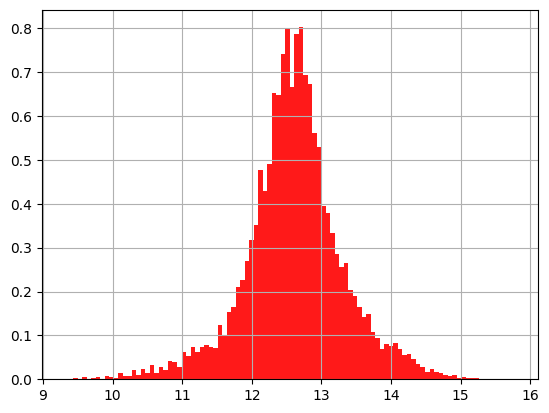

In [10]:
np.log(df_new_3.meta_sale_price).hist(bins=100, density=True, alpha=0.9, label="01 and 02", color="red")
plt.show()

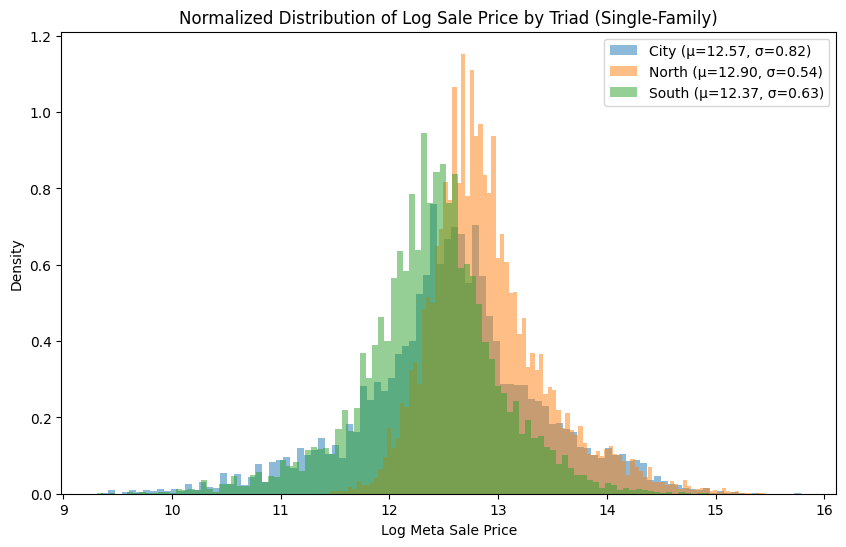

,meta_triad_name,count,mean,std,min,25%,50%,75%,max
0,South,13602.0,12.369149,0.627097,9.305651,12.043554,12.388394,12.724866,14.938815
1,North,12585.0,12.901889,0.535619,11.456905,12.553202,12.815838,13.161584,15.454507
2,City,12324.0,12.570301,0.822111,9.350102,12.144197,12.577636,13.016781,15.784719


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Ensure log_price exists in this specific dataframe
if 'log_price' not in df_new_3.columns:
    df_new_3['log_price'] = np.log(df_new_3['meta_sale_price'])

# 2. Plotting the distributions
plt.figure(figsize=(10, 6))

for triad, group in df_new_3.groupby('meta_triad_name'):
    # Create the label with mean and standard deviation
    label_text = f"{triad} (μ={group['log_price'].mean():.2f}, σ={group['log_price'].std():.2f})"
    
    # Plot the normalized histogram
    plt.hist(group['log_price'], bins=100, alpha=0.5, density=True, label=label_text)

plt.xlabel('Log Meta Sale Price')
plt.ylabel('Density')
plt.title('Normalized Distribution of Log Sale Price by Triad (Single-Family)')
plt.legend()
plt.show()

# 3. Generate the summary statistics table
statistics_table_triad = df_new_3.groupby('meta_triad_name')['log_price'].describe().reset_index()

# Sort by count descending so you can easily see which region has the most sales
statistics_table_triad = statistics_table_triad.sort_values(by='count', ascending=False).reset_index(drop=True)

display(statistics_table_triad)

In [12]:
for col in df_new_3.columns:
    n_unique = df_new_3[col].nunique()
    if n_unique < 10:
        print(col)
        print(df_new_3[col].unique()[:3])
        print(df_new_3[col].nunique())
        # print(df_new_3[col].value_counts())
        # print("\n")
    
# meta_sale_count_past_n_years, char_type_resd, char_apts, char_porch, char_tp_dsgn, char_attic_type, 
# char_recent_renovation, char_fbath, char_heat, char_ext_wall, past_sale_indicator, char_apts, char_bsmt_fin, 
# char_gar1_cnst, char_attic_fnsh, char_gar1_size, char_frpl, char_porch, char_bsmt


# Potential cat: meta_sale_deed_type, char_roof_cnst, char_type_resd, char_recent_renovation, char_gar1_att, 
#   char_air, char_attic_type, char_ext_wall, char_heat, time_sale_post_covid, char_tp_dsgn

# Potential num: char_fbath, char_beds, meta_sale_count_past_n_years

# Leakage: time_sale_quarter_of_year, time_sale_day_of_week, time_sale_year

# Already accounted for: meta_triad_name

char_beds
[4. 3. 2.]
9
char_type_resd
['2', '1', '4']
Categories (6, object): ['1', '2', '3', '4', '5', '9.9']
5
char_apts
['NONE', 'THREE', 'TWO']
Categories (7, object): ['TWO', 'THREE', 'FOUR', 'FIVE', 'SIX', 'UNKNOWN', 'NONE']
3
sv_review_json
[None
 '{"is_flip":false,"has_class_change":false,"has_characteristic_change":"no","is_arms_length":true}'
 '{"is_flip":false,"has_class_change":false,"has_characteristic_change":"yes_minor","is_arms_length":true}']
4
time_sale_quarter_of_year
['Q4' 'Q3' 'Q2']
4
meta_sale_deed_type
['01' '02']
2
char_air
['2', '1', NaN]
Categories (2, object): ['1', '2']
2
char_bsmt
['1', '2', '3']
Categories (4, object): ['1', '2', '3', '4']
4
char_tp_dsgn
['2', NaN, '1']
Categories (2, object): ['1', '2']
2
char_attic_type
['3', '2', '1']
Categories (3, object): ['1', '2', '3']
3
char_bsmt_fin
['3', '1', '2']
Categories (3, object): ['1', '2', '3']
3
time_sale_day_of_week
[5 3 4]
7
char_frpl
[0. 1. 2.]
8
char_attic_fnsh
['3', '1', NaN]
Categories (3, object

0


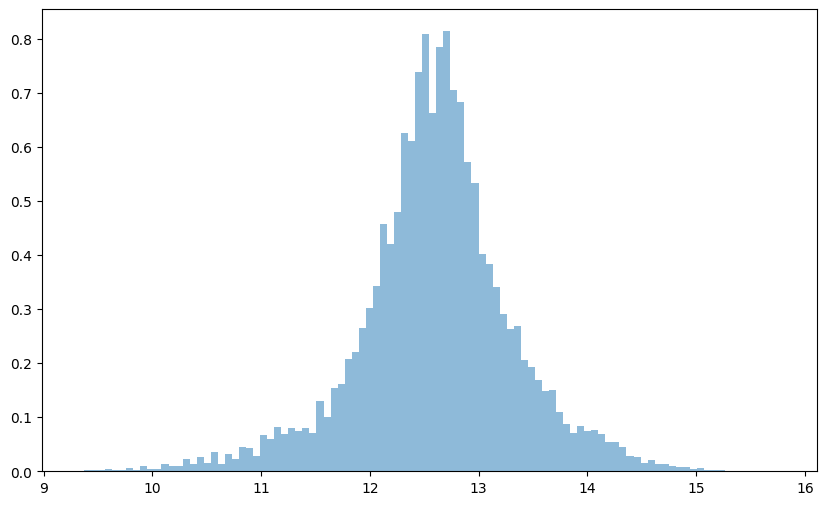

1


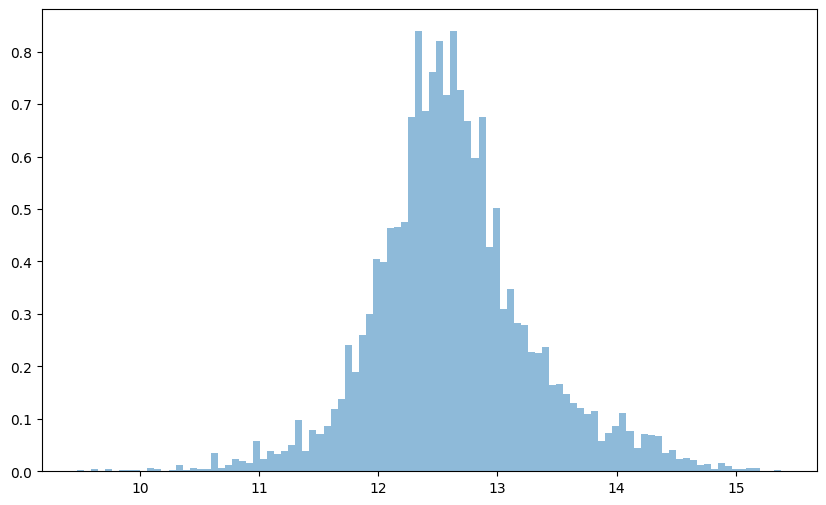

In [13]:
for level in df_new_3["past_sale_indicator"].unique():
    print(level)
    plt.figure(figsize=(10, 6))
    plt.hist(np.log(df_new_3[df_new_3["past_sale_indicator"] == level]["meta_sale_price"]), bins=100, alpha=0.5, density=True)
    plt.show()



In [ ]:
# Delete the extra columns 
df_new_4 = df_new_3.copy()
try:
    df.drop(columns=extra_cols, inplace=True) # Dataset with all the columns
    df_new.drop(columns=extra_cols, inplace=True) # Dataset filtered by no arms-length
    df_new_2.drop(columns=extra_cols, inplace=True) # Dataset filtered by no arms-length and deed type
    df_new_3.drop(columns=extra_cols, inplace=True) # Dataset filtered by deed type and no arms-length, and single-family
    df_new_4.drop(columns=extra_cols, inplace=True) # Dataset filtered by deed type and no arms-length, and single-family, and k-nearest neighbors

except:
    pass

# List of datasets to run the models on
datasets = [df, df_new, df_new_2, df_new_3]#, df_new_4] + [df_new_4] * 6


In [ ]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.neighbors import NearestNeighbors
from collections import defaultdict



class GeoKernelTargetNeighbors(BaseEstimator, TransformerMixin):
    """
    Spatial kernel target-neighbor transformer.

    Fits a neighbor database on X_train and y_train.
    Then transforms train/test rows using only y_train neighbor values.

    Supports:
      1. Categorical hard filters:
         - one-hot encoded roots, e.g. char_class_202, char_class_203, ...
         - binary columns, e.g. past_sale_indicator
         - sklearn/ColumnTransformer-prefixed names, e.g.
           categorical__past_sale_indicator or onehot__char_class_202

      2. Geographic candidate search:
         - neighbors are first queried by geographic Haversine distance.

      3. Optional numeric composite reranking:
         - if numeric_similarity_cols is provided, retrieve an extended
           geographic neighborhood, then rerank candidates by a composite score
           using geographic distance plus standardized numeric-feature distance.

      4. Optional time-decay weighting:
         - if use_time_decay=True, multiply distance-kernel weights by a
           time-distance kernel based on time_col.

    Output:
      geo_neighbor_1_kernel_weighted_target
      ...
      geo_neighbor_k_kernel_weighted_target
      geo_local_kernel_target_mean, if include_aggregate=True
    """

    def __init__(
        self,
        k=5,
        lat_col="loc_latitude",
        lon_col="loc_longitude",
        kernel="gaussian",
        bandwidth="adaptive",
        bandwidth_scale=1.0,
        normalize_weights=True,
        exclude_self=True,
        target_transform=None,
        include_aggregate=True,
        feature_prefix="geo",
        min_bandwidth_km=1e-6,

        # Categorical filtering
        categorical_filter_roots=None,
        one_hot_sep="_",
        one_hot_threshold=0.5,
        filter_fallback="global",
        include_diagnostics=False,
        handle_missing_category=True,
        missing_category_label="__MISSING__",
        allow_binary_filter=True,

        # Numeric composite reranking
        numeric_similarity_cols=None,
        numeric_similarity_weights=None,
        numeric_scaling="standard",       # "standard", "robust", or None
        numeric_distance_weight=1.0,
        geo_distance_weight=1.0,
        candidate_k=None,                 # if None and numeric cols are used, defaults to 5*k

        # Optional time decay
        time_col=None,
        use_time_decay=False,
        time_kernel="exponential",        # "exponential", "gaussian", or "linear"
        time_bandwidth_days=365.0,
    ):
        self.k = k
        self.lat_col = lat_col
        self.lon_col = lon_col
        self.kernel = kernel
        self.bandwidth = bandwidth
        self.bandwidth_scale = bandwidth_scale
        self.normalize_weights = normalize_weights
        self.exclude_self = exclude_self
        self.target_transform = target_transform
        self.include_aggregate = include_aggregate
        self.feature_prefix = feature_prefix
        self.min_bandwidth_km = min_bandwidth_km

        self.categorical_filter_roots = categorical_filter_roots
        self.one_hot_sep = one_hot_sep
        self.one_hot_threshold = one_hot_threshold
        self.filter_fallback = filter_fallback
        self.include_diagnostics = include_diagnostics
        self.handle_missing_category = handle_missing_category
        self.missing_category_label = missing_category_label
        self.allow_binary_filter = allow_binary_filter

        self.numeric_similarity_cols = numeric_similarity_cols
        self.numeric_similarity_weights = numeric_similarity_weights
        self.numeric_scaling = numeric_scaling
        self.numeric_distance_weight = numeric_distance_weight
        self.geo_distance_weight = geo_distance_weight
        self.candidate_k = candidate_k

        self.time_col = time_col
        self.use_time_decay = use_time_decay
        self.time_kernel = time_kernel
        self.time_bandwidth_days = time_bandwidth_days

    def fit(self, X_train, y_train):
        X_train = X_train.copy()
        y_train = self._prepare_y(y_train, X_train.index)

        self._validate_init_params()
        self._setup_filter_columns(X_train)
        self._setup_numeric_similarity(X_train)
        self._setup_time_values(X_train)
        self._validate_X(X_train, require_filter_cols=True)

        n_train = len(X_train)

        if self.k < 1:
            raise ValueError("k must be >= 1.")

        if self.exclude_self and self.k >= n_train:
            raise ValueError("With exclude_self=True, k must be < len(X_train).")

        if not self.exclude_self and self.k > n_train:
            raise ValueError("k must be <= len(X_train).")

        if not X_train.index.is_unique:
            raise ValueError(
                "X_train.index must be unique. This is needed to safely exclude "
                "the training row itself when transforming X_train."
            )

        self.train_index_ = X_train.index.copy()
        self.index_to_train_pos_ = {
            idx: pos for pos, idx in enumerate(self.train_index_)
        }

        self.y_train_ = y_train.to_numpy(dtype=float)

        self.train_coords_rad_ = np.radians(
            X_train[[self.lat_col, self.lon_col]].to_numpy(dtype=float)
        )

        self.global_train_pos_ = np.arange(n_train, dtype=int)

        self.global_nn_ = NearestNeighbors(
            metric="haversine",
            algorithm="ball_tree",
        )
        self.global_nn_.fit(self.train_coords_rad_)

        self.group_models_ = {}
        self.train_filter_keys_ = None

        if self.filter_roots_:
            self.train_filter_keys_ = self._make_filter_keys(X_train)

            group_to_positions = defaultdict(list)

            for train_pos, key in enumerate(self.train_filter_keys_):
                if key is not None:
                    group_to_positions[key].append(train_pos)

            for key, positions in group_to_positions.items():
                positions = np.asarray(positions, dtype=int)

                nn = NearestNeighbors(
                    metric="haversine",
                    algorithm="ball_tree",
                )
                nn.fit(self.train_coords_rad_[positions])

                self.group_models_[key] = {
                    "nn": nn,
                    "train_pos": positions,
                }

        return self

    def transform(self, X):
        X = X.copy()

        self._validate_is_fitted()
        self._validate_X(X, require_filter_cols=True)

        query_coords_rad = np.radians(
            X[[self.lat_col, self.lon_col]].to_numpy(dtype=float)
        )

        query_numeric_scaled = self._transform_numeric_similarity(X)
        query_time_days = self._transform_time_values(X)

        if self.filter_roots_:
            query_filter_keys = self._make_filter_keys(X)
        else:
            query_filter_keys = [None] * len(X)

        distances_km = np.empty((len(X), self.k), dtype=float)
        neighbor_pos = np.empty((len(X), self.k), dtype=int)

        used_filtered_pool = np.zeros(len(X), dtype=int)
        pool_size_used = np.zeros(len(X), dtype=int)
        candidate_pool_size_used = np.zeros(len(X), dtype=int)

        for row_idx, original_index in enumerate(X.index):
            key = query_filter_keys[row_idx]
            query_coord = query_coords_rad[row_idx]

            query_num = None
            if self.numeric_similarity_enabled_:
                query_num = query_numeric_scaled[row_idx]

            query_time = None
            if self.time_decay_enabled_:
                query_time = query_time_days[row_idx]

            d_row, n_row, used_filter, pool_size, candidate_pool_size = (
                self._query_neighbors_one_row(
                    query_coord_rad=query_coord,
                    query_index=original_index,
                    filter_key=key,
                    query_numeric_scaled=query_num,
                    query_time_days=query_time,
                )
            )

            distances_km[row_idx] = d_row
            neighbor_pos[row_idx] = n_row
            used_filtered_pool[row_idx] = int(used_filter)
            pool_size_used[row_idx] = int(pool_size)
            candidate_pool_size_used[row_idx] = int(candidate_pool_size)

        weights = self._kernel_weights(distances_km)

        if self.time_decay_enabled_:
            time_weights = self._time_decay_weights_for_neighbors(
                query_time_days=query_time_days,
                neighbor_pos=neighbor_pos,
            )
            weights = weights * time_weights

        if self.normalize_weights:
            row_sums = weights.sum(axis=1, keepdims=True)
            weights = np.divide(
                weights,
                row_sums,
                out=np.zeros_like(weights),
                where=row_sums > 0,
            )

        neighbor_targets = self.y_train_[neighbor_pos]
        weighted_targets = weights * neighbor_targets

        out = pd.DataFrame(index=X.index)

        for j in range(self.k):
            out[f"{self.feature_prefix}_neighbor_{j + 1}_kernel_weighted_target"] = (
                weighted_targets[:, j]
            )

        if self.include_aggregate:
            out[f"{self.feature_prefix}_local_kernel_target_mean"] = (
                weighted_targets.sum(axis=1)
            )

        if self.include_diagnostics:
            out[f"{self.feature_prefix}_used_filtered_pool"] = used_filtered_pool
            out[f"{self.feature_prefix}_neighbor_pool_size"] = pool_size_used
            out[f"{self.feature_prefix}_candidate_pool_size"] = candidate_pool_size_used

        return out

    def fit_transform_train_test(self, X_train, X_test, y_train):
        self.fit(X_train, y_train)

        train_features = self.transform(X_train)
        test_features = self.transform(X_test)

        return train_features, test_features

    # ------------------------------------------------------------------
    # Neighbor querying
    # ------------------------------------------------------------------

    def _query_neighbors_one_row(
        self,
        query_coord_rad,
        query_index,
        filter_key,
        query_numeric_scaled=None,
        query_time_days=None,
    ):
        if self.filter_roots_ and filter_key is not None and filter_key in self.group_models_:
            group = self.group_models_[filter_key]

            result = self._query_from_pool(
                nn=group["nn"],
                pool_train_pos=group["train_pos"],
                query_coord_rad=query_coord_rad,
                query_index=query_index,
                query_numeric_scaled=query_numeric_scaled,
                query_time_days=query_time_days,
            )

            if result is not None:
                d_row, n_row, candidate_pool_size = result
                return d_row, n_row, True, len(group["train_pos"]), candidate_pool_size

        if self.filter_roots_ and self.filter_fallback == "raise":
            raise RuntimeError(
                "Could not find enough filtered neighbors for at least one row. "
                "Use a coarser categorical filter, reduce k, or set "
                "filter_fallback='global'."
            )

        result = self._query_from_pool(
            nn=self.global_nn_,
            pool_train_pos=self.global_train_pos_,
            query_coord_rad=query_coord_rad,
            query_index=query_index,
            query_numeric_scaled=query_numeric_scaled,
            query_time_days=query_time_days,
        )

        if result is None:
            raise RuntimeError(
                "Could not find enough global neighbors. "
                "Reduce k or check the training data size."
            )

        d_row, n_row, candidate_pool_size = result
        return d_row, n_row, False, len(self.global_train_pos_), candidate_pool_size

    def _query_from_pool(
        self,
        nn,
        pool_train_pos,
        query_coord_rad,
        query_index,
        query_numeric_scaled=None,
        query_time_days=None,
    ):
        pool_size = len(pool_train_pos)

        self_train_pos = self._get_self_train_pos_if_same_training_row(
            query_index=query_index,
            query_coord_rad=query_coord_rad,
        )

        self_in_pool = (
            self_train_pos is not None
            and np.any(pool_train_pos == self_train_pos)
        )

        extra_for_self = int(self.exclude_self and self_in_pool)

        if self.numeric_similarity_enabled_:
            n_raw_requested = self.candidate_k_ + extra_for_self
        else:
            n_raw_requested = self.k + extra_for_self

        n_raw_min_needed = self.k + extra_for_self

        if pool_size < n_raw_min_needed:
            return None

        n_query = min(pool_size, n_raw_requested)

        distances_rad, local_neighbor_idx = nn.kneighbors(
            query_coord_rad.reshape(1, -1),
            n_neighbors=n_query,
        )

        distances_km = distances_rad[0] * 6371.0088
        neighbor_train_pos = pool_train_pos[local_neighbor_idx[0]]

        if self.exclude_self and self_in_pool:
            keep = neighbor_train_pos != self_train_pos
            distances_km = distances_km[keep]
            neighbor_train_pos = neighbor_train_pos[keep]

        if len(neighbor_train_pos) < self.k:
            return None

        candidate_pool_size = len(neighbor_train_pos)

        if self.numeric_similarity_enabled_:
            order = self._composite_rerank_order(
                query_numeric_scaled=query_numeric_scaled,
                candidate_train_pos=neighbor_train_pos,
                candidate_geo_distances_km=distances_km,
            )

            distances_km = distances_km[order]
            neighbor_train_pos = neighbor_train_pos[order]

        return (
            distances_km[: self.k],
            neighbor_train_pos[: self.k],
            candidate_pool_size,
        )

    def _get_self_train_pos_if_same_training_row(self, query_index, query_coord_rad):
        train_pos = self.index_to_train_pos_.get(query_index, None)

        if train_pos is None:
            return None

        same_coordinates = np.allclose(
            query_coord_rad,
            self.train_coords_rad_[train_pos],
            rtol=0.0,
            atol=1e-12,
        )

        if same_coordinates:
            return train_pos

        return None

    # ------------------------------------------------------------------
    # Numeric composite reranking
    # ------------------------------------------------------------------

    def _setup_numeric_similarity(self, X_train):
        cols = self.numeric_similarity_cols

        if cols is None:
            cols = []

        if isinstance(cols, str):
            cols = [cols]

        self.numeric_similarity_cols_ = list(cols)
        self.numeric_similarity_enabled_ = len(self.numeric_similarity_cols_) > 0

        if not self.numeric_similarity_enabled_:
            self.numeric_similarity_actual_cols_ = []
            self.train_numeric_scaled_ = None
            self.numeric_weights_ = None
            self.candidate_k_ = self.k
            return

        self.numeric_similarity_actual_cols_ = self._resolve_semantic_columns(
            X_train,
            self.numeric_similarity_cols_,
            purpose="numeric_similarity_cols",
        )

        raw = X_train[self.numeric_similarity_actual_cols_].apply(
            pd.to_numeric,
            errors="coerce",
        )

        if self.numeric_scaling == "standard":
            center = raw.mean(axis=0)
            scale = raw.std(axis=0, ddof=0)

        elif self.numeric_scaling == "robust":
            center = raw.median(axis=0)
            q75 = raw.quantile(0.75, axis=0)
            q25 = raw.quantile(0.25, axis=0)
            scale = q75 - q25

        elif self.numeric_scaling is None:
            center = pd.Series(0.0, index=raw.columns)
            scale = pd.Series(1.0, index=raw.columns)

        else:
            raise ValueError("numeric_scaling must be 'standard', 'robust', or None.")

        scale = scale.replace(0.0, np.nan).fillna(1.0)

        self.numeric_center_ = center.astype(float)
        self.numeric_scale_ = scale.astype(float)

        filled = raw.fillna(self.numeric_center_)
        self.train_numeric_scaled_ = (
            (filled - self.numeric_center_) / self.numeric_scale_
        ).to_numpy(dtype=float)

        self.numeric_weights_ = self._build_numeric_weights(
            requested_cols=self.numeric_similarity_cols_,
            actual_cols=self.numeric_similarity_actual_cols_,
        )

        if self.candidate_k is None:
            self.candidate_k_ = max(self.k, 5 * self.k)
        else:
            self.candidate_k_ = max(self.k, int(self.candidate_k))

    def _transform_numeric_similarity(self, X):
        if not self.numeric_similarity_enabled_:
            return None

        raw = X[self.numeric_similarity_actual_cols_].apply(
            pd.to_numeric,
            errors="coerce",
        )

        filled = raw.fillna(self.numeric_center_)
        scaled = (filled - self.numeric_center_) / self.numeric_scale_

        return scaled.to_numpy(dtype=float)

    def _build_numeric_weights(self, requested_cols, actual_cols):
        q = len(actual_cols)

        if self.numeric_similarity_weights is None:
            weights = np.ones(q, dtype=float)

        elif isinstance(self.numeric_similarity_weights, dict):
            weights = []

            for requested_col, actual_col in zip(requested_cols, actual_cols):
                semantic_actual = self._strip_transformer_prefix(actual_col)

                value = (
                    self.numeric_similarity_weights.get(requested_col, None)
                )

                if value is None:
                    value = self.numeric_similarity_weights.get(semantic_actual, 1.0)

                weights.append(float(value))

            weights = np.asarray(weights, dtype=float)

        else:
            weights = np.asarray(self.numeric_similarity_weights, dtype=float)

            if weights.shape[0] != q:
                raise ValueError(
                    "numeric_similarity_weights must have the same length as "
                    "numeric_similarity_cols."
                )

        if np.any(~np.isfinite(weights)):
            raise ValueError("numeric_similarity_weights contains non-finite values.")

        if np.any(weights < 0):
            raise ValueError("numeric_similarity_weights must be nonnegative.")

        if np.all(weights == 0):
            raise ValueError("At least one numeric similarity weight must be positive.")

        weights = weights / np.mean(weights[weights > 0])

        return weights

    def _composite_rerank_order(
        self,
        query_numeric_scaled,
        candidate_train_pos,
        candidate_geo_distances_km,
    ):
        if query_numeric_scaled is None:
            return np.arange(len(candidate_train_pos))

        candidate_numeric = self.train_numeric_scaled_[candidate_train_pos]

        diff = candidate_numeric - query_numeric_scaled.reshape(1, -1)

        numeric_dist_sq = np.average(
            diff ** 2,
            axis=1,
            weights=self.numeric_weights_,
        )

        geo_scale = self._geo_scale_for_reranking(candidate_geo_distances_km)
        geo_dist_norm = candidate_geo_distances_km / geo_scale

        composite_score = (
            float(self.geo_distance_weight) * (geo_dist_norm ** 2)
            + float(self.numeric_distance_weight) * numeric_dist_sq
        )

        return np.argsort(composite_score, kind="mergesort")

    def _geo_scale_for_reranking(self, candidate_geo_distances_km):
        if self.bandwidth == "adaptive":
            positive = candidate_geo_distances_km[candidate_geo_distances_km > 0]

            if positive.size == 0:
                scale = float(self.min_bandwidth_km)
            else:
                scale = float(np.max(positive)) * float(self.bandwidth_scale)

        else:
            scale = float(self.bandwidth)

        return max(scale, float(self.min_bandwidth_km))

    # ------------------------------------------------------------------
    # Time decay
    # ------------------------------------------------------------------

    def _setup_time_values(self, X_train):
        self.time_decay_enabled_ = bool(self.use_time_decay)

        if not self.time_decay_enabled_:
            self.time_actual_col_ = None
            self.train_time_days_ = None
            return

        if self.time_col is None:
            raise ValueError("time_col must be provided when use_time_decay=True.")

        self.time_actual_col_ = self._resolve_semantic_columns(
            X_train,
            [self.time_col],
            purpose="time_col",
        )[0]

        self.train_time_days_ = self._coerce_time_to_days(
            X_train[self.time_actual_col_]
        )

    def _transform_time_values(self, X):
        if not self.time_decay_enabled_:
            return None

        return self._coerce_time_to_days(X[self.time_actual_col_])

    def _coerce_time_to_days(self, series):
        dt = pd.to_datetime(series, errors="coerce")

        if dt.isna().any():
            bad_count = int(dt.isna().sum())
            raise ValueError(f"time_col contains {bad_count} invalid or missing dates.")

        return (dt.astype("int64") / (1e9 * 60 * 60 * 24)).to_numpy(dtype=float)

    def _time_decay_weights_for_neighbors(self, query_time_days, neighbor_pos):
        query_time = query_time_days.reshape(-1, 1)
        neighbor_time = self.train_time_days_[neighbor_pos]

        delta_days = np.abs(query_time - neighbor_time)

        h = float(self.time_bandwidth_days)

        if h <= 0:
            raise ValueError("time_bandwidth_days must be positive.")

        u = delta_days / h

        if self.time_kernel == "exponential":
            return np.exp(-u)

        if self.time_kernel == "gaussian":
            return np.exp(-0.5 * u ** 2)

        if self.time_kernel == "linear":
            return np.maximum(0.0, 1.0 - u)

        raise ValueError(
            "time_kernel must be one of: 'exponential', 'gaussian', or 'linear'."
        )

    # ------------------------------------------------------------------
    # Categorical filtering
    # ------------------------------------------------------------------

    def _setup_filter_columns(self, X_train):
        roots = self.categorical_filter_roots

        if roots is None:
            roots = []

        if isinstance(roots, str):
            roots = [roots]

        self.filter_roots_ = list(roots)

        self.filter_columns_by_root_ = {}
        self.filter_mode_by_root_ = {}

        semantic_name_by_col = {
            col: self._strip_transformer_prefix(col)
            for col in X_train.columns
        }

        self.filter_semantic_name_by_col_ = semantic_name_by_col

        for root in self.filter_roots_:
            prefix = f"{root}{self.one_hot_sep}"

            one_hot_cols = [
                col
                for col, semantic_col in semantic_name_by_col.items()
                if semantic_col.startswith(prefix)
            ]

            one_hot_cols = sorted(
                one_hot_cols,
                key=lambda c: semantic_name_by_col[c],
            )

            binary_cols = [
                col
                for col, semantic_col in semantic_name_by_col.items()
                if semantic_col == root
            ]

            binary_cols = sorted(binary_cols)

            if one_hot_cols:
                self.filter_columns_by_root_[root] = one_hot_cols
                self.filter_mode_by_root_[root] = "one_hot"

            elif self.allow_binary_filter and binary_cols:
                if len(binary_cols) > 1:
                    raise ValueError(
                        f"Multiple binary-style columns found for root '{root}': "
                        f"{binary_cols}. Please pass a more specific root or "
                        "clean duplicate transformed column names."
                    )

                self.filter_columns_by_root_[root] = [binary_cols[0]]
                self.filter_mode_by_root_[root] = "binary"

            else:
                candidates = [
                    col
                    for col, semantic_col in semantic_name_by_col.items()
                    if root in semantic_col or root in str(col)
                ]

                raise ValueError(
                    f"No valid categorical filter columns found for root '{root}'. "
                    f"Expected either one-hot columns with semantic names starting "
                    f"with '{prefix}' or a binary column with semantic name exactly "
                    f"'{root}'. Candidate similar columns found: {candidates[:20]}"
                )

    def _make_filter_keys(self, X):
        if not self.filter_roots_:
            return [None] * len(X)

        keys = []

        for _, row in X.iterrows():
            key_parts = []
            valid = True

            for root in self.filter_roots_:
                mode = self.filter_mode_by_root_[root]
                cols = self.filter_columns_by_root_[root]

                if mode == "one_hot":
                    values = (
                        pd.to_numeric(row[cols], errors="coerce")
                        .fillna(0.0)
                        .to_numpy(dtype=float)
                    )

                    active = np.flatnonzero(values > float(self.one_hot_threshold))

                    if len(active) == 1:
                        active_col = cols[int(active[0])]
                        semantic_active_col = self._strip_transformer_prefix(active_col)
                        key_parts.append(semantic_active_col)

                    elif len(active) == 0:
                        if self.handle_missing_category:
                            missing_key = (
                                f"{root}{self.one_hot_sep}"
                                f"{self.missing_category_label}"
                            )
                            key_parts.append(missing_key)
                        else:
                            valid = False
                            break

                    else:
                        valid = False
                        break

                elif mode == "binary":
                    col = cols[0]
                    value = self._coerce_binary_value(row[col])

                    if np.isnan(value):
                        if self.handle_missing_category:
                            missing_key = (
                                f"{root}{self.one_hot_sep}"
                                f"{self.missing_category_label}"
                            )
                            key_parts.append(missing_key)
                        else:
                            valid = False
                            break

                    else:
                        binary_level = int(value > float(self.one_hot_threshold))
                        binary_key = f"{root}{self.one_hot_sep}{binary_level}"
                        key_parts.append(binary_key)

                else:
                    raise RuntimeError(f"Unknown filter mode for root '{root}': {mode}")

            if valid:
                keys.append(tuple(key_parts))
            else:
                keys.append(None)

        return keys

    def _strip_transformer_prefix(self, col):
        col = str(col)

        if "__" in col:
            return col.split("__")[-1]

        return col

    def _coerce_binary_value(self, value):
        if pd.isna(value):
            return np.nan

        if isinstance(value, (bool, np.bool_)):
            return float(value)

        if isinstance(value, str):
            s = value.strip().lower()

            if s in {"1", "true", "t", "yes", "y"}:
                return 1.0

            if s in {"0", "false", "f", "no", "n"}:
                return 0.0

        numeric = pd.to_numeric(value, errors="coerce")

        if pd.isna(numeric):
            return np.nan

        return float(numeric)

    # ------------------------------------------------------------------
    # Kernel and bandwidth
    # ------------------------------------------------------------------

    def _kernel_weights(self, distances_km):
        h = self._bandwidth(distances_km)
        u = distances_km / h

        if self.kernel == "gaussian":
            return np.exp(-0.5 * u ** 2)

        if self.kernel == "exponential":
            return np.exp(-u)

        if self.kernel == "epanechnikov":
            return np.maximum(0.0, 1.0 - u ** 2)

        if self.kernel == "triangular":
            return np.maximum(0.0, 1.0 - u)

        raise ValueError(
            "kernel must be one of: 'gaussian', 'exponential', "
            "'epanechnikov', or 'triangular'."
        )

    def _bandwidth(self, distances_km):
        if self.bandwidth == "adaptive":
            h = distances_km[:, [-1]] * float(self.bandwidth_scale)
        else:
            h = float(self.bandwidth) * np.ones((distances_km.shape[0], 1))

        return np.maximum(h, float(self.min_bandwidth_km))

    # ------------------------------------------------------------------
    # General validation and utilities
    # ------------------------------------------------------------------

    def _prepare_y(self, y, index):
        if isinstance(y, pd.Series):
            y = y.reindex(index)
        else:
            y = pd.Series(y, index=index)

        if y.isna().any():
            raise ValueError("y_train contains missing values.")

        y = y.astype(float)

        if self.target_transform == "log":
            if (y <= 0).any():
                raise ValueError(
                    "Cannot apply log transform because y_train has nonpositive values."
                )
            y = np.log(y)

        elif self.target_transform is None:
            pass

        else:
            raise ValueError("target_transform must be None or 'log'.")

        return y

    def _resolve_semantic_columns(self, X, requested_cols, purpose):
        semantic_name_by_col = {
            col: self._strip_transformer_prefix(col)
            for col in X.columns
        }

        resolved = []

        for requested in requested_cols:
            matches = [
                col
                for col, semantic_col in semantic_name_by_col.items()
                if semantic_col == requested
            ]

            if len(matches) == 1:
                resolved.append(matches[0])

            elif len(matches) > 1:
                raise ValueError(
                    f"Multiple columns match {purpose}='{requested}': {matches}. "
                    "Please disambiguate the transformed column names."
                )

            else:
                candidates = [
                    col
                    for col, semantic_col in semantic_name_by_col.items()
                    if requested in semantic_col or requested in str(col)
                ]

                raise ValueError(
                    f"Could not find column '{requested}' for {purpose}. "
                    f"Candidate similar columns: {candidates[:20]}"
                )

        return resolved

    def _validate_init_params(self):
        if self.filter_fallback not in {"global", "raise"}:
            raise ValueError("filter_fallback must be either 'global' or 'raise'.")

        if float(self.one_hot_threshold) < 0:
            raise ValueError("one_hot_threshold must be nonnegative.")

        if not isinstance(self.handle_missing_category, bool):
            raise ValueError("handle_missing_category must be True or False.")

        if not isinstance(self.missing_category_label, str) or not self.missing_category_label:
            raise ValueError("missing_category_label must be a non-empty string.")

        if not isinstance(self.allow_binary_filter, bool):
            raise ValueError("allow_binary_filter must be True or False.")

        if float(self.numeric_distance_weight) < 0:
            raise ValueError("numeric_distance_weight must be nonnegative.")

        if float(self.geo_distance_weight) < 0:
            raise ValueError("geo_distance_weight must be nonnegative.")

        if float(self.numeric_distance_weight) == 0 and float(self.geo_distance_weight) == 0:
            raise ValueError(
                "At least one of numeric_distance_weight or geo_distance_weight "
                "must be positive."
            )

        if self.candidate_k is not None and int(self.candidate_k) < int(self.k):
            raise ValueError("candidate_k must be >= k.")

        if self.time_kernel not in {"exponential", "gaussian", "linear"}:
            raise ValueError(
                "time_kernel must be one of: 'exponential', 'gaussian', or 'linear'."
            )

        if bool(self.use_time_decay) and float(self.time_bandwidth_days) <= 0:
            raise ValueError("time_bandwidth_days must be positive.")

    def _validate_X(self, X, require_filter_cols):
        missing = [c for c in [self.lat_col, self.lon_col] if c not in X.columns]

        if missing:
            raise ValueError(f"Missing required columns: {missing}")

        if X[[self.lat_col, self.lon_col]].isna().any().any():
            raise ValueError("Latitude/longitude columns contain missing values.")

        if require_filter_cols and hasattr(self, "filter_columns_by_root_"):
            required_filter_cols = [
                col
                for cols in self.filter_columns_by_root_.values()
                for col in cols
            ]

            missing_filter_cols = [
                c for c in required_filter_cols
                if c not in X.columns
            ]

            if missing_filter_cols:
                raise ValueError(
                    "X is missing categorical filter columns that were present "
                    f"during fit: {missing_filter_cols[:10]}"
                )

        if hasattr(self, "numeric_similarity_actual_cols_"):
            missing_numeric_cols = [
                c for c in self.numeric_similarity_actual_cols_
                if c not in X.columns
            ]

            if missing_numeric_cols:
                raise ValueError(
                    "X is missing numeric similarity columns that were present "
                    f"during fit: {missing_numeric_cols[:10]}"
                )

        if self.time_decay_enabled_:
            if self.time_actual_col_ not in X.columns:
                raise ValueError(
                    f"X is missing time_col that was present during fit: "
                    f"{self.time_actual_col_}"
                )

    def _validate_is_fitted(self):
        if not hasattr(self, "global_nn_"):
            raise RuntimeError(
                "The transformer must be fitted before calling transform()."
            )

from __future__ import annotations

from collections import defaultdict
from typing import Any, Optional

import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.neighbors import NearestNeighbors


_EARTH_RADIUS_KM = 6371.0088


class SpatioTemporalKernelTargetNeighbors(BaseEstimator, TransformerMixin):
    """
    Kernel-smoothed target-neighbor transformer for comparable-sales features.

    The class extends the original GeoKernelTargetNeighbors idea in three small
    ways:
      1. optional numeric-feature similarity in the neighbor ranking/kernel,
      2. optional global log-price time-trend adjustment of neighbor targets,
      3. optional time-decay multiplier for older comparable sales.

    Output columns
    --------------
    For each row, the transformer returns k weighted neighbor target columns:

        {prefix}_neighbor_1_kernel_adjusted_target
        ...
        {prefix}_neighbor_k_kernel_adjusted_target

    and, if include_aggregate=True:

        {prefix}_local_kernel_adjusted_target_mean

    The aggregate is the row-wise sum of the k weighted adjusted neighbor targets.
    If normalize_weights=True, this is a weighted mean. If normalize_weights=False,
    it is an unnormalized weighted sum.

    Leakage controls
    ----------------
    - The transformer is fitted only on X_train and y_train.
    - transform(X_test) never uses y_test.
    - exclude_self=True removes the same training row when transforming X_train.
    - neighbor_time_rule="past" restricts neighbors to fitted training rows with
      train_date < query_date. This is the most conservative option for temporal
      feature construction.
    """

    def __init__(
        self,
        k: int = 5,
        lat_col: str = "loc_latitude",
        lon_col: str = "loc_longitude",
        date_col: Optional[str] = None,
        # kernel / distance controls
        kernel: str = "gaussian",
        bandwidth: Any = "adaptive",
        bandwidth_scale: float = 1.0,
        min_bandwidth_km: float = 1e-6,
        normalize_weights: bool = True,
        # spatial + feature-distance controls
        use_feature_distance: bool = False,
        numeric_feature_cols: Optional[list[str]] = None,
        feature_alpha: float = 1.0,
        feature_scaler: str = "robust",  # "robust" or "standard"
        feature_missing: str = "median",  # currently only "median"
        candidate_multiplier: int = 10,
        min_candidates: Optional[int] = None,
        max_candidates: Optional[int] = None,
        # temporal controls
        neighbor_time_rule: str = "none",  # "none", "past", "past_or_same_day"
        prediction_date: Optional[Any] = None,
        use_time_trend: bool = False,
        time_trend: str = "linear",  # "linear" or "monthly_mean"
        use_time_decay: bool = False,
        time_decay_half_life_days: float = 365.25,
        # target controls
        target_transform: Optional[str] = None,  # None or "log"
        # output controls
        include_aggregate: bool = True,
        include_diagnostics: bool = False,
        feature_prefix: str = "geo",
        # original categorical filtering controls
        categorical_filter_roots: Optional[Any] = None,
        one_hot_sep: str = "_",
        one_hot_threshold: float = 0.5,
        filter_fallback: str = "global",  # "global" or "raise"
        handle_missing_category: bool = True,
        missing_category_label: str = "__MISSING__",
        allow_binary_filter: bool = True,
        # insufficiency / self controls
        exclude_self: bool = True,
        insufficient_neighbors: str = "nan",  # "nan" or "raise"
    ):
        self.k = k
        self.lat_col = lat_col
        self.lon_col = lon_col
        self.date_col = date_col

        self.kernel = kernel
        self.bandwidth = bandwidth
        self.bandwidth_scale = bandwidth_scale
        self.min_bandwidth_km = min_bandwidth_km
        self.normalize_weights = normalize_weights

        self.use_feature_distance = use_feature_distance
        self.numeric_feature_cols = numeric_feature_cols
        self.feature_alpha = feature_alpha
        self.feature_scaler = feature_scaler
        self.feature_missing = feature_missing
        self.candidate_multiplier = candidate_multiplier
        self.min_candidates = min_candidates
        self.max_candidates = max_candidates

        self.neighbor_time_rule = neighbor_time_rule
        self.prediction_date = prediction_date
        self.use_time_trend = use_time_trend
        self.time_trend = time_trend
        self.use_time_decay = use_time_decay
        self.time_decay_half_life_days = time_decay_half_life_days

        self.target_transform = target_transform
        self.include_aggregate = include_aggregate
        self.include_diagnostics = include_diagnostics
        self.feature_prefix = feature_prefix

        self.categorical_filter_roots = categorical_filter_roots
        self.one_hot_sep = one_hot_sep
        self.one_hot_threshold = one_hot_threshold
        self.filter_fallback = filter_fallback
        self.handle_missing_category = handle_missing_category
        self.missing_category_label = missing_category_label
        self.allow_binary_filter = allow_binary_filter

        self.exclude_self = exclude_self
        self.insufficient_neighbors = insufficient_neighbors

    # ------------------------------------------------------------------
    # Public sklearn API
    # ------------------------------------------------------------------
    def fit(self, X: pd.DataFrame, y: Any):
        X_train = X.copy()
        y_train = self._prepare_y(y, X_train.index)

        self._validate_init_params()
        self._setup_filter_columns(X_train)
        self._validate_X(X_train, require_filter_cols=True)

        n_train = int(len(X_train))
        if n_train == 0:
            raise ValueError("X_train is empty.")
        if int(self.k) < 1:
            raise ValueError("k must be >= 1.")
        if bool(self.exclude_self) and int(self.k) >= n_train and self.insufficient_neighbors == "raise":
            raise ValueError("With exclude_self=True, k must be < len(X_train).")
        if not bool(self.exclude_self) and int(self.k) > n_train and self.insufficient_neighbors == "raise":
            raise ValueError("With exclude_self=False, k must be <= len(X_train).")
        if not X_train.index.is_unique:
            raise ValueError(
                "X_train.index must be unique. This is needed to safely exclude "
                "the training row itself when transforming X_train."
            )

        self.train_index_ = X_train.index.copy()
        self.index_to_train_pos_ = {idx: pos for pos, idx in enumerate(self.train_index_)}
        self.y_train_ = y_train.to_numpy(dtype=float)
        self.global_train_pos_ = np.arange(n_train, dtype=int)

        self.train_coords_rad_ = np.radians(
            X_train[[self.lat_col, self.lon_col]].to_numpy(dtype=float)
        )
        self.global_nn_ = NearestNeighbors(metric="haversine", algorithm="ball_tree")
        self.global_nn_.fit(self.train_coords_rad_)

        self.train_dates_ = self._resolve_dates(X_train, fitting=True)
        self.train_day_values_ = None
        if self.train_dates_ is not None:
            self.train_day_values_ = self._dates_to_day_values(self.train_dates_)

        self._fit_feature_scaler(X_train)
        self._fit_time_trend()
        self._fit_group_neighbor_models(X_train)
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        self._validate_is_fitted()
        X_query = X.copy()
        self._validate_X(X_query, require_filter_cols=True)

        n_query = int(len(X_query))
        query_coords_rad = np.radians(
            X_query[[self.lat_col, self.lon_col]].to_numpy(dtype=float)
        )
        query_features_scaled = self._transform_numeric_features(X_query)
        query_dates = self._resolve_dates(X_query, fitting=False)
        query_day_values = None
        if query_dates is not None:
            query_day_values = self._dates_to_day_values(query_dates)

        if self.filter_roots_:
            query_filter_keys = self._make_filter_keys(X_query)
        else:
            query_filter_keys = [None] * n_query

        neighbor_pos = np.full((n_query, int(self.k)), -1, dtype=int)
        distances_km = np.full((n_query, int(self.k)), np.nan, dtype=float)
        feature_distances = np.full((n_query, int(self.k)), np.nan, dtype=float)
        composite_u = np.full((n_query, int(self.k)), np.nan, dtype=float)
        used_filtered_pool = np.zeros(n_query, dtype=int)
        pool_size_used = np.zeros(n_query, dtype=int)
        n_valid_neighbors = np.zeros(n_query, dtype=int)

        for row_idx, original_index in enumerate(X_query.index):
            query_date = None if query_dates is None else query_dates[row_idx]
            query_day = None if query_day_values is None else float(query_day_values[row_idx])
            query_feat = None if query_features_scaled is None else query_features_scaled[row_idx]

            result = self._query_neighbors_one_row(
                query_coord_rad=query_coords_rad[row_idx],
                query_feature_scaled=query_feat,
                query_index=original_index,
                query_date=query_date,
                filter_key=query_filter_keys[row_idx],
            )

            if result is None:
                if self.insufficient_neighbors == "raise":
                    raise RuntimeError(
                        "Could not find enough valid neighbors for at least one row. "
                        "Reduce k, use coarser categorical filters, relax neighbor_time_rule, "
                        "or set insufficient_neighbors='nan'."
                    )
                continue

            d_row, f_row, u_row, n_row, used_filter, pool_size = result
            m = min(int(self.k), len(n_row))
            distances_km[row_idx, :m] = d_row[:m]
            feature_distances[row_idx, :m] = f_row[:m]
            composite_u[row_idx, :m] = u_row[:m]
            neighbor_pos[row_idx, :m] = n_row[:m]
            used_filtered_pool[row_idx] = int(used_filter)
            pool_size_used[row_idx] = int(pool_size)
            n_valid_neighbors[row_idx] = int(m)

        weights = self._kernel_values_from_u(composite_u)

        if bool(self.use_time_decay):
            weights = weights * self._time_decay_weights(neighbor_pos, query_day_values)

        weights = np.where(neighbor_pos >= 0, weights, 0.0)

        if bool(self.normalize_weights):
            row_sums = weights.sum(axis=1, keepdims=True)
            weights = np.divide(
                weights,
                row_sums,
                out=np.zeros_like(weights),
                where=row_sums > 0,
            )

        adjusted_targets = self._adjust_neighbor_targets_to_query_date(neighbor_pos, query_day_values)
        weighted_targets = weights * adjusted_targets
        weighted_targets = np.where(neighbor_pos >= 0, weighted_targets, np.nan)

        out = pd.DataFrame(index=X_query.index)
        for j in range(int(self.k)):
            out[f"{self.feature_prefix}_neighbor_{j + 1}_kernel_adjusted_target"] = weighted_targets[:, j]

        if bool(self.include_aggregate):
            local_mean = np.nansum(weighted_targets, axis=1)
            no_neighbors = n_valid_neighbors == 0
            local_mean[no_neighbors] = np.nan
            out[f"{self.feature_prefix}_local_kernel_adjusted_target_mean"] = local_mean

        if bool(self.include_diagnostics):
            out[f"{self.feature_prefix}_n_valid_neighbors"] = n_valid_neighbors
            out[f"{self.feature_prefix}_used_filtered_pool"] = used_filtered_pool
            out[f"{self.feature_prefix}_neighbor_pool_size"] = pool_size_used
            out[f"{self.feature_prefix}_weight_sum_before_norm"] = np.where(
                n_valid_neighbors > 0,
                np.nansum(self._kernel_values_from_u(composite_u), axis=1),
                np.nan,
            )
            for j in range(int(self.k)):
                out[f"{self.feature_prefix}_neighbor_{j + 1}_weight"] = weights[:, j]
                out[f"{self.feature_prefix}_neighbor_{j + 1}_distance_km"] = distances_km[:, j]
                out[f"{self.feature_prefix}_neighbor_{j + 1}_feature_distance"] = feature_distances[:, j]
                out[f"{self.feature_prefix}_neighbor_{j + 1}_train_pos"] = np.where(
                    neighbor_pos[:, j] >= 0,
                    neighbor_pos[:, j],
                    np.nan,
                )

        return out

    def fit_transform_train_test(self, X_train: pd.DataFrame, X_test: pd.DataFrame, y_train: Any):
        """Convenience method matching the original class."""
        self.fit(X_train, y_train)
        train_features = self.transform(X_train)
        test_features = self.transform(X_test)
        return train_features, test_features

    # ------------------------------------------------------------------
    # Neighbor querying
    # ------------------------------------------------------------------
    def _fit_group_neighbor_models(self, X_train: pd.DataFrame) -> None:
        self.group_models_ = {}
        self.train_filter_keys_ = None

        if not self.filter_roots_:
            return

        self.train_filter_keys_ = self._make_filter_keys(X_train)
        group_to_positions: dict[Any, list[int]] = defaultdict(list)
        for train_pos, key in enumerate(self.train_filter_keys_):
            if key is not None:
                group_to_positions[key].append(train_pos)

        for key, positions in group_to_positions.items():
            positions_arr = np.asarray(positions, dtype=int)
            nn = NearestNeighbors(metric="haversine", algorithm="ball_tree")
            nn.fit(self.train_coords_rad_[positions_arr])
            self.group_models_[key] = {"nn": nn, "train_pos": positions_arr}

    def _query_neighbors_one_row(
        self,
        *,
        query_coord_rad: np.ndarray,
        query_feature_scaled: Optional[np.ndarray],
        query_index: Any,
        query_date: Optional[pd.Timestamp],
        filter_key: Any,
    ):
        if self.filter_roots_ and filter_key is not None and filter_key in self.group_models_:
            group = self.group_models_[filter_key]
            result = self._query_from_pool(
                nn=group["nn"],
                pool_train_pos=group["train_pos"],
                query_coord_rad=query_coord_rad,
                query_feature_scaled=query_feature_scaled,
                query_index=query_index,
                query_date=query_date,
            )
            if result is not None:
                d_row, f_row, u_row, n_row = result
                return d_row, f_row, u_row, n_row, True, len(group["train_pos"])

        if self.filter_roots_ and self.filter_fallback == "raise":
            raise RuntimeError(
                "Could not find enough filtered neighbors for at least one row. "
                "Use a coarser categorical filter, reduce k, or set filter_fallback='global'."
            )

        result = self._query_from_pool(
            nn=self.global_nn_,
            pool_train_pos=self.global_train_pos_,
            query_coord_rad=query_coord_rad,
            query_feature_scaled=query_feature_scaled,
            query_index=query_index,
            query_date=query_date,
        )
        if result is None:
            return None
        d_row, f_row, u_row, n_row = result
        return d_row, f_row, u_row, n_row, False, len(self.global_train_pos_)

    def _query_from_pool(
        self,
        *,
        nn: NearestNeighbors,
        pool_train_pos: np.ndarray,
        query_coord_rad: np.ndarray,
        query_feature_scaled: Optional[np.ndarray],
        query_index: Any,
        query_date: Optional[pd.Timestamp],
    ):
        pool_size = int(len(pool_train_pos))
        if pool_size == 0:
            return None

        self_train_pos = self._get_self_train_pos_if_same_training_row(query_index, query_coord_rad)
        self_in_pool = self_train_pos is not None and bool(np.any(pool_train_pos == self_train_pos))
        extra_for_self = int(bool(self.exclude_self) and self_in_pool)

        n_raw = self._candidate_count(pool_size=pool_size, extra_for_self=extra_for_self)
        result = self._query_raw_candidates(
            nn=nn,
            pool_train_pos=pool_train_pos,
            query_coord_rad=query_coord_rad,
            n_raw=n_raw,
        )
        if result is None:
            return None

        distances_km, candidate_train_pos = result
        distances_km, candidate_train_pos = self._filter_candidate_positions(
            distances_km=distances_km,
            candidate_train_pos=candidate_train_pos,
            self_train_pos=self_train_pos,
            query_date=query_date,
        )

        # If the first candidate pull was too small because temporal filtering or
        # self exclusion removed many rows, fall back to querying the full pool.
        if len(candidate_train_pos) < int(self.k) and n_raw < pool_size:
            result = self._query_raw_candidates(
                nn=nn,
                pool_train_pos=pool_train_pos,
                query_coord_rad=query_coord_rad,
                n_raw=pool_size,
            )
            if result is None:
                return None
            distances_km, candidate_train_pos = result
            distances_km, candidate_train_pos = self._filter_candidate_positions(
                distances_km=distances_km,
                candidate_train_pos=candidate_train_pos,
                self_train_pos=self_train_pos,
                query_date=query_date,
            )

        if len(candidate_train_pos) < int(self.k):
            return None

        feature_dist = self._candidate_feature_distance(query_feature_scaled, candidate_train_pos)
        u = self._composite_normalized_distance(distances_km, feature_dist)

        order = np.argsort(u, kind="mergesort")[: int(self.k)]
        return (
            distances_km[order],
            feature_dist[order],
            u[order],
            candidate_train_pos[order],
        )

    def _query_raw_candidates(
        self,
        *,
        nn: NearestNeighbors,
        pool_train_pos: np.ndarray,
        query_coord_rad: np.ndarray,
        n_raw: int,
    ):
        if int(n_raw) <= 0:
            return None
        distances_rad, local_idx = nn.kneighbors(query_coord_rad.reshape(1, -1), n_neighbors=int(n_raw))
        distances_km = distances_rad[0].astype(float) * _EARTH_RADIUS_KM
        candidate_train_pos = pool_train_pos[local_idx[0]].astype(int)
        return distances_km, candidate_train_pos

    def _filter_candidate_positions(
        self,
        *,
        distances_km: np.ndarray,
        candidate_train_pos: np.ndarray,
        self_train_pos: Optional[int],
        query_date: Optional[pd.Timestamp],
    ) -> tuple[np.ndarray, np.ndarray]:
        keep = np.ones(len(candidate_train_pos), dtype=bool)

        if bool(self.exclude_self) and self_train_pos is not None:
            keep &= candidate_train_pos != int(self_train_pos)

        if self.neighbor_time_rule != "none":
            if query_date is None or self.train_dates_ is None:
                raise ValueError(
                    "neighbor_time_rule requires date_col in fit/transform or prediction_date."
                )
            candidate_dates = self.train_dates_[candidate_train_pos]
            if self.neighbor_time_rule == "past":
                keep &= candidate_dates < query_date
            elif self.neighbor_time_rule == "past_or_same_day":
                keep &= candidate_dates <= query_date
            else:
                raise ValueError("neighbor_time_rule must be 'none', 'past', or 'past_or_same_day'.")

        return distances_km[keep], candidate_train_pos[keep]

    def _candidate_count(self, *, pool_size: int, extra_for_self: int) -> int:
        base = max(int(self.k) + int(extra_for_self), int(self.k) * int(self.candidate_multiplier))
        if self.min_candidates is not None:
            base = max(base, int(self.min_candidates))
        if self.max_candidates is not None:
            base = min(base, int(self.max_candidates))
        return int(min(max(base, int(self.k) + int(extra_for_self)), int(pool_size)))

    def _get_self_train_pos_if_same_training_row(self, query_index: Any, query_coord_rad: np.ndarray) -> Optional[int]:
        train_pos = self.index_to_train_pos_.get(query_index, None)
        if train_pos is None:
            return None
        same_coordinates = np.allclose(
            query_coord_rad,
            self.train_coords_rad_[int(train_pos)],
            rtol=0.0,
            atol=1e-12,
        )
        return int(train_pos) if bool(same_coordinates) else None

    # ------------------------------------------------------------------
    # Distance, kernel, target adjustment
    # ------------------------------------------------------------------
    def _bandwidth_for_row(self, distances_km: np.ndarray) -> float:
        valid = np.asarray(distances_km, dtype=float)
        valid = valid[np.isfinite(valid)]
        if valid.size == 0:
            return float(self.min_bandwidth_km)
        if self.bandwidth == "adaptive":
            h = float(np.max(valid)) * float(self.bandwidth_scale)
        else:
            h = float(self.bandwidth)
        return max(h, float(self.min_bandwidth_km))

    def _composite_normalized_distance(self, distances_km: np.ndarray, feature_dist: np.ndarray) -> np.ndarray:
        h = self._bandwidth_for_row(distances_km)
        u_geo = np.asarray(distances_km, dtype=float) / h
        if not bool(self.use_feature_distance):
            return u_geo
        return u_geo + float(self.feature_alpha) * np.asarray(feature_dist, dtype=float)

    def _kernel_values_from_u(self, u: np.ndarray) -> np.ndarray:
        u = np.asarray(u, dtype=float)
        finite_u = np.where(np.isfinite(u), u, np.inf)
        if self.kernel == "gaussian":
            out = np.exp(-0.5 * finite_u**2)
        elif self.kernel == "exponential":
            out = np.exp(-finite_u)
        elif self.kernel == "epanechnikov":
            out = np.maximum(0.0, 1.0 - finite_u**2)
        elif self.kernel == "triangular":
            out = np.maximum(0.0, 1.0 - finite_u)
        else:
            raise ValueError(
                "kernel must be one of: 'gaussian', 'exponential', 'epanechnikov', or 'triangular'."
            )
        return np.where(np.isfinite(u), out, 0.0)

    def _adjust_neighbor_targets_to_query_date(
        self,
        neighbor_pos: np.ndarray,
        query_day_values: Optional[np.ndarray],
    ) -> np.ndarray:
        out = np.full(neighbor_pos.shape, np.nan, dtype=float)
        valid = neighbor_pos >= 0
        if not np.any(valid):
            return out

        out[valid] = self.y_train_[neighbor_pos[valid]]
        if not bool(self.use_time_trend):
            return out
        if query_day_values is None or self.train_day_values_ is None:
            raise ValueError("use_time_trend=True requires date_col in transform or prediction_date.")

        query_trend = self._predict_time_trend(query_day_values)
        train_trend = self._predict_time_trend(self.train_day_values_)
        row_idx, col_idx = np.where(valid)
        pos = neighbor_pos[valid]
        out[valid] = out[valid] + query_trend[row_idx] - train_trend[pos]
        return out

    def _time_decay_weights(
        self,
        neighbor_pos: np.ndarray,
        query_day_values: Optional[np.ndarray],
    ) -> np.ndarray:
        out = np.ones(neighbor_pos.shape, dtype=float)
        valid = neighbor_pos >= 0
        if not np.any(valid):
            return out
        if query_day_values is None or self.train_day_values_ is None:
            raise ValueError("use_time_decay=True requires date_col in transform or prediction_date.")
        half_life = float(self.time_decay_half_life_days)
        if half_life <= 0.0 or not np.isfinite(half_life):
            raise ValueError("time_decay_half_life_days must be positive and finite.")
        row_idx, _ = np.where(valid)
        pos = neighbor_pos[valid]
        delta_days = np.abs(query_day_values[row_idx] - self.train_day_values_[pos])
        out[valid] = np.power(0.5, delta_days / half_life)
        return out

    # ------------------------------------------------------------------
    # Numeric feature preprocessing
    # ------------------------------------------------------------------
    def _fit_feature_scaler(self, X_train: pd.DataFrame) -> None:
        cols = self.numeric_feature_cols
        if cols is None:
            cols = []
        if isinstance(cols, str):
            cols = [cols]
        self.numeric_feature_cols_ = list(cols)
        self.feature_center_ = None
        self.feature_scale_ = None
        self.train_features_scaled_ = None

        if not bool(self.use_feature_distance):
            return
        if not self.numeric_feature_cols_:
            raise ValueError("use_feature_distance=True requires numeric_feature_cols.")
        missing = [c for c in self.numeric_feature_cols_ if c not in X_train.columns]
        if missing:
            raise ValueError(f"Missing numeric_feature_cols in X_train: {missing}")

        Z = X_train[self.numeric_feature_cols_].apply(pd.to_numeric, errors="coerce")
        if self.feature_missing != "median":
            raise ValueError("feature_missing currently supports only 'median'.")

        if self.feature_scaler == "robust":
            center = Z.median(axis=0).to_numpy(dtype=float)
            q75 = Z.quantile(0.75, axis=0).to_numpy(dtype=float)
            q25 = Z.quantile(0.25, axis=0).to_numpy(dtype=float)
            scale = q75 - q25
        elif self.feature_scaler == "standard":
            center = Z.mean(axis=0).to_numpy(dtype=float)
            scale = Z.std(axis=0, ddof=0).to_numpy(dtype=float)
        else:
            raise ValueError("feature_scaler must be 'robust' or 'standard'.")

        scale = np.asarray(scale, dtype=float)
        scale[~np.isfinite(scale) | (scale <= 0.0)] = 1.0
        center = np.asarray(center, dtype=float)
        center[~np.isfinite(center)] = 0.0

        self.feature_center_ = center
        self.feature_scale_ = scale
        self.train_features_scaled_ = self._transform_numeric_features(X_train)

    def _transform_numeric_features(self, X: pd.DataFrame) -> Optional[np.ndarray]:
        if not bool(getattr(self, "use_feature_distance", False)):
            return None
        missing = [c for c in self.numeric_feature_cols_ if c not in X.columns]
        if missing:
            raise ValueError(f"Missing numeric_feature_cols in X: {missing}")
        Z = X[self.numeric_feature_cols_].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)
        Z = np.where(np.isfinite(Z), Z, self.feature_center_)
        return (Z - self.feature_center_) / self.feature_scale_

    def _candidate_feature_distance(
        self,
        query_feature_scaled: Optional[np.ndarray],
        candidate_train_pos: np.ndarray,
    ) -> np.ndarray:
        if not bool(self.use_feature_distance):
            return np.zeros(len(candidate_train_pos), dtype=float)
        if query_feature_scaled is None:
            raise RuntimeError("query_feature_scaled is required when use_feature_distance=True.")
        D = self.train_features_scaled_[candidate_train_pos] - query_feature_scaled.reshape(1, -1)
        # RMS standardized distance keeps the scale stable as the number of features changes.
        return np.sqrt(np.mean(D**2, axis=1))

    # ------------------------------------------------------------------
    # Time trend
    # ------------------------------------------------------------------
    def _fit_time_trend(self) -> None:
        self.trend_intercept_ = None
        self.trend_slope_ = None
        self.trend_month_x_ = None
        self.trend_month_y_ = None

        if not bool(self.use_time_trend):
            return
        if self.target_transform != "log":
            raise ValueError("use_time_trend=True requires target_transform='log'.")
        if self.train_dates_ is None or self.train_day_values_ is None:
            raise ValueError("use_time_trend=True requires date_col in X_train.")

        if self.time_trend == "linear":
            x = self.train_day_values_.astype(float)
            y = self.y_train_.astype(float)
            x_center = float(np.mean(x))
            x_std = float(np.std(x))
            if not np.isfinite(x_std) or x_std <= 0.0:
                self.trend_intercept_ = float(np.mean(y))
                self.trend_slope_ = 0.0
                self.trend_x_center_ = x_center
                self.trend_x_std_ = 1.0
                return
            xs = (x - x_center) / x_std
            slope, intercept = np.polyfit(xs, y, deg=1)
            self.trend_intercept_ = float(intercept)
            self.trend_slope_ = float(slope)
            self.trend_x_center_ = x_center
            self.trend_x_std_ = x_std
            return

        if self.time_trend == "monthly_mean":
            months = self.train_dates_.to_period("M")
            df = pd.DataFrame({"month": months, "y": self.y_train_})
            g = df.groupby("month", sort=True)["y"].mean()
            if g.empty:
                raise ValueError("Could not fit monthly_mean time trend: no valid dates.")
            self.trend_month_x_ = np.asarray([p.ordinal for p in g.index], dtype=float)
            self.trend_month_y_ = g.to_numpy(dtype=float)
            return

        raise ValueError("time_trend must be 'linear' or 'monthly_mean'.")

    def _predict_time_trend(self, day_values: np.ndarray) -> np.ndarray:
        x = np.asarray(day_values, dtype=float)
        if self.time_trend == "linear":
            xs = (x - float(self.trend_x_center_)) / float(self.trend_x_std_)
            return float(self.trend_intercept_) + float(self.trend_slope_) * xs

        if self.time_trend == "monthly_mean":
            # Convert days to monthly ordinals approximately through pandas.
            dates = pd.to_datetime(x, unit="D", origin="unix")
            month_x = np.asarray([p.ordinal for p in dates.to_period("M")], dtype=float)
            return np.interp(
                month_x,
                self.trend_month_x_,
                self.trend_month_y_,
                left=float(self.trend_month_y_[0]),
                right=float(self.trend_month_y_[-1]),
            )

        raise RuntimeError(f"Unknown fitted time_trend: {self.time_trend}")

    def _resolve_dates(self, X: pd.DataFrame, *, fitting: bool) -> Optional[pd.DatetimeIndex]:
        date_values = None
        if self.date_col is not None and self.date_col in X.columns:
            date_values = pd.to_datetime(X[self.date_col], errors="coerce")
        elif self.prediction_date is not None and not fitting:
            date_values = pd.Series(pd.Timestamp(self.prediction_date), index=X.index)
        elif self.prediction_date is not None and fitting and self.date_col is None:
            # Fitting a trend or time filter from a constant date is not meaningful,
            # but this keeps spatial-only usage with prediction_date harmless.
            date_values = pd.Series(pd.Timestamp(self.prediction_date), index=X.index)

        needs_dates = (
            self.neighbor_time_rule != "none"
            or bool(self.use_time_trend)
            or bool(self.use_time_decay)
        )
        if date_values is None:
            if needs_dates:
                raise ValueError(
                    "date_col must be provided in X, or prediction_date must be set for transform, "
                    "when using temporal filtering, time trend, or time decay."
                )
            return None

        if pd.isna(date_values).any():
            if self.prediction_date is not None and not fitting:
                date_values = date_values.fillna(pd.Timestamp(self.prediction_date))
            if pd.isna(date_values).any():
                raise ValueError("Date column contains missing or invalid dates.")
        return pd.DatetimeIndex(date_values)

    @staticmethod
    def _dates_to_day_values(dates: pd.DatetimeIndex) -> np.ndarray:
        return (dates.view("int64") / (24.0 * 3600.0 * 1e9)).astype(float)

    # ------------------------------------------------------------------
    # Categorical filters copied from the original class, with minor cleanup
    # ------------------------------------------------------------------
    def _setup_filter_columns(self, X_train: pd.DataFrame) -> None:
        roots = self.categorical_filter_roots
        if roots is None:
            roots = []
        if isinstance(roots, str):
            roots = [roots]
        self.filter_roots_ = list(roots)
        self.filter_columns_by_root_ = {}
        self.filter_mode_by_root_ = {}
        self.filter_semantic_name_by_col_ = {col: self._strip_transformer_prefix(col) for col in X_train.columns}

        for root in self.filter_roots_:
            prefix = f"{root}{self.one_hot_sep}"
            one_hot_cols = [
                col
                for col, semantic_col in self.filter_semantic_name_by_col_.items()
                if semantic_col.startswith(prefix)
            ]
            one_hot_cols = sorted(one_hot_cols, key=lambda c: self.filter_semantic_name_by_col_[c])
            binary_cols = [
                col
                for col, semantic_col in self.filter_semantic_name_by_col_.items()
                if semantic_col == root
            ]
            binary_cols = sorted(binary_cols)

            if one_hot_cols:
                self.filter_columns_by_root_[root] = one_hot_cols
                self.filter_mode_by_root_[root] = "one_hot"
            elif self.allow_binary_filter and binary_cols:
                if len(binary_cols) > 1:
                    raise ValueError(
                        f"Multiple binary-style columns found for root '{root}': {binary_cols}."
                    )
                self.filter_columns_by_root_[root] = [binary_cols[0]]
                self.filter_mode_by_root_[root] = "binary"
            else:
                candidates = [
                    col
                    for col, semantic_col in self.filter_semantic_name_by_col_.items()
                    if root in semantic_col or root in str(col)
                ]
                raise ValueError(
                    f"No valid categorical filter columns found for root '{root}'. "
                    f"Expected one-hot columns starting with '{prefix}' or a binary column exactly '{root}'. "
                    f"Candidate similar columns found: {candidates[:20]}"
                )

    def _make_filter_keys(self, X: pd.DataFrame) -> list[Any]:
        if not self.filter_roots_:
            return [None] * len(X)
        keys = []
        for _, row in X.iterrows():
            key_parts = []
            valid = True
            for root in self.filter_roots_:
                mode = self.filter_mode_by_root_[root]
                cols = self.filter_columns_by_root_[root]
                if mode == "one_hot":
                    values = pd.to_numeric(row[cols], errors="coerce").fillna(0.0).to_numpy(dtype=float)
                    active = np.flatnonzero(values > float(self.one_hot_threshold))
                    if len(active) == 1:
                        active_col = cols[int(active[0])]
                        key_parts.append(self._strip_transformer_prefix(active_col))
                    elif len(active) == 0:
                        if self.handle_missing_category:
                            key_parts.append(f"{root}{self.one_hot_sep}{self.missing_category_label}")
                        else:
                            valid = False
                            break
                    else:
                        valid = False
                        break
                elif mode == "binary":
                    col = cols[0]
                    value = self._coerce_binary_value(row[col])
                    if np.isnan(value):
                        if self.handle_missing_category:
                            key_parts.append(f"{root}{self.one_hot_sep}{self.missing_category_label}")
                        else:
                            valid = False
                            break
                    else:
                        key_parts.append(f"{root}{self.one_hot_sep}{int(value > float(self.one_hot_threshold))}")
                else:
                    raise RuntimeError(f"Unknown filter mode for root '{root}': {mode}")
            keys.append(tuple(key_parts) if valid else None)
        return keys

    @staticmethod
    def _strip_transformer_prefix(col: Any) -> str:
        col = str(col)
        return col.split("__")[-1] if "__" in col else col

    @staticmethod
    def _coerce_binary_value(value: Any) -> float:
        if pd.isna(value):
            return np.nan
        if isinstance(value, (bool, np.bool_)):
            return float(value)
        if isinstance(value, str):
            s = value.strip().lower()
            if s in {"1", "true", "t", "yes", "y"}:
                return 1.0
            if s in {"0", "false", "f", "no", "n"}:
                return 0.0
        numeric = pd.to_numeric(value, errors="coerce")
        return np.nan if pd.isna(numeric) else float(numeric)

    # ------------------------------------------------------------------
    # Validation / target prep
    # ------------------------------------------------------------------
    def _prepare_y(self, y: Any, index: pd.Index) -> pd.Series:
        if isinstance(y, pd.Series):
            out = y.reindex(index)
        else:
            out = pd.Series(y, index=index)
        if out.isna().any():
            raise ValueError("y_train contains missing values.")
        out = out.astype(float)
        if self.target_transform == "log":
            if (out <= 0).any():
                raise ValueError("Cannot apply log transform because y_train has nonpositive values.")
            out = np.log(out)
        elif self.target_transform is None:
            pass
        else:
            raise ValueError("target_transform must be None or 'log'.")
        return pd.Series(out, index=index, dtype=float)

    def _validate_init_params(self) -> None:
        if self.filter_fallback not in {"global", "raise"}:
            raise ValueError("filter_fallback must be either 'global' or 'raise'.")
        if self.neighbor_time_rule not in {"none", "past", "past_or_same_day"}:
            raise ValueError("neighbor_time_rule must be 'none', 'past', or 'past_or_same_day'.")
        if self.insufficient_neighbors not in {"nan", "raise"}:
            raise ValueError("insufficient_neighbors must be 'nan' or 'raise'.")
        if float(self.one_hot_threshold) < 0:
            raise ValueError("one_hot_threshold must be nonnegative.")
        if not isinstance(self.handle_missing_category, bool):
            raise ValueError("handle_missing_category must be True or False.")
        if not isinstance(self.missing_category_label, str) or not self.missing_category_label:
            raise ValueError("missing_category_label must be a non-empty string.")
        if not isinstance(self.allow_binary_filter, bool):
            raise ValueError("allow_binary_filter must be True or False.")
        if int(self.candidate_multiplier) < 1:
            raise ValueError("candidate_multiplier must be >= 1.")
        if float(self.feature_alpha) < 0.0:
            raise ValueError("feature_alpha must be nonnegative.")
        if bool(self.use_time_decay):
            half_life = float(self.time_decay_half_life_days)
            if not np.isfinite(half_life) or half_life <= 0.0:
                raise ValueError("time_decay_half_life_days must be positive and finite.")

    def _validate_X(self, X: pd.DataFrame, *, require_filter_cols: bool) -> None:
        missing = [c for c in [self.lat_col, self.lon_col] if c not in X.columns]
        if missing:
            raise ValueError(f"Missing required columns: {missing}")
        if X[[self.lat_col, self.lon_col]].isna().any().any():
            raise ValueError("Latitude/longitude columns contain missing values.")

        if require_filter_cols and hasattr(self, "filter_columns_by_root_"):
            required_filter_cols = [col for cols in self.filter_columns_by_root_.values() for col in cols]
            missing_filter_cols = [c for c in required_filter_cols if c not in X.columns]
            if missing_filter_cols:
                raise ValueError(
                    "X is missing categorical filter columns that were present during fit: "
                    f"{missing_filter_cols[:10]}"
                )

    def _validate_is_fitted(self) -> None:
        if not hasattr(self, "global_nn_"):
            raise RuntimeError("The transformer must be fitted before calling transform().")



import numpy as np

def calculate_cod(assessed_values, sale_prices):
    """
    Calculates the Coefficient of Dispersion (COD).
    
    Parameters:
    assessed_values (array-like): The assessed values of the properties.
    sale_prices (array-like): The actual sale prices of the properties.
    
    Returns:
    float: The COD value (expressed as a percentage).
    """
    # Calculate assessment ratios
    ratios = assessed_values / sale_prices
    
    # Find the median ratio
    median_ratio = np.median(ratios)
    
    # Calculate the average absolute deviation from the median
    average_absolute_deviation = np.mean(np.abs(ratios - median_ratio))
    
    # Calculate COD
    cod = (average_absolute_deviation / median_ratio) * 100
    
    return cod


import numpy as np
from scipy.stats import linregress

def calculate_prb(assessed_values, sale_prices):
    """
    Calculates the Price-Related Bias (PRB) based on IAAO standards.
    
    Parameters:
    assessed_values (array-like): The assessed values of the properties.
    sale_prices (array-like): The actual sale prices of the properties.
    
    Returns:
    float: The PRB value (slope of the regression).
    """
    # Calculate assessment ratios and median
    ratios = assessed_values / sale_prices
    median_ratio = np.median(ratios)
    
    # Step 1: Create a proxy for the base value 
    # (Average of sale price and assessed value adjusted by median ratio)
    base_value = 0.5 * (sale_prices + (assessed_values / median_ratio))
    
    # Step 2: Take the base-2 logarithm of the proxy value
    ln_value_base2 = np.log(base_value) / np.log(2)
    
    # Step 3: Calculate the percentage difference from the median ratio (Dependent Variable)
    pct_diff = (ratios - median_ratio) / median_ratio
    
    # Step 4: Perform Ordinary Least Squares (OLS) regression
    # linregress returns: slope, intercept, r_value, p_value, std_err
    slope, intercept, r_value, p_value, std_err = linregress(ln_value_base2, pct_diff)
    
    # The PRB is the slope of this regression
    return slope


# meta_class

numeric_similarity_colsnumeric_similarity_cols# 1. Old behavior
geo = GeoKernelTargetNeighbors(k=10)

# 2. Add numeric composite reranking only
geo = GeoKernelTargetNeighbors(
    k=10,
    candidate_k=50,
    numeric_similarity_cols=[
        "char_bldg_sf",
        "char_land_sf",
        "char_yrblt",
        "char_beds",
        "char_fbath",
        "char_hbath",
    ],
    numeric_scaling="standard",
    numeric_distance_weight=1.0,
    geo_distance_weight=1.0,
)

# 3. Add time decay only
geo = GeoKernelTargetNeighbors(
    k=10,
    time_col="meta_sale_date",
    use_time_decay=True,
    time_kernel="exponential",
    time_bandwidth_days=365,
)

# 4. Numeric reranking + time decay
geo = GeoKernelTargetNeighbors(
    k=10,
    candidate_k=50,
    numeric_similarity_cols=[
        "char_bldg_sf",
        "char_land_sf",
        "char_yrblt",
        "char_beds",
        "char_fbath",
        "char_hbath",
    ],
    numeric_scaling="standard",
    numeric_distance_weight=1.0,
    geo_distance_weight=1.0,
    time_col="meta_sale_date",
    use_time_decay=True,
    time_kernel="exponential",
    time_bandwidth_days=365,
)

In [16]:
"""Readable experiment runner for kernel target-neighbor features.

Expected objects already defined in your notebook/script:
    datasets, predictor_cols, categorical_cols, params

Expected imports/classes available:
    build_model_pipeline
    SpatioTemporalKernelTargetNeighbors

Main outputs after running:
    results_df   : one row per dataset / experiment / k
    overview_df  : compact final table, selecting the best k per experiment

The runner keeps the original leakage-safe structure:
    1. sort by sale date,
    2. chronological train/test split,
    3. fit preprocessing on train only,
    4. fit neighbor transformer on train only,
    5. evaluate on held-out test.
"""

from __future__ import annotations

from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Any, Iterable, Optional

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

from preprocessing.recipes_pipelined import build_model_pipeline

# Put spatiotemporal_kernel_target_neighbors.py in the same working directory,
# or import the class from wherever you saved it.
# try:
#     from spatiotemporal_kernel_target_neighbors import SpatioTemporalKernelTargetNeighbors
# except ImportError:
#     # In a notebook, this lets you define/import the class in a previous cell.
#     SpatioTemporalKernelTargetNeighbors = globals().get("SpatioTemporalKernelTargetNeighbors")
#     if SpatioTemporalKernelTargetNeighbors is None:
#         raise


# ---------------------------------------------------------------------
# Metrics
# ---------------------------------------------------------------------
def _as_float_array(x: Any) -> np.ndarray:
    return np.asarray(pd.Series(x).astype(float), dtype=float)


def compute_mass_appraisal_metrics(y_true: Any, y_pred: Any) -> dict[str, float]:
    """Accuracy + core ratio-study diagnostics on the price scale."""
    y_true = _as_float_array(y_true)
    y_pred = _as_float_array(y_pred)

    valid = np.isfinite(y_true) & np.isfinite(y_pred) & (y_true > 0)
    y_true = y_true[valid]
    y_pred = y_pred[valid]

    if y_true.size == 0:
        return {"R2": np.nan, "MAPE": np.nan, "COD": np.nan, "PRD": np.nan, "PRB": np.nan}

    ratio = y_pred / y_true
    ratio = ratio[np.isfinite(ratio)]
    if ratio.size == 0:
        return {"R2": np.nan, "MAPE": np.nan, "COD": np.nan, "PRD": np.nan, "PRB": np.nan}

    # Keep y arrays aligned after ratio filtering.
    valid_ratio = np.isfinite(y_pred / y_true)
    y_true_r = y_true[valid_ratio]
    y_pred_r = y_pred[valid_ratio]
    ratio = y_pred_r / y_true_r

    median_ratio = float(np.median(ratio))
    mean_ratio = float(np.mean(ratio))
    weighted_mean_ratio = float(np.sum(y_pred_r) / np.sum(y_true_r))

    cod = np.nan
    if np.isfinite(median_ratio) and abs(median_ratio) > 1e-12:
        cod = float(100.0 * np.mean(np.abs(ratio - median_ratio) / abs(median_ratio)))

    prd = np.nan
    if np.isfinite(weighted_mean_ratio) and abs(weighted_mean_ratio) > 1e-12:
        prd = float(mean_ratio / weighted_mean_ratio)

    prb = np.nan
    if np.isfinite(median_ratio) and abs(median_ratio) > 1e-12 and ratio.size >= 2:
        # IAAO-style PRB: relative ratio deviation on log2 market-value proxy.
        mv_proxy = 0.5 * (y_true_r + y_pred_r / median_ratio)
        valid_prb = np.isfinite(mv_proxy) & (mv_proxy > 0) & np.isfinite(ratio)
        if np.sum(valid_prb) >= 2:
            x = np.log2(mv_proxy[valid_prb])
            z = (ratio[valid_prb] - median_ratio) / median_ratio
            if np.nanstd(x) > 1e-12:
                prb = float(np.polyfit(x, z, deg=1)[0])

    return {
        "R2": float(r2_score(y_true, y_pred)),
        "MAPE": float(100.0 * np.mean(np.abs((y_true - y_pred) / y_true))),
        "COD": cod,
        "PRD": prd,
        "PRB": prb,
        "Median_Ratio": median_ratio,
        "Mean_Ratio": mean_ratio,
        "Weighted_Mean_Ratio": weighted_mean_ratio,
        "N": int(y_true.size),
    }


# ---------------------------------------------------------------------
# Experiment specification
# ---------------------------------------------------------------------
@dataclass(frozen=True)
class NeighborExperiment:
    name: str
    k_values: Iterable[int]
    categorical_filter_roots: Optional[list[str]] = None
    use_feature_distance: bool = False
    numeric_feature_cols: Optional[list[str]] = None
    feature_alpha: float = 1.0
    use_time_trend: bool = False
    use_time_decay: bool = False
    neighbor_time_rule: str = "none"  # use "past" for stricter training-row leakage control
    min_candidates: Optional[int] = None
    candidate_multiplier: int = 10
    include_diagnostics: bool = False


NUMERIC_SIMILARITY_COLS = [
    "char_beds",
    "char_yrblt",
    "char_bldg_sf",
    "char_land_sf",
    "char_fbath",
    "char_hbath",
]

# Edit this list to add/remove complexity levels. The names are what appear in the final tables.
NEIGHBOR_EXPERIMENTS = [
    NeighborExperiment(
        name="spatial_only",
        k_values=range(1, 21, 10),
        categorical_filter_roots=["char_type_resd"],
        use_feature_distance=False,
        use_time_trend=False,
        use_time_decay=False,
        neighbor_time_rule="none",
        min_candidates=None,
    ),
    NeighborExperiment(
        name="spatial_plus_features",
        k_values=range(1, 21, 10),
        categorical_filter_roots=["char_type_resd"],
        use_feature_distance=True,
        numeric_feature_cols=NUMERIC_SIMILARITY_COLS,
        feature_alpha=1.0,
        use_time_trend=False,
        use_time_decay=False,
        neighbor_time_rule="none",
        min_candidates=50,
    ),
    NeighborExperiment(
        name="spatial_plus_features_trend",
        k_values=range(1, 21, 10),
        categorical_filter_roots=["char_type_resd"],
        use_feature_distance=True,
        numeric_feature_cols=NUMERIC_SIMILARITY_COLS,
        feature_alpha=1.0,
        use_time_trend=True,
        use_time_decay=False,
        neighbor_time_rule="none",
        min_candidates=50,
    ),
    NeighborExperiment(
        name="spatial_plus_features_trend_decay",
        k_values=range(1, 21, 10),
        categorical_filter_roots=["char_type_resd"],
        use_feature_distance=True,
        numeric_feature_cols=NUMERIC_SIMILARITY_COLS,
        feature_alpha=1.0,
        use_time_trend=True,
        use_time_decay=True,
        neighbor_time_rule="none",
        min_candidates=50,
    ),
]

# Mirrors your current condition `if i >= 4`. Set to None to keep that behavior.
GEO_DATASET_INDICES: Optional[set[int]] = None


# ---------------------------------------------------------------------
# Data prep helpers
# ---------------------------------------------------------------------
def should_run_neighbor_experiments(dataset_id: int) -> bool:
    if GEO_DATASET_INDICES is None:
        return int(dataset_id) >= 4
    return int(dataset_id) in set(GEO_DATASET_INDICES)


def chronological_train_test_split(dataset: pd.DataFrame, date_col: str, train_frac: float) -> tuple[pd.DataFrame, pd.DataFrame]:
    data = dataset.sort_values(date_col).copy()
    split_idx = int(float(train_frac) * len(data))
    return data.iloc[:split_idx].copy(), data.iloc[split_idx:].copy()


def fit_transform_ccao_pipeline(train_data: pd.DataFrame, test_data: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    pipeline = build_model_pipeline(
        pred_vars=predictor_cols,
        cat_vars=categorical_cols,
        id_vars=params["model"]["predictor"]["id"],
    )
    train_transformed = pipeline.fit_transform(train_data, train_data["meta_sale_price"])
    test_transformed = pipeline.transform(test_data)

    # Preserve your current special case without printing/debug noise.
    for col in ["past_sale_indicator"]:
        if col not in train_transformed.columns and col in train_data.columns:
            train_transformed[col] = train_data[col].to_numpy()
        if col not in test_transformed.columns and col in test_data.columns:
            test_transformed[col] = test_data[col].to_numpy()

    return train_transformed, test_transformed


def split_X_y(
    train_transformed: pd.DataFrame,
    test_transformed: pd.DataFrame,
    train_data: pd.DataFrame,
    test_data: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.Series, pd.DataFrame, pd.Series]:
    id_cols = list(params["model"]["predictor"].get("id", []))
    cols_to_drop = ["meta_sale_price", "meta_sale_date"] + id_cols

    X_train = train_transformed.drop(columns=cols_to_drop, errors="ignore").copy()
    X_test = test_transformed.drop(columns=cols_to_drop, errors="ignore").copy()

    y_train = (
        train_transformed["meta_sale_price"].copy()
        if "meta_sale_price" in train_transformed.columns
        else train_data["meta_sale_price"].copy()
    )
    y_test = (
        test_transformed["meta_sale_price"].copy()
        if "meta_sale_price" in test_transformed.columns
        else test_data["meta_sale_price"].copy()
    )
    return X_train, y_train, X_test, y_test


def add_missing_raw_columns(
    X: pd.DataFrame,
    raw_data: pd.DataFrame,
    required_cols: Iterable[str],
) -> pd.DataFrame:
    """Add raw columns needed by the neighbor transformer only when the pipeline removed them."""
    X = X.copy()
    for col in dict.fromkeys(c for c in required_cols if c):
        if col not in X.columns and col in raw_data.columns:
            X[col] = raw_data[col].to_numpy()
    return X


def required_neighbor_raw_columns(exp: NeighborExperiment) -> list[str]:
    cols = ["loc_latitude", "loc_longitude"]
    if exp.use_time_trend or exp.use_time_decay or exp.neighbor_time_rule != "none":
        cols.append("meta_sale_date")
    if exp.use_feature_distance and exp.numeric_feature_cols:
        cols.extend(exp.numeric_feature_cols)
    return list(dict.fromkeys(cols))


def add_neighbor_features(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    y_train: pd.Series,
    train_data: pd.DataFrame,
    test_data: pd.DataFrame,
    exp: NeighborExperiment,
    k: int,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    required_cols = required_neighbor_raw_columns(exp)
    X_train_for_neighbors = add_missing_raw_columns(X_train, train_data, required_cols)
    X_test_for_neighbors = add_missing_raw_columns(X_test, test_data, required_cols)

    neighbor_builder = SpatioTemporalKernelTargetNeighbors(
        k=int(k),
        lat_col="loc_latitude",
        lon_col="loc_longitude",
        date_col="meta_sale_date" if "meta_sale_date" in required_cols else None,
        kernel="gaussian",
        bandwidth="adaptive",
        bandwidth_scale=1.0,
        target_transform="log",
        include_aggregate=True,
        include_diagnostics=bool(exp.include_diagnostics),
        categorical_filter_roots=exp.categorical_filter_roots,
        filter_fallback="global",
        use_feature_distance=bool(exp.use_feature_distance),
        numeric_feature_cols=exp.numeric_feature_cols,
        feature_scaler="standard",
        feature_alpha=float(exp.feature_alpha),
        candidate_multiplier=int(exp.candidate_multiplier),
        min_candidates=exp.min_candidates,
        use_time_trend=bool(exp.use_time_trend),
        time_trend="linear",
        use_time_decay=bool(exp.use_time_decay),
        time_decay_half_life_days=365.25,
        neighbor_time_rule=str(exp.neighbor_time_rule),
        insufficient_neighbors="nan",
        exclude_self=True,
        feature_prefix="geo",
    )

    X_train_geo, X_test_geo = neighbor_builder.fit_transform_train_test(
        X_train=X_train_for_neighbors,
        X_test=X_test_for_neighbors,
        y_train=y_train,
    )

    # Only append generated neighbor columns; do not keep raw date/helper columns in the model matrix.
    X_train_aug = pd.concat([X_train.reset_index(drop=True), X_train_geo.reset_index(drop=True)], axis=1)
    X_test_aug = pd.concat([X_test.reset_index(drop=True), X_test_geo.reset_index(drop=True)], axis=1)
    return X_train_aug, X_test_aug


def median_impute_for_linear_model(X_train: pd.DataFrame, X_test: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """LinearRegression cannot handle NaN/inf; use train medians only."""
    X_train = X_train.copy().replace([np.inf, -np.inf], np.nan)
    X_test = X_test.copy().replace([np.inf, -np.inf], np.nan)

    medians = X_train.median(numeric_only=True).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    X_train = X_train.fillna(medians).fillna(0.0)
    X_test = X_test.fillna(medians).fillna(0.0)
    return X_train, X_test


# ---------------------------------------------------------------------
# Fit/evaluate helpers
# ---------------------------------------------------------------------
def fit_and_evaluate_linear(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_test: pd.DataFrame,
    y_test: pd.Series,
) -> tuple[LinearRegression, dict[str, float]]:
    X_train_model, X_test_model = median_impute_for_linear_model(X_train, X_test)

    model = LinearRegression(fit_intercept=True)
    model.fit(X_train_model, y_train)

    y_pred_train = model.predict(X_train_model)
    y_pred_test = model.predict(X_test_model)

    metrics = compute_mass_appraisal_metrics(y_test, y_pred_test)
    metrics["Train_R2"] = float(r2_score(y_train, y_pred_train))
    metrics["Test_R2"] = metrics["R2"]
    return model, metrics


def run_one_dataset(dataset: pd.DataFrame, dataset_id: int, train_frac: float = 0.80) -> list[dict[str, Any]]:
    print(f"\n--- Dataset {dataset_id + 1} ---")
    train_data, test_data = chronological_train_test_split(dataset, "meta_sale_date", train_frac)
    train_transformed, test_transformed = fit_transform_ccao_pipeline(train_data, test_data)
    X_train_base, y_train, X_test_base, y_test = split_X_y(
        train_transformed,
        test_transformed,
        train_data,
        test_data,
    )

    rows: list[dict[str, Any]] = []

    # Baseline: current transformed features only.
    _, base_metrics = fit_and_evaluate_linear(X_train_base, y_train, X_test_base, y_test)
    base_row = {
        "dataset_id": int(dataset_id),
        "dataset_label": f"dataset_{dataset_id + 1}",
        "experiment": "baseline_no_neighbors",
        "model": "LinearRegression",
        "k": np.nan,
        "cat_filters": "",
        "numeric_features": "",
        "time_trend": False,
        "time_decay": False,
        "neighbor_time_rule": "none",
        **base_metrics,
    }
    rows.append(base_row)
    print(
        f"baseline_no_neighbors | R2={base_metrics['R2']:.4f} | "
        f"MAPE={base_metrics['MAPE']:.2f} | COD={base_metrics['COD']:.2f} | "
        f"PRD={base_metrics['PRD']:.3f} | PRB={base_metrics['PRB']:.3f}"
    )

    if not should_run_neighbor_experiments(dataset_id):
        return rows

    for exp in NEIGHBOR_EXPERIMENTS:
        for k in exp.k_values:
            print(f"{exp.name} | k={k}")
            X_train_aug, X_test_aug = add_neighbor_features(
                X_train=X_train_base,
                X_test=X_test_base,
                y_train=y_train,
                train_data=train_data,
                test_data=test_data,
                exp=exp,
                k=int(k),
            )
            _, metrics = fit_and_evaluate_linear(X_train_aug, y_train, X_test_aug, y_test)

            row = {
                "dataset_id": int(dataset_id),
                "dataset_label": f"dataset_{dataset_id + 1}",
                "experiment": exp.name,
                "model": "LinearRegression+Neighbors",
                "k": int(k),
                "cat_filters": ",".join(exp.categorical_filter_roots or []),
                "numeric_features": ",".join(exp.numeric_feature_cols or []),
                "time_trend": bool(exp.use_time_trend),
                "time_decay": bool(exp.use_time_decay),
                "neighbor_time_rule": str(exp.neighbor_time_rule),
                **metrics,
            }
            rows.append(row)
            print(
                f"  R2={metrics['R2']:.4f} | MAPE={metrics['MAPE']:.2f} | "
                f"COD={metrics['COD']:.2f} | PRD={metrics['PRD']:.3f} | PRB={metrics['PRB']:.3f}"
            )

    return rows


def build_overview_table(results_df: pd.DataFrame) -> pd.DataFrame:
    """Final compact table: baseline + best-k row for each neighbor experiment."""
    if results_df.empty:
        return results_df.copy()

    df = results_df.copy()
    df["abs_PRD_dev"] = (df["PRD"] - 1.0).abs()
    df["abs_PRB_dev"] = df["PRB"].abs()

    picked_rows = []
    for _, group in df.groupby(["dataset_id", "experiment"], dropna=False):
        group = group.copy()
        # Primary ranking: highest out-of-sample R2.
        # Tie-breaks: closer PRD to 1, closer PRB to 0, lower COD, lower MAPE.
        group = group.sort_values(
            by=["R2", "abs_PRD_dev", "abs_PRB_dev", "COD", "MAPE"],
            ascending=[False, True, True, True, True],
        )
        picked_rows.append(group.iloc[0])

    overview = pd.DataFrame(picked_rows)
    keep_cols = [
        "dataset_label",
        "experiment",
        "model",
        "k",
        "R2",
        "MAPE",
        "COD",
        "PRD",
        "PRB",
        "Train_R2",
        "cat_filters",
        "time_trend",
        "time_decay",
        "neighbor_time_rule",
    ]
    keep_cols = [c for c in keep_cols if c in overview.columns]
    return overview[keep_cols].sort_values(["dataset_label", "experiment"]).reset_index(drop=True)


def run_all_experiments(
    datasets: list[pd.DataFrame],
    train_frac: float = 0.80,
    save_dir: Optional[str | Path] = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    all_rows: list[dict[str, Any]] = []
    for dataset_id, dataset in enumerate(datasets):
        all_rows.extend(run_one_dataset(dataset, dataset_id=dataset_id, train_frac=train_frac))

    results_df = pd.DataFrame(all_rows)
    overview_df = build_overview_table(results_df)

    metric_cols = ["R2", "MAPE", "COD", "PRD", "PRB", "Train_R2"]
    for c in metric_cols:
        if c in results_df.columns:
            results_df[c] = pd.to_numeric(results_df[c], errors="coerce")
        if c in overview_df.columns:
            overview_df[c] = pd.to_numeric(overview_df[c], errors="coerce")

    if save_dir is not None:
        save_path = Path(save_dir)
        save_path.mkdir(parents=True, exist_ok=True)
        results_df.to_csv(save_path / "neighbor_experiment_all_results.csv", index=False)
        overview_df.to_csv(save_path / "neighbor_experiment_overview.csv", index=False)

    return results_df, overview_df


# ---------------------------------------------------------------------
# Run
# ---------------------------------------------------------------------
results_df, overview_df = run_all_experiments(
    datasets=datasets,
    train_frac=0.80,
    save_dir="./output/neighbor_experiments",
)

print("\n=== Final overview: best k per dataset/experiment ===")
try:
    display(overview_df)
except NameError:
    print(overview_df.to_string(index=False))



--- Dataset 1 ---
baseline_no_neighbors | R2=0.7788 | MAPE=31.44 | COD=30.89 | PRD=1.165 | PRB=-0.185

--- Dataset 2 ---
baseline_no_neighbors | R2=0.7789 | MAPE=31.11 | COD=30.66 | PRD=1.163 | PRB=-0.182

--- Dataset 3 ---
baseline_no_neighbors | R2=0.7849 | MAPE=28.45 | COD=28.20 | PRD=1.139 | PRB=-0.155

--- Dataset 4 ---
baseline_no_neighbors | R2=0.7958 | MAPE=27.79 | COD=27.50 | PRD=1.139 | PRB=-0.152

--- Dataset 5 ---
baseline_no_neighbors | R2=0.7958 | MAPE=27.79 | COD=27.50 | PRD=1.139 | PRB=-0.152
spatial_only | k=1
  R2=0.7961 | MAPE=27.71 | COD=27.42 | PRD=1.137 | PRB=-0.145
spatial_only | k=11
  R2=0.7960 | MAPE=27.75 | COD=27.46 | PRD=1.137 | PRB=-0.148
spatial_plus_features | k=1
  R2=0.7965 | MAPE=27.72 | COD=27.39 | PRD=1.135 | PRB=-0.135
spatial_plus_features | k=11
  R2=0.7981 | MAPE=27.51 | COD=27.14 | PRD=1.131 | PRB=-0.126
spatial_plus_features_trend | k=1
  R2=0.7966 | MAPE=27.70 | COD=27.37 | PRD=1.134 | PRB=-0.133
spatial_plus_features_trend | k=11
  R2=0.798

,dataset_label,experiment,model,k,R2,MAPE,COD,PRD,PRB,Train_R2,cat_filters,time_trend,time_decay,neighbor_time_rule
0,dataset_1,baseline_no_neighbors,LinearRegression,NaN,0.778822,31.444481,30.894275,1.165453,-0.185118,0.824483,,False,False,none
1,dataset_10,baseline_no_neighbors,LinearRegression,NaN,0.795761,27.787640,27.498541,1.138701,-0.151937,0.835922,,False,False,none
2,dataset_10,spatial_only,LinearRegression+Neighbors,1.0,0.796126,27.712853,27.416685,1.136746,-0.144670,0.836140,char_type_resd,False,False,none
3,dataset_10,spatial_plus_features,LinearRegression+Neighbors,11.0,0.798109,27.512808,27.137304,1.130813,-0.125559,0.837490,char_type_resd,False,False,none
4,dataset_10,spatial_plus_features_trend,LinearRegression+Neighbors,11.0,0.798006,27.468856,27.098731,1.130330,-0.124028,0.837437,char_type_resd,True,False,none
5,dataset_10,spatial_plus_features_trend_decay,LinearRegression+Neighbors,11.0,0.797713,27.661026,27.233772,1.136292,-0.144250,0.837105,char_type_resd,True,True,none
6,dataset_11,baseline_no_neighbors,LinearRegression,NaN,0.795761,27.787640,27.498541,1.138701,-0.151937,0.835922,,False,False,none
7,dataset_11,spatial_only,LinearRegression+Neighbors,1.0,0.796126,27.712853,27.416685,1.136746,-0.144670,0.836140,char_type_resd,False,False,none
8,dataset_11,spatial_plus_features,LinearRegression+Neighbors,11.0,0.798109,27.512808,27.137304,1.130813,-0.125559,0.837490,char_type_resd,False,False,none
9,dataset_11,spatial_plus_features_trend,LinearRegression+Neighbors,11.0,0.798006,27.468856,27.098731,1.130330,-0.124028,0.837437,char_type_resd,True,False,none


In [17]:
# from preprocessing.recipes_pipelined import build_model_pipeline
# from sklearn.linear_model import LinearRegression


# # Mass appraisal metrics

# for i, dataset in enumerate(datasets):
#     print(f"--- Processing Dataset {i+1} ---")
    
#     # 1. Sort the data chronologically
#     dataset.sort_values(by="meta_sale_date", inplace=True)
    
#     # 2. Split the raw data (80% Train, 20% Test) BEFORE the pipeline
#     split_idx = int(0.8 * len(dataset))
#     train_data = dataset.iloc[:split_idx].copy()
#     test_data = dataset.iloc[split_idx:].copy()
    
#     # 3. Build a fresh pipeline for each dataset so they don't share fitted states
#     linear_pipeline = build_model_pipeline(
#         pred_vars=predictor_cols,
#         cat_vars=categorical_cols,
#         id_vars=params["model"]["predictor"]["id"],
#     )
    

#     for col in train_data.columns:
#         if "past_sale_indicator" in col:
#             print(col)
#     # break
#     # 4. Fit & Transform the pipeline strictly on the TRAINING data
#     train_transformed = linear_pipeline.fit_transform(train_data, train_data["meta_sale_price"])
#     if "past_sale_indicator" not in train_transformed.columns and "past_sale_indicator" in train_data.columns:
#         train_transformed["past_sale_indicator"] = train_data["past_sale_indicator"]
    
#     # 5. Only Transform the TESTING data (no target passed, no fitting)
#     test_transformed = linear_pipeline.transform(test_data)
#     if "past_sale_indicator" not in test_transformed.columns and "past_sale_indicator" in test_data.columns:
#         test_transformed["past_sale_indicator"] = test_data["past_sale_indicator"]
    
# # meta_sale_count_past_n_years, char_type_resd, char_apts, char_porch, char_tp_dsgn, char_attic_type, 
# # char_recent_renovation, char_fbath, char_heat, char_ext_wall, past_sale_indicator, char_apts, char_bsmt_fin, 
# # char_gar1_cnst, char_attic_fnsh, char_gar1_size, char_frpl, char_porch, char_bsmt


# # Potential cat: meta_sale_deed_type, char_roof_cnst, char_type_resd, char_recent_renovation, char_gar1_att, 
# #   char_air, char_attic_type, char_ext_wall, char_heat, time_sale_post_covid, char_tp_dsgn

# # Potential num: char_fbath, char_beds, meta_sale_count_past_n_years

# # Leakage: time_sale_quarter_of_year, time_sale_day_of_week, time_sale_year

# # Already accounted for: meta_triad_name

#     # Geo-spatial features if i == 4
#     if i >= 4:
#         in_sample_r2 = []
#         out_of_sample_r2 = []
#         cod_scores = []
#         prb_scores = []
#         for k in range(1, 11):
#             print(f"--- Processing Dataset {i+1} (k={k}) ---")
#             if i == 4: # good
#                 cat_filters = ["char_type_resd"]
#                 numeric_similarity_cols = None
#                 use_time_decay = False
#                 time_col = None
#                 time_kernel = "exponential"
#                 time_bandwidth_days = 365
#                 candidate_k=k
#             #     # break
#             elif i == 5: # even better
#                 cat_filters = ["char_type_resd"]
#                 numeric_similarity_cols = ["char_beds", "char_yrblt", "char_bldg_sf", "char_land_sf", "char_fbath", "char_hbath"]
#                 use_time_decay = False
#                 time_col = None
#                 time_kernel = "exponential"
#                 time_bandwidth_days = 365
#                 candidate_k=50
#             elif i == 7: # Bad  w time decay (draft one)
#                 cat_filters = ["char_type_resd", "char_air"]
#                 numeric_similarity_cols = ["char_beds", "char_yrblt", "char_bldg_sf", "char_land_sf", "char_fbath", "char_hbath"]
#                 use_time_decay = False
#                 time_col = None
#                 time_kernel = "exponential"
#                 time_bandwidth_days = 365
#                 candidate_k=50
#             elif i == 6:
#                 cat_filters = ["char_type_resd", "char_air"]
#                 numeric_similarity_cols = ["char_beds", "char_yrblt", "char_bldg_sf", "char_land_sf", "char_fbath", "char_hbath"]
#                 use_time_decay = False
#                 time_col = None
#                 time_kernel = "exponential"
#                 time_bandwidth_days = 365
#                 candidate_k=50
#             #     cat_filters = ["past_sale_indicator"]
#             # elif i == 7:
#             #     # cat_filters = ["char_apts"]
#             #     cat_filters = ["char_beds"]
#             # elif i == 8:
#             #     cat_filters = ["char_porch"]
#             # elif i == 9:
#             #     cat_filters = ["char_tp_dsgn"]
#             # elif i == 10:
#             #     cat_filters = ["char_recent_renovation"]
#             # # elif i == 11:

#             geo_neighbors = GeoKernelTargetNeighbors(
#                 k=k,
#                 lat_col="loc_latitude",
#                 lon_col="loc_longitude",
#                 kernel="gaussian",
#                 bandwidth="adaptive",
#                 bandwidth_scale=1.0,
#                 target_transform="log",
#                 include_aggregate=True,

#                 # New part
#                 categorical_filter_roots=cat_filters,
#                 filter_fallback="global",      # or "raise" for strict same-class-only
#                 include_diagnostics=True,

#                 # Numeric similarity columns
#                 numeric_similarity_cols=numeric_similarity_cols,
#                 numeric_scaling="standard",
#                 numeric_distance_weight=1.0,
#                 geo_distance_weight=1.0,
#                 candidate_k=candidate_k,

#                 # Time decay
#                 time_col=time_col,
#                 use_time_decay=use_time_decay,
#                 time_kernel=time_kernel,
#                 time_bandwidth_days=time_bandwidth_days,
#             )
#             # geo_neighbors = GeoKernelTargetNeighbors(
#             #     k=k,
#             #     lat_col="loc_latitude",
#             #     lon_col="loc_longitude",
#             #     kernel="exponential", # "gaussian", "exponential", "epanechnikov", "triangular"
#             #     bandwidth="adaptive", # "adaptive", "fixed"
#             #     bandwidth_scale=1.0,   
#             #     target_transform=None,        # use None if y_train is already log-price
#             #     include_aggregate=True,
#             #     exclude_self=True,
#             # )

#             # # 6. Separate features (X) and target (y)
#             # # for col in train_transformed.columns:
#             # #     if "past_sale_indicator" in col:
#             # #         print(col)
#             # # # break

    
#             # # Safely drop target, dates, and IDs to leave only the engineered predictor columns
#             # cols_to_drop = ["meta_sale_price", "meta_sale_date"] + params["model"]["predictor"]["id"]
#             # X_train = train_transformed.drop(columns=cols_to_drop, errors='ignore')
#             # y_train = train_transformed["meta_sale_price"] if "meta_sale_price" in train_transformed else train_data["meta_sale_price"]
            
#             # X_test = test_transformed.drop(columns=cols_to_drop, errors='ignore')
#             # y_test = test_transformed["meta_sale_price"] if "meta_sale_price" in test_transformed else test_data["meta_sale_price"]
            
#             #             # IF time decay
#             # if i >= 4:
#             #     if use_time_decay:
#             #         # Match time decay columns of "df_new_4" with the train and (test data also uses train data as nearest neighbors)
#             #         train_idx = X_train.index.isin(df_new_4.index)

#             #         # Match meta_sale_date of "df_new_4" with the train and test data
#             #         X_train["meta_sale_date"] = pd.to_datetime(df_new_4.loc[train_idx, "meta_sale_date"])

#             # X_train_geo, X_test_geo = geo_neighbors.fit_transform_train_test(
#             #     X_train=X_train,
#             #     X_test=X_test,
#             #     y_train=y_train,
#             # )

#             # # If time decay, drop the time decay columns
#             # if use_time_decay:
#             #     X_train = X_train.drop(columns=["meta_sale_date"], errors='ignore')

#             # X_train = pd.concat([X_train.reset_index(drop=True), X_train_geo.reset_index(drop=True)], axis=1)
#             # X_test = pd.concat([X_test.reset_index(drop=True), X_test_geo.reset_index(drop=True)], axis=1)


#             # # Model Fitting & Scoring
#             # model = LinearRegression(fit_intercept=True)
#             # model.fit(X_train, y_train)

#             # V2 
#             # 6. Separate features (X) and target (y)
            
#             # Safely drop target, dates, and IDs to leave only the engineered predictor columns
#             cols_to_drop = ["meta_sale_price", "meta_sale_date"] + params["model"]["predictor"]["id"]
#             X_train = train_transformed.drop(columns=cols_to_drop, errors='ignore')
#             y_train = train_transformed["meta_sale_price"] if "meta_sale_price" in train_transformed else train_data["meta_sale_price"]
            
#             X_test = test_transformed.drop(columns=cols_to_drop, errors='ignore')
#             y_test = test_transformed["meta_sale_price"] if "meta_sale_price" in test_transformed else test_data["meta_sale_price"]
            
#             # --- FIX STARTS HERE ---
#             # IF time decay is active, temporarily inject the dates back into X_train and X_test
#             # Pulling directly from train_data and test_data ensures the indices match perfectly
#             if use_time_decay:
#                 X_train["meta_sale_date"] = pd.to_datetime(train_data["meta_sale_date"])
#                 X_test["meta_sale_date"] = pd.to_datetime(test_data["meta_sale_date"])

#             # Compute the Geo/Time Decay Neighbors
#             X_train_geo, X_test_geo = geo_neighbors.fit_transform_train_test(
#                 X_train=X_train,
#                 X_test=X_test,
#                 y_train=y_train,
#             )

#             # Drop the time decay column from BOTH train and test immediately to prevent data leakage
#             if use_time_decay:
#                 X_train = X_train.drop(columns=["meta_sale_date"], errors='ignore')
#                 X_test = X_test.drop(columns=["meta_sale_date"], errors='ignore')
#             # --- FIX ENDS HERE ---

#             X_train = pd.concat([X_train.reset_index(drop=True), X_train_geo.reset_index(drop=True)], axis=1)
#             X_test = pd.concat([X_test.reset_index(drop=True), X_test_geo.reset_index(drop=True)], axis=1)

#             # Model Fitting & Scoring
#             model = LinearRegression(fit_intercept=True)
#             model.fit(X_train, y_train)

#             # Calculate R-squared
#             in_sample_r2.append(model.score(X_train, y_train))
#             out_of_sample_r2.append(model.score(X_test, y_test))
#             print(f"In-sample R-squared:     {in_sample_r2[-1]:.4f}")
#             print(f"Out-of-sample R-squared: {out_of_sample_r2[-1]:.4f}\n")

#             # --- THE FIX IS HERE ---
#             # Generate predictions on the out-of-sample data
#             y_pred = model.predict(X_test)

#             # COD and PRB scorings (Assessed Value = y_pred, Sale Price = y_test)
#             cod_score = calculate_cod(y_pred, y_test)
#             prb_score = calculate_prb(y_pred, y_test)
            
#             cod_scores.append(cod_score)
#             prb_scores.append(prb_score)



        
#         # Plot the R-squared values: one in the left y-axis and one in the right y-axis
#         # Create the figure and the primary (left) axis
#         fig, ax1 = plt.subplots(figsize=(10, 5))

#         # Plot In-sample R-squared on the left y-axis
#         color1 = 'tab:blue'
#         ax1.set_xlabel('Number of Neighbors (k)')
#         ax1.set_ylabel('In-sample R-squared', color=color1)
#         line1 = ax1.plot(range(1, 11), in_sample_r2, label='In-sample R-squared', marker='o', color=color1)
#         ax1.tick_params(axis='y', labelcolor=color1)

#         # Uncomment and adjust the line below to set manual min/max limits for the LEFT axis
#         # ax1.set_ylim([ymin_left, ymax_left]) 

#         # Create the secondary (right) axis sharing the same x-axis
#         ax2 = ax1.twinx()

#         # Plot Out-of-sample R-squared on the right y-axis
#         color2 = 'tab:orange'
#         ax2.set_ylabel('Out-of-sample R-squared', color=color2)
#         line2 = ax2.plot(range(1, 11), out_of_sample_r2, label='Out-of-sample R-squared', marker='s', color=color2)
#         ax2.tick_params(axis='y', labelcolor=color2)

#         # Uncomment and adjust the line below to set manual min/max limits for the RIGHT axis
#         # ax2.set_ylim([ymin_right, ymax_right]) 

#         # Combine the legends from both axes into a single legend
#         lines = line1 + line2
#         labels = [l.get_label() for l in lines]
#         ax1.legend(lines, labels, loc='best')

#         plt.title(f'KNN R-squared Performance vs. k ({cat_filters})')
#         fig.tight_layout() # Ensures labels don't get cut off
#         plt.show()

#         # ---------------------------------------------------------
#         # --- 2. YOUR PLOTTING LOGIC ---
#         # Now 2 plots for COD and PRB (one in the left y-axis and one in the right y-axis)
#         fig, ax1 = plt.subplots(figsize=(10, 5))

#         # Plot COD on the left y-axis
#         color1 = 'tab:blue'
#         ax1.set_xlabel('Number of Neighbors (k)')
#         ax1.set_ylabel('Coefficient of Dispersion (COD)', color=color1)
#         line1 = ax1.plot(range(1, 11), cod_scores, label='COD', marker='o', color=color1)
#         ax1.tick_params(axis='y', labelcolor=color1)

#         # Create the secondary (right) axis sharing the same x-axis
#         ax2 = ax1.twinx()

#         # Plot PRB on the right y-axis
#         color2 = 'tab:orange'
#         ax2.set_ylabel('Price-Related Bias (PRB)', color=color2)
#         line2 = ax2.plot(range(1, 11), prb_scores, label='PRB', marker='s', color=color2)
#         ax2.tick_params(axis='y', labelcolor=color2)

#         # Combine the legends from both axes into a single legend
#         lines = line1 + line2
#         labels = [l.get_label() for l in lines]
#         ax1.legend(lines, labels, loc='best')

#         plt.title(f'KNN COD and PRB Performance vs. k ({cat_filters})')
#         fig.tight_layout() # Ensures labels don't get cut off

#         plt.show()
    
    
#     else:

#         # 6. Separate features (X) and target (y)
    
#         # Safely drop target, dates, and IDs to leave only the engineered predictor columns
#         cols_to_drop = ["meta_sale_price", "meta_sale_date"] + params["model"]["predictor"]["id"]
#         X_train = train_transformed.drop(columns=cols_to_drop, errors='ignore')
#         y_train = train_transformed["meta_sale_price"] if "meta_sale_price" in train_transformed else train_data["meta_sale_price"]
        
#         X_test = test_transformed.drop(columns=cols_to_drop, errors='ignore')
#         y_test = test_transformed["meta_sale_price"] if "meta_sale_price" in test_transformed else test_data["meta_sale_price"]
        

#         # 7. Model Fitting & Scoring
#         model = LinearRegression(fit_intercept=True)
#         model.fit(X_train, y_train)
        
#         print(f"In-sample R-squared:     {model.score(X_train, y_train):.4f}")
#         print(f"Out-of-sample R-squared: {model.score(X_test, y_test):.4f}\n")

In [18]:
df_new_3["past_sale_indicator"].unique()

array([0, 1])

In [19]:
print(model.coef_[-6:])
print(X_train.columns[-6:])

NameError: name 'model' is not defined

In [ ]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Ensure style is consistent with your existing context
# sns.set_theme(style="whitegrid")

# # ---------------------------------------------------------
# # 1. Data Preparation (Log Transformation & Deciles)
# # ---------------------------------------------------------
# # Calculate the natural log of the sale price
# df['log_meta_sale_price'] = np.log(df['meta_sale_price'])

# # Segment the data into 10 deciles based on the original sale price
# # Decile 1 represents the lowest 10% of prices, Decile 10 the highest 10%
# df['price_decile'] = pd.qcut(df['meta_sale_price'], 10, labels=[f'D{i}' for i in range(1, 11)])


# # ---------------------------------------------------------
# # 2. FIGURE 3: Log Sale Price Distribution by Decile
# # ---------------------------------------------------------
# fig3, axes3 = plt.subplots(2, 1, figsize=(14, 14))

# # --- Plot A: Violin Plot ---
# sns.violinplot(
#     ax=axes3[0], data=df, 
#     x='price_decile', y='log_meta_sale_price', 
#     palette='viridis', inner='quartile'
# )
# axes3[0].set_title('Log Sale Price Distribution Across Deciles', fontsize=14, fontweight='bold')
# axes3[0].set_xlabel('Sale Price Decile')
# axes3[0].set_ylabel('Log(Sale Price)')

# # --- Plot B: Overlapping KDE Density Plot ---
# sns.kdeplot(
#     ax=axes3[1], data=df, 
#     x='log_meta_sale_price', hue='price_decile', 
#     palette='viridis', fill=True, alpha=0.3, common_norm=False, linewidth=2
# )
# axes3[1].set_title('Density of Log Sale Prices per Decile', fontsize=14, fontweight='bold')
# axes3[1].set_xlabel('Log(Sale Price)')
# axes3[1].set_ylabel('Density')

# plt.tight_layout()
# plt.show()

# # ---------------------------------------------------------
# # 3. Decile Summary Table
# # ---------------------------------------------------------
# decile_summary = df.groupby('price_decile')['meta_sale_price'].median().reset_index()
# decile_summary.columns = ['Decile', 'Median Sale Price']

# # Calculate proportional baseline comparison
# baseline_value = decile_summary['Median Sale Price'].iloc[0]
# decile_summary['percentage compared to the first value'] = (decile_summary['Median Sale Price'] / baseline_value) * 100

# print(decile_summary)

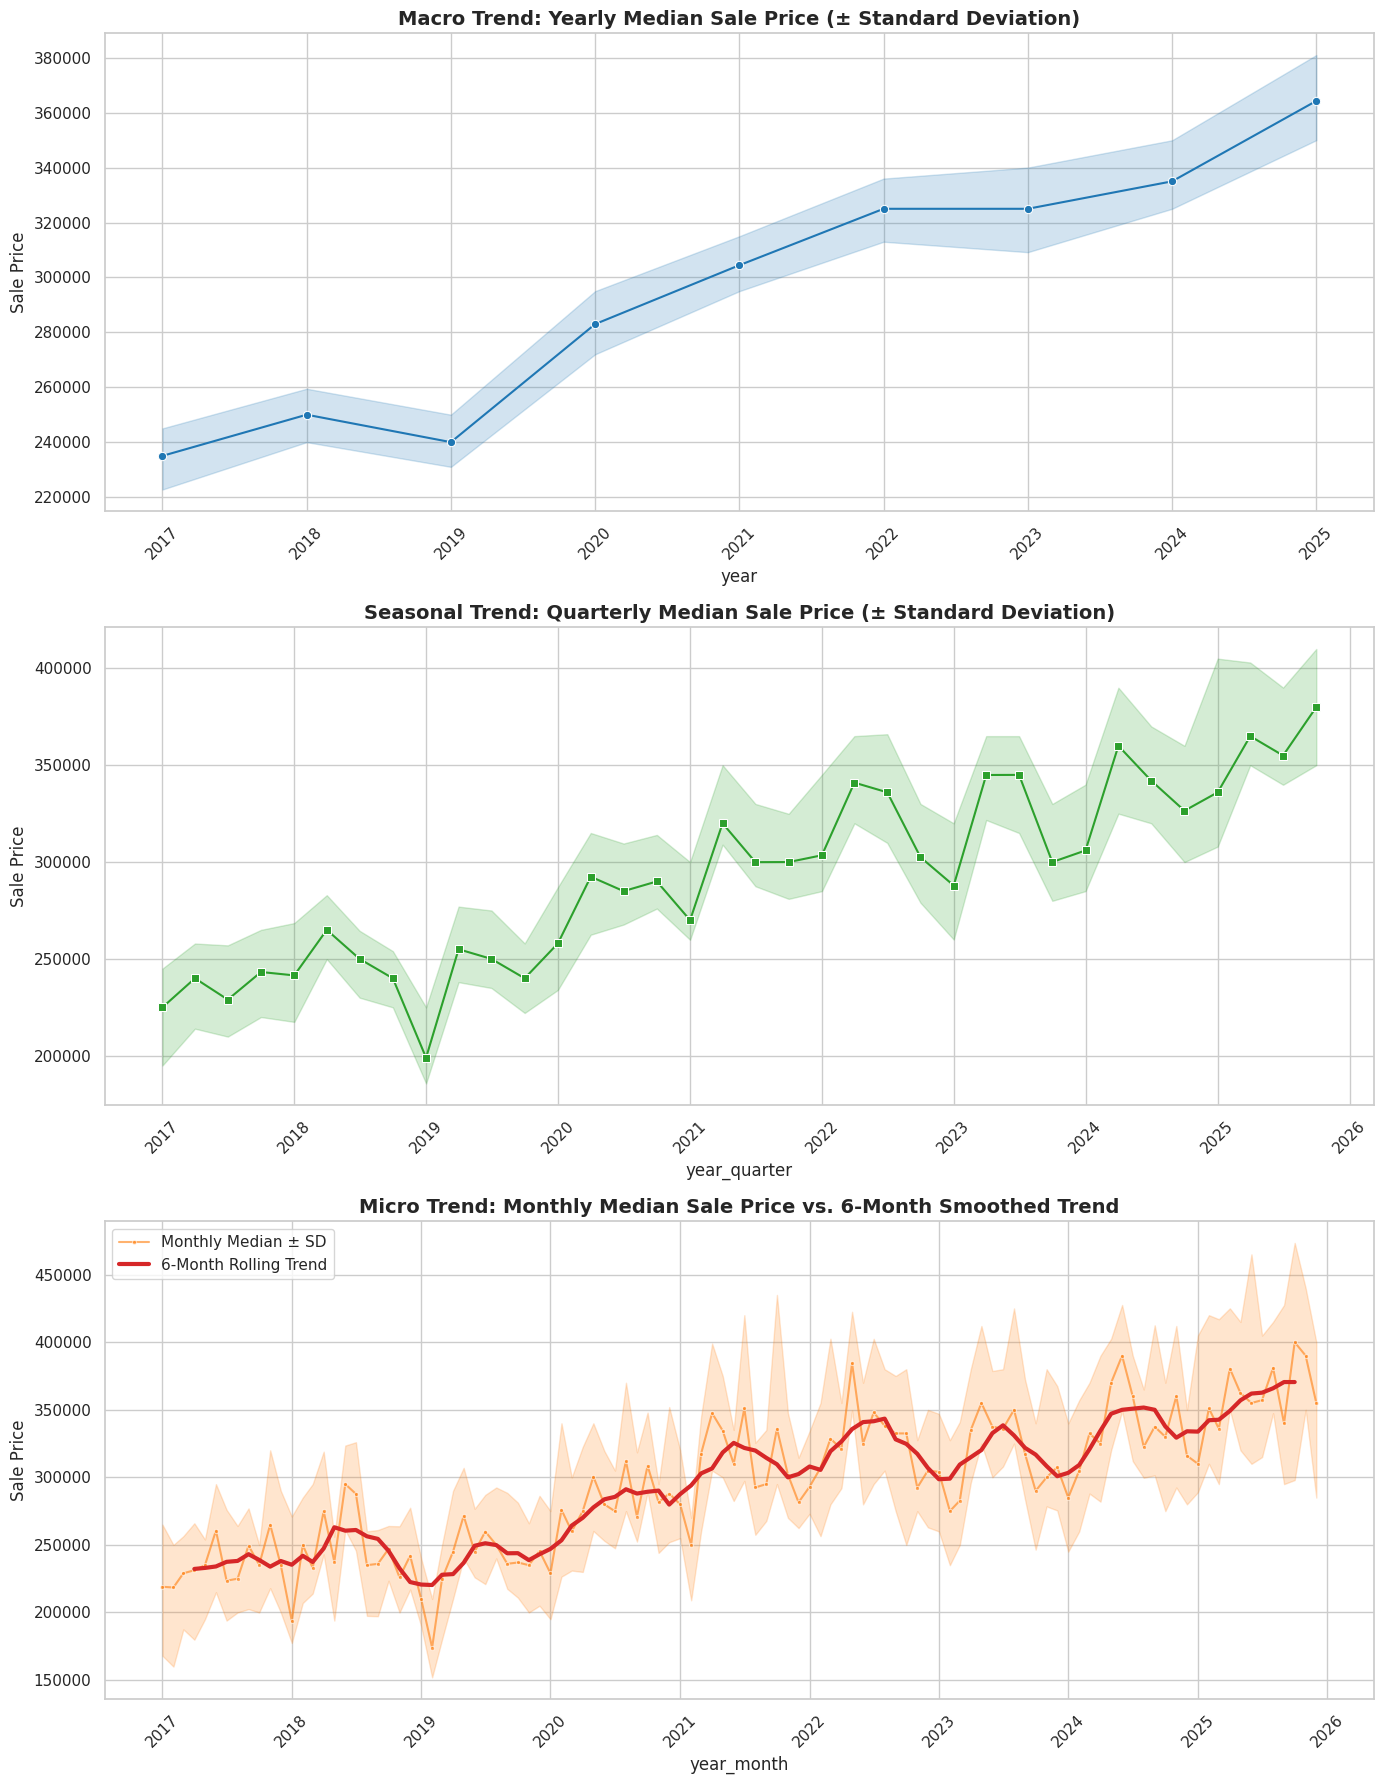

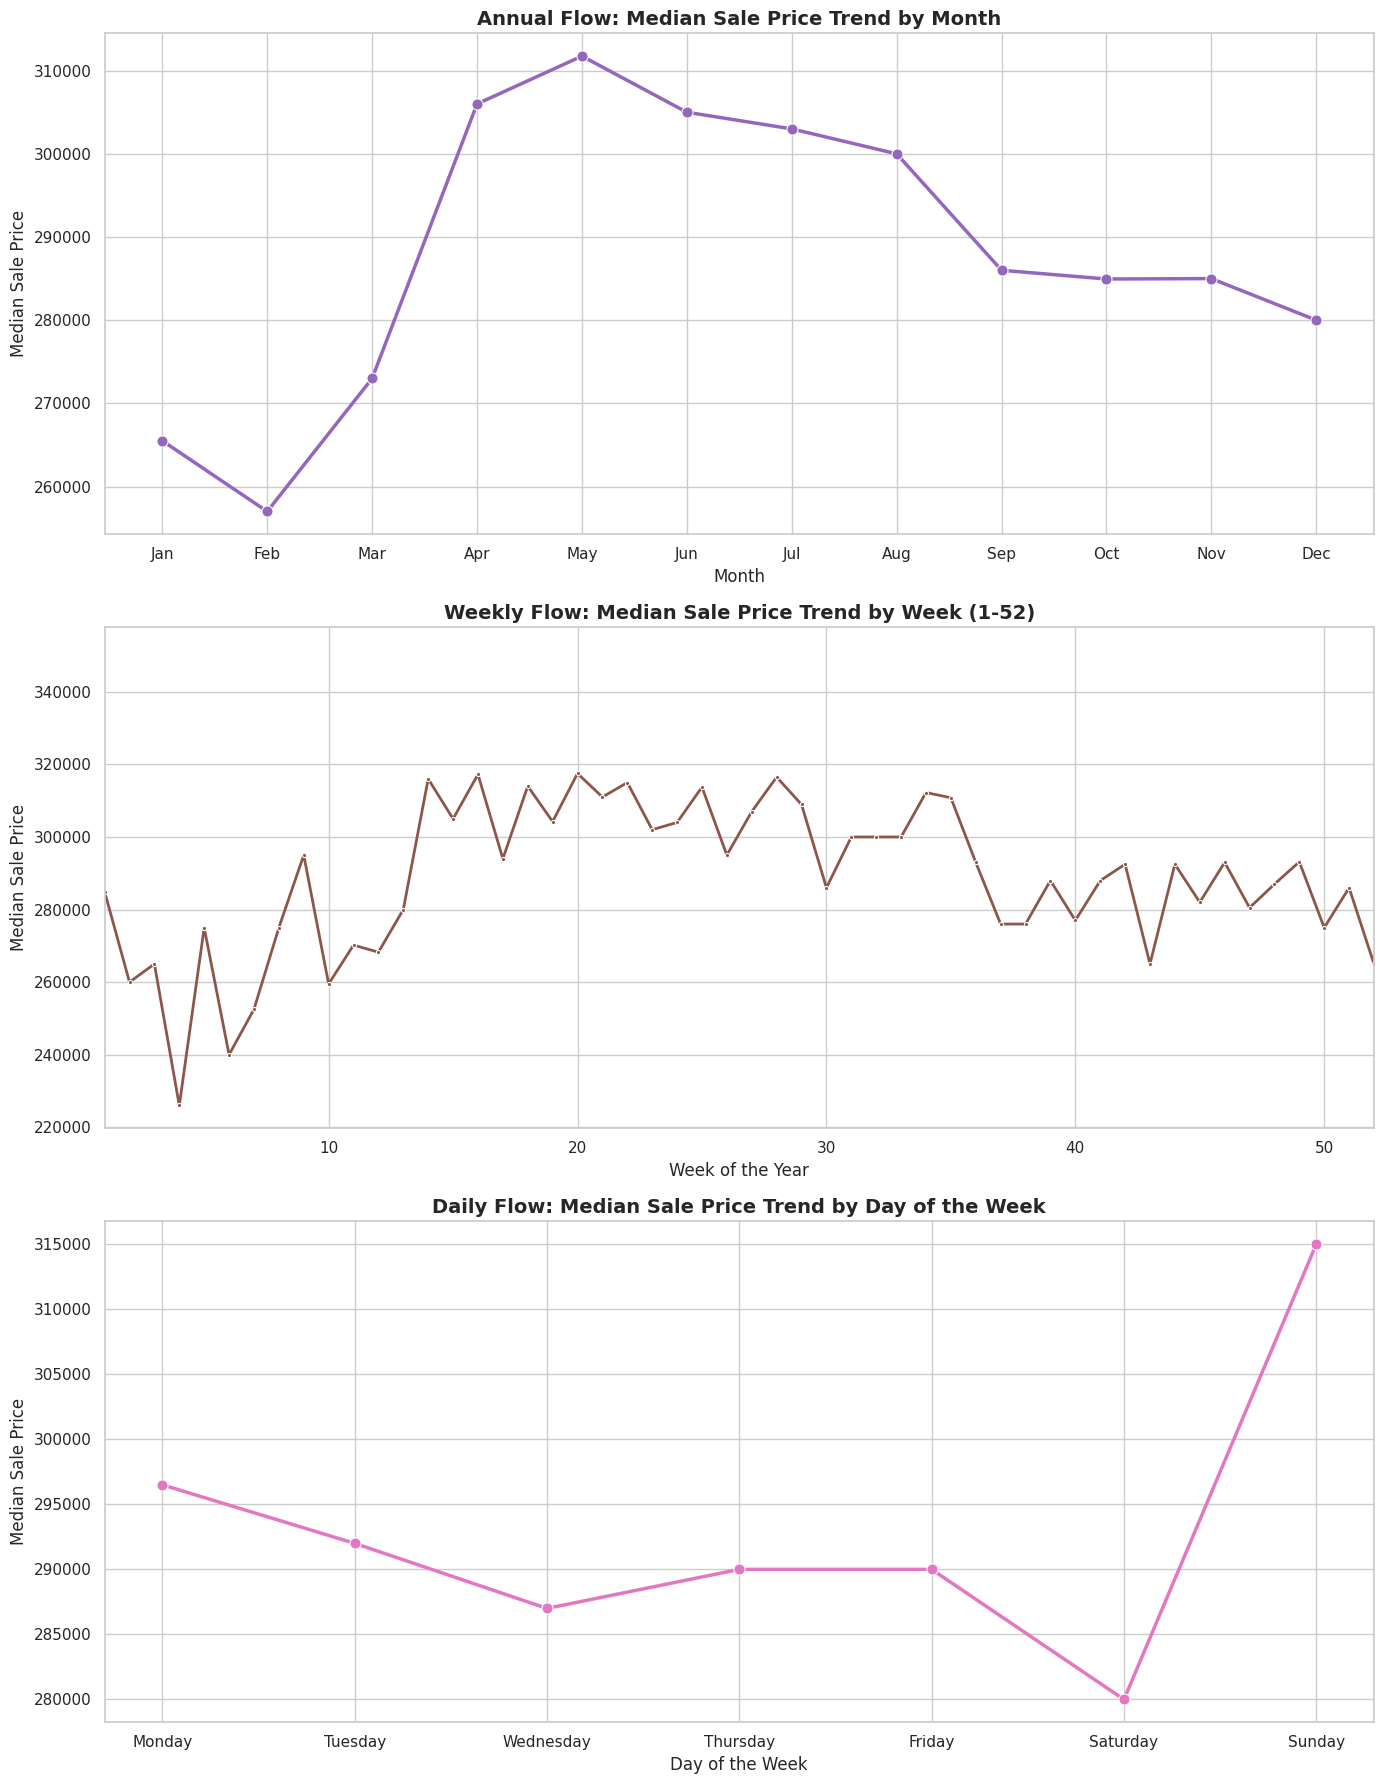

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import calendar

# Set the overall visual style for better readability
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# 1. Data Preparation (Trend & Seasonality)
# ---------------------------------------------------------
# Ensure the date column is datetime
df['meta_sale_date'] = pd.to_datetime(df['meta_sale_date'])

# --- Trend Columns ---
df['year'] = df['meta_sale_date'].dt.year
df['year_quarter'] = df['meta_sale_date'].dt.to_period('Q').dt.to_timestamp()
df['year_month'] = df['meta_sale_date'].dt.to_period('M').dt.to_timestamp()

# Calculate a 6-month rolling average for the monthly data to smooth out noise
monthly_medians = df.groupby('year_month')['meta_sale_price'].median().reset_index()
monthly_medians['rolling_trend'] = monthly_medians['meta_sale_price'].rolling(window=6, center=True).mean()

# --- Seasonality Columns (Strictly Ordered for Line Plots) ---
df['month_of_year'] = df['meta_sale_date'].dt.month
df['week_of_year'] = df['meta_sale_date'].dt.isocalendar().week

# Create an ordered categorical column for Months (Jan -> Dec)
months_order = [calendar.month_abbr[i] for i in range(1, 13)]
df['month_name'] = pd.Categorical(
    df['month_of_year'].apply(lambda x: calendar.month_abbr[x] if pd.notnull(x) else x),
    categories=months_order, 
    ordered=True
)

# Create an ordered categorical column for Days (Mon -> Sun)
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['day_of_week'] = pd.Categorical(
    df['meta_sale_date'].dt.day_name(),
    categories=days_order,
    ordered=True
)

# ---------------------------------------------------------
# 2. FIGURE 1: Trend Dashboard (Over Time)
# ---------------------------------------------------------
fig1, axes1 = plt.subplots(3, 1, figsize=(14, 18), sharex=False)

# Plot A: Yearly
sns.lineplot(ax=axes1[0], data=df, x='year', y='meta_sale_price', estimator=np.median, marker='o', color='#1f77b4')
axes1[0].set_title('Macro Trend: Yearly Median Sale Price (± Standard Deviation)', fontsize=14, fontweight='bold')

# Plot B: Quarterly
sns.lineplot(ax=axes1[1], data=df, x='year_quarter', y='meta_sale_price', estimator=np.median, marker='s', color='#2ca02c')
axes1[1].set_title('Seasonal Trend: Quarterly Median Sale Price (± Standard Deviation)', fontsize=14, fontweight='bold')

# Plot C: Monthly + Rolling
sns.lineplot(ax=axes1[2], data=df, x='year_month', y='meta_sale_price', estimator=np.median, marker='.', color='#ff7f0e', alpha=0.6, label='Monthly Median ± SD')
sns.lineplot(ax=axes1[2], data=monthly_medians, x='year_month', y='rolling_trend', color='#d62728', linewidth=3, label='6-Month Rolling Trend')
axes1[2].set_title('Micro Trend: Monthly Median Sale Price vs. 6-Month Smoothed Trend', fontsize=14, fontweight='bold')

for ax in axes1:
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylabel('Sale Price')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. FIGURE 2: Seasonality Dashboard (Cyclical Patterns)
# ---------------------------------------------------------
fig2, axes2 = plt.subplots(3, 1, figsize=(14, 18), sharex=False)

# --- Plot A: Month of the Year Seasonality (Line Plot) ---
sns.lineplot(
    ax=axes2[0], data=df, 
    x='month_name', y='meta_sale_price', 
    estimator=np.median, errorbar=None, 
    marker='o', markersize=8, color='#9467bd', linewidth=2.5
)
axes2[0].set_title('Annual Flow: Median Sale Price Trend by Month', fontsize=14, fontweight='bold')
axes2[0].set_xlabel('Month')
axes2[0].set_ylabel('Median Sale Price')

# --- Plot B: Week of the Year Seasonality (Line Plot) ---
sns.lineplot(
    ax=axes2[1], data=df, 
    x='week_of_year', y='meta_sale_price', 
    estimator=np.median, errorbar=None, 
    marker='.', color='#8c564b', linewidth=2
)
axes2[1].set_title('Weekly Flow: Median Sale Price Trend by Week (1-52)', fontsize=14, fontweight='bold')
axes2[1].set_xlabel('Week of the Year')
axes2[1].set_ylabel('Median Sale Price')
axes2[1].set_xlim(1, 52)

# --- Plot C: Day of the Week Seasonality (Line Plot) ---
sns.lineplot(
    ax=axes2[2], data=df, 
    x='day_of_week', y='meta_sale_price', 
    estimator=np.median, errorbar=None, 
    marker='o', markersize=8, color='#e377c2', linewidth=2.5
)
axes2[2].set_title('Daily Flow: Median Sale Price Trend by Day of the Week', fontsize=14, fontweight='bold')
axes2[2].set_xlabel('Day of the Week')
axes2[2].set_ylabel('Median Sale Price')

plt.tight_layout()
plt.show()

In [ ]:
# for col in df.columns:
#     if "triad" in col:
#         print(col)
#         print(df[col].unique()[:2])

# # df.meta_triad_code.unique()

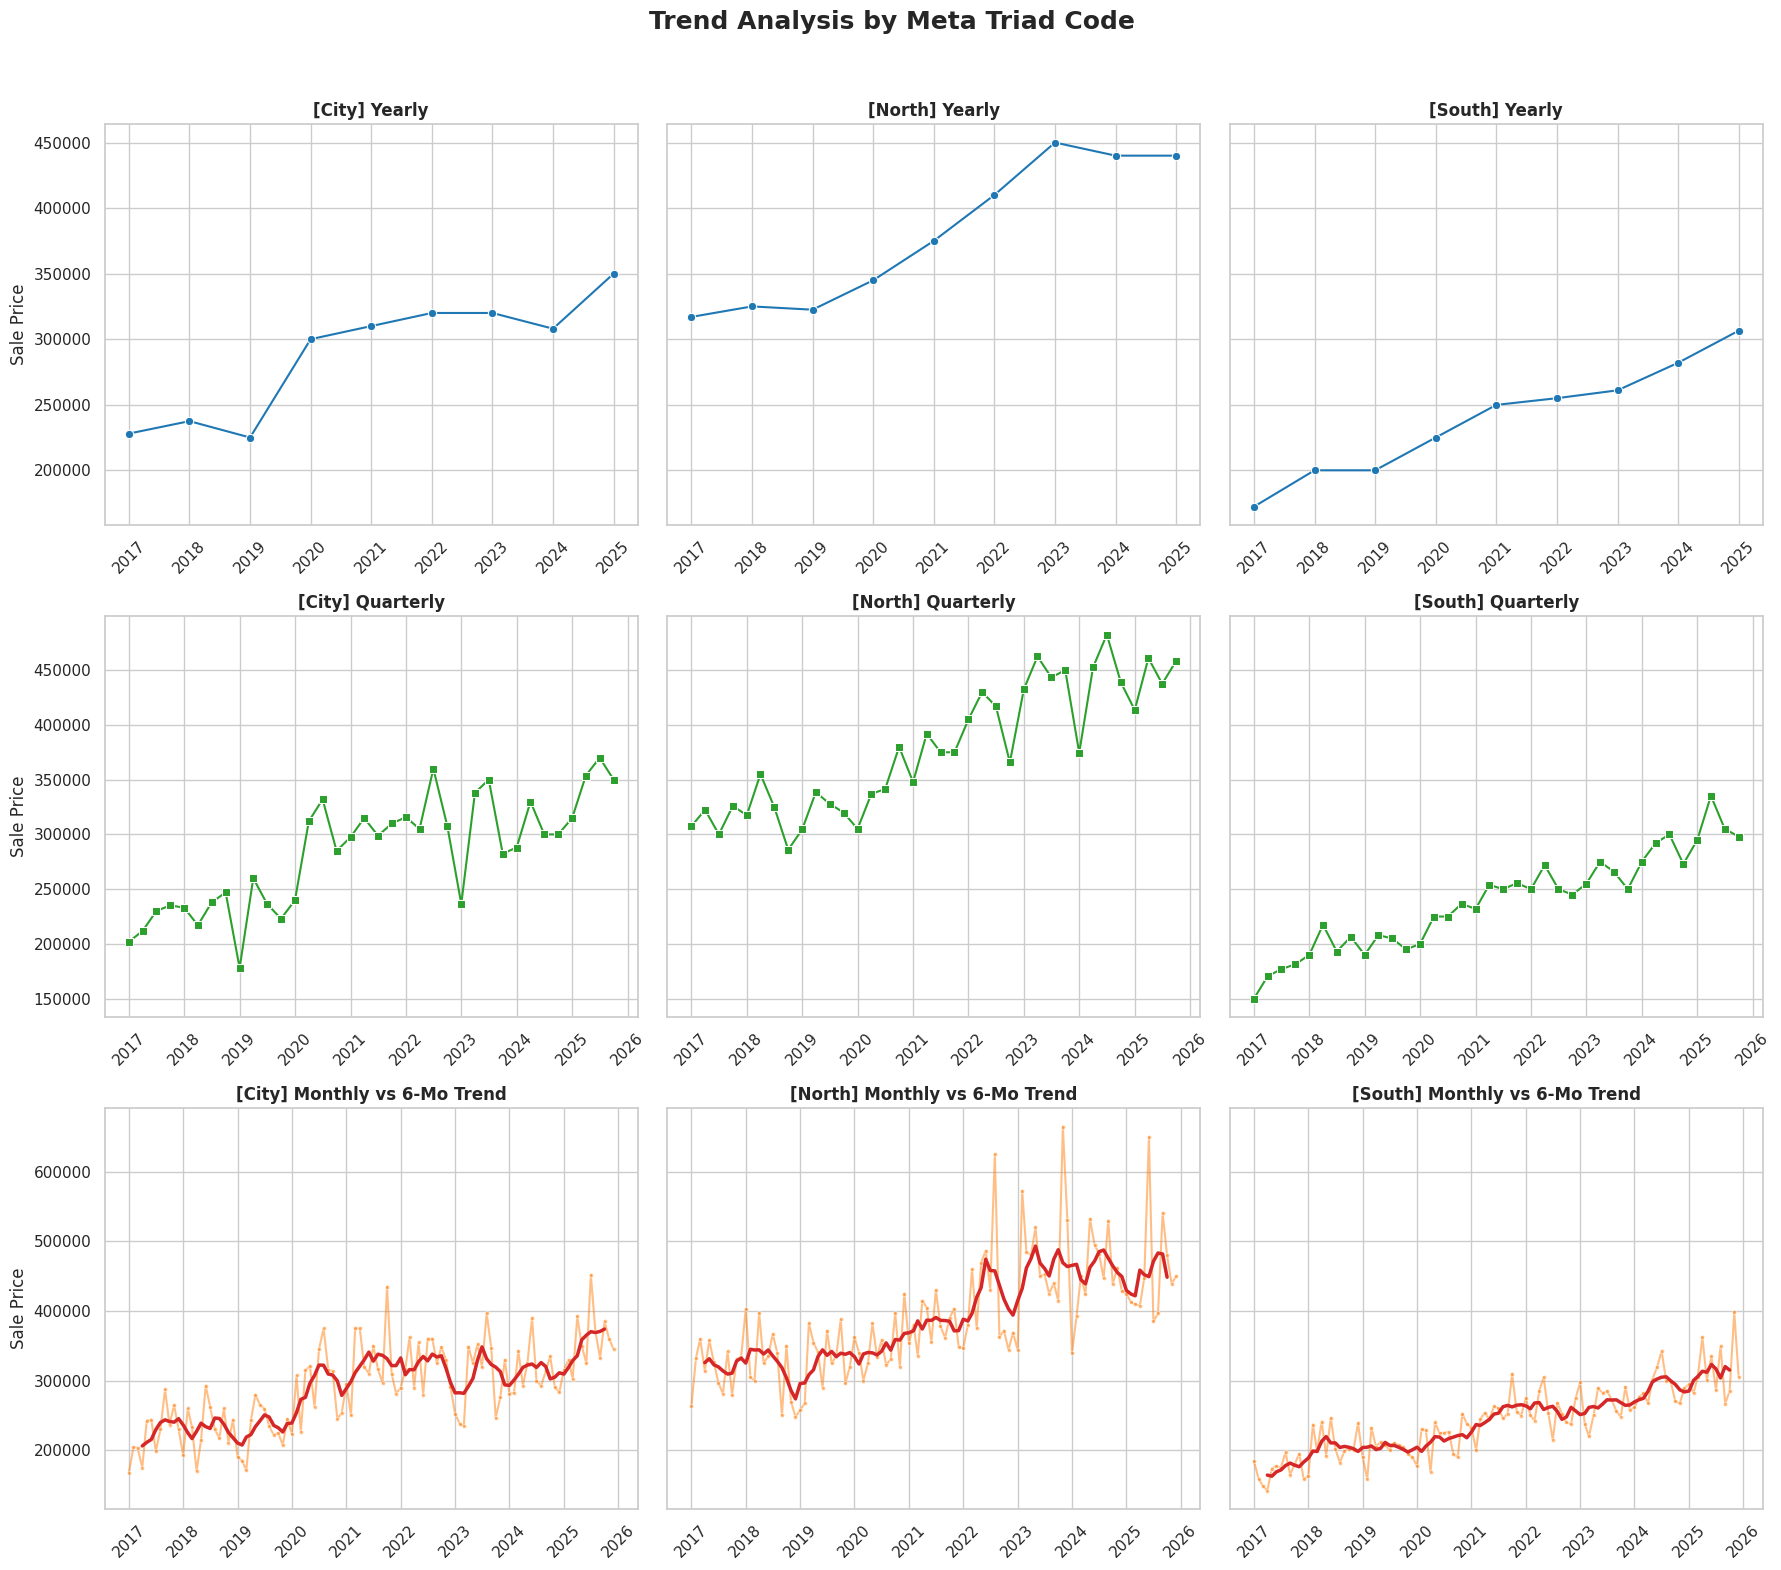

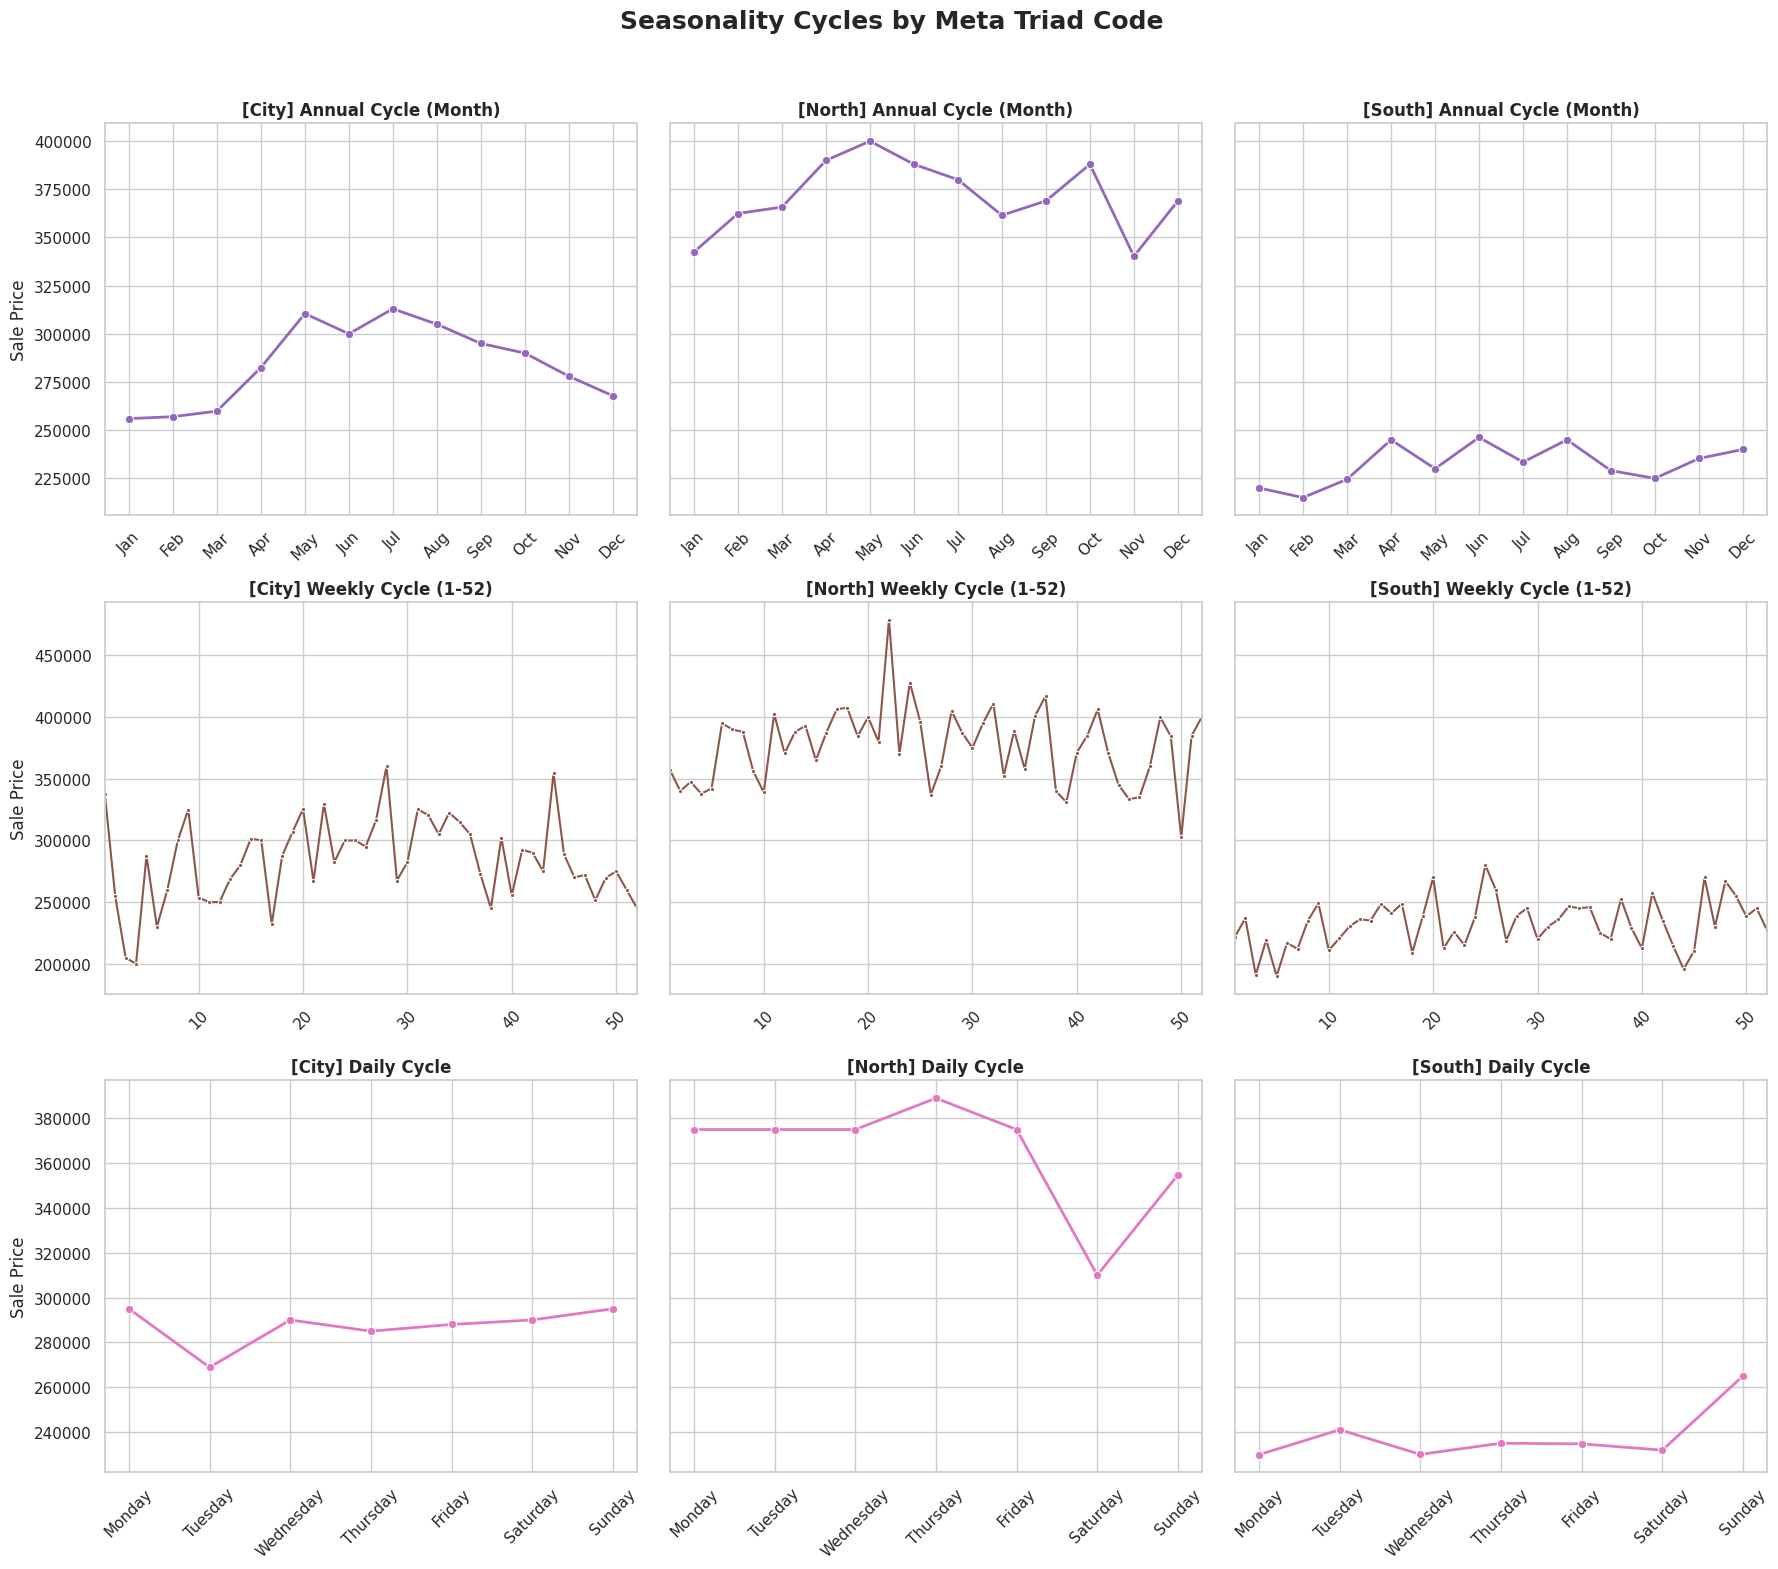

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import calendar

# Set the overall visual style
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# 1. Data Preparation (Trend & Seasonality)
# ---------------------------------------------------------
df['meta_sale_date'] = pd.to_datetime(df['meta_sale_date'])

# --- Trend Columns ---
df['year'] = df['meta_sale_date'].dt.year
df['year_quarter'] = df['meta_sale_date'].dt.to_period('Q').dt.to_timestamp()
df['year_month'] = df['meta_sale_date'].dt.to_period('M').dt.to_timestamp()

# --- NEW: Grouped Rolling Average ---
# We must group by the triad code FIRST, so the rolling average doesn't mix categories
monthly_medians = df.groupby(['meta_triad_name', 'year_month'])['meta_sale_price'].median().reset_index()
monthly_medians = monthly_medians.sort_values(by=['meta_triad_name', 'year_month'])
# Calculate rolling mean within each triad group
monthly_medians['rolling_trend'] = monthly_medians.groupby('meta_triad_name')['meta_sale_price'].transform(lambda x: x.rolling(window=6, center=True).mean())

# --- Seasonality Columns ---
df['month_of_year'] = df['meta_sale_date'].dt.month
df['week_of_year'] = df['meta_sale_date'].dt.isocalendar().week

months_order = [calendar.month_abbr[i] for i in range(1, 13)]
df['month_name'] = pd.Categorical(
    df['month_of_year'].apply(lambda x: calendar.month_abbr[x] if pd.notnull(x) else x),
    categories=months_order, ordered=True
)

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['day_of_week'] = pd.Categorical(
    df['meta_sale_date'].dt.day_name(),
    categories=days_order, ordered=True
)

# Extract unique triad codes (assuming 3 categories)
triad_codes = sorted(df['meta_triad_name'].dropna().unique())
n_cols = len(triad_codes)

# ---------------------------------------------------------
# 2. FIGURE 1: Trend Dashboard (3x3 Grid)
# ---------------------------------------------------------
# sharey='row' ensures the price scale is identical across categories for fair comparison
fig1, axes1 = plt.subplots(3, n_cols, figsize=(18, 16), sharey='row', sharex='row')
fig1.suptitle('Trend Analysis by Meta Triad Code', fontsize=18, fontweight='bold', y=0.98)

for col_idx, triad in enumerate(triad_codes):
    subset = df[df['meta_triad_name'] == triad]
    subset_monthly = monthly_medians[monthly_medians['meta_triad_name'] == triad]
    
    # Row 0: Yearly
    sns.lineplot(ax=axes1[0, col_idx], data=subset, x='year', y='meta_sale_price', estimator=np.median, errorbar=None, marker='o', color='#1f77b4')
    axes1[0, col_idx].set_title(f'[{triad}] Yearly', fontsize=12, fontweight='bold')
    
    # Row 1: Quarterly
    sns.lineplot(ax=axes1[1, col_idx], data=subset, x='year_quarter', y='meta_sale_price', estimator=np.median, errorbar=None, marker='s', color='#2ca02c')
    axes1[1, col_idx].set_title(f'[{triad}] Quarterly', fontsize=12, fontweight='bold')
    
    # Row 2: Monthly + Rolling
    sns.lineplot(ax=axes1[2, col_idx], data=subset, x='year_month', y='meta_sale_price', estimator=np.median, errorbar=None, marker='.', color='#ff7f0e', alpha=0.5)
    sns.lineplot(ax=axes1[2, col_idx], data=subset_monthly, x='year_month', y='rolling_trend', color='#d62728', linewidth=2.5)
    axes1[2, col_idx].set_title(f'[{triad}] Monthly vs 6-Mo Trend', fontsize=12, fontweight='bold')

# Formatting for Fig 1
for ax in axes1.flat:
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylabel('Sale Price')
    ax.set_xlabel('') # Clear x-labels to avoid clutter, the ticks speak for themselves

plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust to fit main title
plt.show()

# ---------------------------------------------------------
# 3. FIGURE 2: Seasonality Dashboard (3x3 Grid)
# ---------------------------------------------------------
fig2, axes2 = plt.subplots(3, n_cols, figsize=(18, 16), sharey='row')
fig2.suptitle('Seasonality Cycles by Meta Triad Code', fontsize=18, fontweight='bold', y=0.98)

for col_idx, triad in enumerate(triad_codes):
    subset = df[df['meta_triad_name'] == triad]
    
    # Row 0: Annual Seasonality (By Month)
    sns.lineplot(ax=axes2[0, col_idx], data=subset, x='month_name', y='meta_sale_price', estimator=np.median, errorbar=None, marker='o', color='#9467bd', linewidth=2)
    axes2[0, col_idx].set_title(f'[{triad}] Annual Cycle (Month)', fontsize=12, fontweight='bold')
    
    # Row 1: Weekly Seasonality (1-52)
    sns.lineplot(ax=axes2[1, col_idx], data=subset, x='week_of_year', y='meta_sale_price', estimator=np.median, errorbar=None, marker='.', color='#8c564b', linewidth=1.5)
    axes2[1, col_idx].set_title(f'[{triad}] Weekly Cycle (1-52)', fontsize=12, fontweight='bold')
    axes2[1, col_idx].set_xlim(1, 52)
    
    # Row 2: Daily Seasonality
    sns.lineplot(ax=axes2[2, col_idx], data=subset, x='day_of_week', y='meta_sale_price', estimator=np.median, errorbar=None, marker='o', color='#e377c2', linewidth=2)
    axes2[2, col_idx].set_title(f'[{triad}] Daily Cycle', fontsize=12, fontweight='bold')

# Formatting for Fig 2
for ax in axes2.flat:
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylabel('Sale Price')
    ax.set_xlabel('')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

<Axes: >

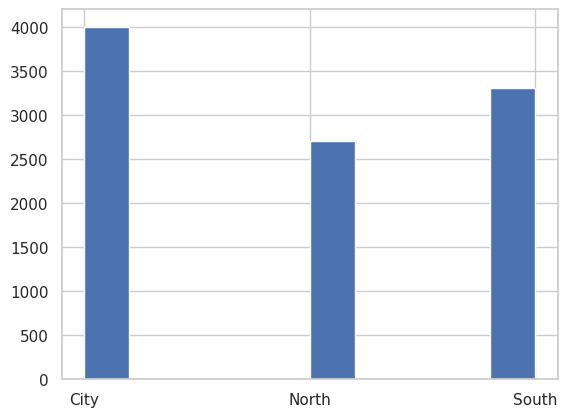

In [ ]:
df['meta_triad_name'].hist()#.dropna().unique()

df

In [ ]:
# feature_x = "meta_sale_deed_type"
# feature_x = "meta_modeling_group"
# feature_x = "meta_township_name"
# feature_x = "meta_tieback_key_pin" # This one does not have variance in general (1 sample)
# feature_x = "meta_class"
feature_x = "is_arms_length"

# df[[feature_x, "meta_sale_price"]].sample(20)

for deed in df[feature_x].unique():
    print(deed)
    print(df[df[feature_x] == deed].meta_sale_price.describe())
    plt.hist(np.log(df[df[feature_x] == deed].meta_sale_price), bins=100)
    # add statistics to the plot
    plt.text(0.5, 0.5, f"Mean: {np.mean(np.log(df[df[feature_x] == deed].meta_sale_price)):.2f}\nMedian: {np.median(np.log(df[df[feature_x] == deed].meta_sale_price)):.2f}\nStd: {np.std(np.log(df[df[feature_x] == deed].meta_sale_price)):.2f}",
             ha='right', va='top', transform=plt.gca().transAxes)
    plt.show()
    print("\n")




NameError: name 'df' is not defined

In [ ]:
# %pip install pyarrow
import pyarrow.dataset as ds

data_path_assess = "./data/CCAO/2025/assessment_data.parquet"

import pyarrow.parquet as pq
from itertools import islice

pf = pq.ParquetFile(data_path_assess)

chunk_i = 10
batch_size = 1_000

batch = next(islice(
    pf.iter_batches(batch_size=batch_size),
    chunk_i,
    chunk_i + 1
))

df_assess = batch.to_pandas()
df_assess.head()

,meta_pin,meta_pin10,meta_year,meta_class,meta_modeling_group,meta_triad_name,meta_triad_code,meta_township_name,meta_township_code,meta_nbhd_code,...,ccao_is_corner_lot,time_sale_year,time_sale_day,time_sale_quarter_of_year,time_sale_month_of_year,time_sale_day_of_year,time_sale_day_of_month,time_sale_day_of_week,time_sale_post_covid,year
0,13133020210000,1313302021,2024,211,MF,City,1,Jefferson,71,71082,...,False,2025.0,3289.0,Q1,1,1,1,4,True,2024
1,13084140400000,1308414040,2024,211,MF,City,1,Jefferson,71,71402,...,False,2025.0,3289.0,Q1,1,1,1,4,True,2024
2,13084170470000,1308417047,2024,211,MF,City,1,Jefferson,71,71402,...,False,2025.0,3289.0,Q1,1,1,1,4,True,2024
3,13084170560000,1308417056,2024,211,MF,City,1,Jefferson,71,71402,...,False,2025.0,3289.0,Q1,1,1,1,4,True,2024
4,13084190500000,1308419050,2024,211,MF,City,1,Jefferson,71,71402,...,False,2025.0,3289.0,Q1,1,1,1,4,True,2024


In [ ]:
# for col in df_assess.columns:
#     print(col)
#     print(df_assess[col].unique()[:2])

df_assess.meta_modeling_group.unique()
df_assess.meta_class.unique()
print(df_assess.shape)
df_assess.char_bldg_sf_95_percentile.unique()

# Filter with respect to char_bldg_sf_95_percentile
# df[df.char_bldg_sf_95_percentile.unique()#.describe()
df_assess[df_assess.char_bldg_sf >= df_assess.char_bldg_sf_95_percentile].char_bldg_sf
# print(df_assess.shape)
# It has: meta_year, meta_class, meta_modeling_group, meta_triad_name, meta_cdu

(1000, 191)


21     5486.0
67     6985.0
73     4461.0
74     4536.0
98     4508.0
104    8269.0
116    4572.0
132    8560.0
135    4452.0
155    5034.0
164    4150.0
176    6031.0
261    5397.0
266    5436.0
282    4695.0
300    3920.0
340    4788.0
343    5265.0
361    6177.0
366    3910.0
402    4058.0
443    3890.0
488    3724.0
519    4203.0
619    6170.0
627    6153.0
628    4274.0
648    4852.0
679    6377.0
691    4532.0
692    4368.0
765    5387.0
783    4356.0
809    4220.0
827    4452.0
846    4810.0
869    8751.0
875    7056.0
883    6852.0
885    4820.0
887    4589.0
937    4644.0
949    7106.0
990    4500.0
995    3733.0
Name: char_bldg_sf, dtype: float64

In [ ]:
df_assess[df_assess.meta_1yr_pri_board_tot != df_assess.meta_2yr_pri_board_tot]


,meta_pin,meta_pin10,meta_year,meta_class,meta_modeling_group,meta_triad_name,meta_triad_code,meta_township_name,meta_township_code,meta_nbhd_code,...,ccao_is_corner_lot,time_sale_year,time_sale_day,time_sale_quarter_of_year,time_sale_month_of_year,time_sale_day_of_year,time_sale_day_of_month,time_sale_day_of_week,time_sale_post_covid,year
6,13084250920000,1308425092,2024,203,SF,City,1,Jefferson,71,71402,...,False,2025.0,3289.0,Q1,1,1,1,4,True,2024
8,13084280320000,1308428032,2024,202,SF,City,1,Jefferson,71,71402,...,False,2025.0,3289.0,Q1,1,1,1,4,True,2024
15,13091280100000,1309128010,2024,205,SF,City,1,Jefferson,71,71010,...,False,2025.0,3289.0,Q1,1,1,1,4,True,2024
34,13094080360000,1309408036,2024,202,SF,City,1,Jefferson,71,71060,...,False,2025.0,3289.0,Q1,1,1,1,4,True,2024
39,13094270250000,1309427025,2024,211,MF,City,1,Jefferson,71,71060,...,False,2025.0,3289.0,Q1,1,1,1,4,True,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
919,13281270030000,1328127003,2024,203,SF,City,1,Jefferson,71,71260,...,False,2025.0,3289.0,Q1,1,1,1,4,True,2024
929,13282220230000,1328222023,2024,203,SF,City,1,Jefferson,71,71260,...,False,2025.0,3289.0,Q1,1,1,1,4,True,2024
977,13294190100000,1329419010,2024,205,SF,City,1,Jefferson,71,71250,...,False,2025.0,3289.0,Q1,1,1,1,4,True,2024
987,13301130040000,1330113004,2024,205,SF,City,1,Jefferson,71,71200,...,False,2025.0,3289.0,Q1,1,1,1,4,True,2024


In [ ]:
# import numpy as np
from sklearn.neighbors import BallTree

# 1. Convert lat/long to radians for the Haversine metric
# Note: Haversine expects (latitude, longitude) order
coords_rad = np.radians(df[['loc_latitude', 'loc_longitude']].values)

# 2. Build the Tree
tree = BallTree(coords_rad, metric='haversine')

# 3. Query the tree for the K-nearest neighbors (e.g., k=5)
# This returns the distances and the dataframe indices of the neighbors
distances, indices = tree.query(coords_rad, k=10)

# 4. Convert the output distances to kilometers (Earth's radius ~ 6371 km)
distances_km = distances * 6371.0088

In [ ]:
distances_km[:10, :10]

array([[0.        , 0.15512083, 0.28877423, 0.3163432 , 0.32135007,
        0.32535784, 0.38653577, 0.41290074, 0.44118021, 0.45429883],
       [0.        , 0.51910072, 0.576226  , 0.60964567, 0.67869012,
        0.69933321, 0.74134459, 0.75827326, 0.77186448, 0.79997682],
       [0.        , 0.11254078, 0.11531672, 0.20644595, 0.34854573,
        0.64190325, 0.6430692 , 0.7019929 , 0.70200512, 0.70941978],
       [0.        , 0.091716  , 0.26540094, 0.30888774, 0.3129794 ,
        0.46141809, 0.50551858, 0.51954684, 0.59363601, 0.66120811],
       [0.        , 0.16733184, 0.20422411, 0.29125716, 0.40376622,
        0.42677676, 0.46612996, 0.51760759, 0.53016086, 0.56105102],
       [0.        , 0.02363924, 0.39552215, 0.49171569, 0.63778024,
        0.64620027, 0.65410559, 0.80711128, 0.81480249, 0.89911663],
       [0.        , 0.13820678, 0.19498968, 0.24797989, 0.50172786,
        0.57704649, 0.62593311, 0.64031268, 0.67098143, 0.73184411],
       [0.        , 0.46892037, 0.6371407

In [ ]:
for j in range(distances_km.shape[1]):
    if j > 0:
        # print(distances_km[0, j])
        print("Correlation:", np.corrcoef(distances_km[:, j], y)[0, 1])
    # np.corrcoef(distances_km, y)

Correlation: 0.05703189325564614
Correlation: 0.06423110501063058
Correlation: 0.061256367165540525
Correlation: 0.050895965697263304


In [ ]:
import numpy as np
import pandas as pd
from sklearn.neighbors import BallTree

# Assuming your dataframe is 'df' and target column is 'target_y'
# Extract underlying NumPy arrays for maximum speed
y = df['meta_sale_price'].values
coords_rad = np.radians(df[['loc_latitude', 'loc_longitude']].values)


for K in range(1, 11):
    # 1. Build the BallTree
    tree = BallTree(coords_rad, metric='haversine')

    # Define how many neighbors you want to average
    # K = 10

    # 2. Query for K + 1 neighbors
    # The closest point (index 0) is always the point itself, so we need K+1 to get K actual neighbors
    distances, indices = tree.query(coords_rad, k=K + 1)

    # 3. Drop the first column (exclude the point itself)
    # neighbor_indices shape becomes (N, K)
    neighbor_indices = indices[:, 1:] 

    # 4. Extract the 'y' values for all neighbors simultaneously
    # This is NumPy advanced indexing. It takes the N x K matrix of indices 
    # and instantly maps them to their actual 'y' values, creating an N x K matrix of target variables.
    neighbor_y_values = y[neighbor_indices]

    # 5. Compute the average (or sum) of the neighbors' y values for each row
    # axis=1 means we compute the mean across the K columns for each row
    neighbor_y_avg = np.mean(neighbor_y_values, axis=1)
    # NOTE: If you want the sum instead, use: np.sum(neighbor_y_values, axis=1)

    # 6. Compute the Pearson correlation coefficient
    # np.corrcoef returns a 2x2 matrix; we just need the off-diagonal value [0, 1]
    correlation = np.corrcoef(y, neighbor_y_avg)[0, 1]

    print(f"Correlation between target 'y' and the {K}-nearest geographical neighbors' average: {correlation:.4f}")

    # Optional: If you want to add this new engineered feature back to your dataframe
    df[f'spatial_lag_{K}_avg'] = neighbor_y_avg

Correlation between target 'y' and the 1-nearest geographical neighbors' average: 0.6881
Correlation between target 'y' and the 2-nearest geographical neighbors' average: 0.7145
Correlation between target 'y' and the 3-nearest geographical neighbors' average: 0.7346
Correlation between target 'y' and the 4-nearest geographical neighbors' average: 0.7493
Correlation between target 'y' and the 5-nearest geographical neighbors' average: 0.7528
Correlation between target 'y' and the 6-nearest geographical neighbors' average: 0.7528
Correlation between target 'y' and the 7-nearest geographical neighbors' average: 0.7561
Correlation between target 'y' and the 8-nearest geographical neighbors' average: 0.7577
Correlation between target 'y' and the 9-nearest geographical neighbors' average: 0.7581
Correlation between target 'y' and the 10-nearest geographical neighbors' average: 0.7642


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import haversine_distances

# 1. Prepare and Sort the Data
df['meta_sale_date'] = pd.to_datetime(df['meta_sale_date'])
df = df.sort_values('meta_sale_date').reset_index(drop=True)

df['year'] = df['meta_sale_date'].dt.year

# Convert time to a continuous numeric value (Days makes it easy to interpret)
# time_days = (df['meta_sale_date'].view('int64') // 10**9) / 86400 
# New (Added .values)
time_days = (df['meta_sale_date'].view('int64') // 10**9).values / 86400

y = df['meta_sale_price'].values
coords_rad = np.radians(df[['loc_latitude', 'loc_longitude']].values)

# Define the weights for the Temporal factor (alpha)
# 0.0 = 100% Space, 1.0 = 100% Time
weights = [0.0, 1e-4, 1e-3, 1e-2, 1e-1, 1.0]

for K in range(1, 11):
# K = 5

    # Dictionary to hold the predicted average for each weight
    predictions = {w: np.full(len(df), np.nan) for w in weights}

    # 2. Efficient Batch Processing by Year
    years = sorted(df['year'].unique())

    for target_year in years[1:]: # Skip the first year (no history)
        
        # Indices for the historical pool and the current batch
        past_idx = np.where(df['year'] < target_year)[0]
        curr_idx = np.where(df['year'] == target_year)[0]
        
        if len(past_idx) < K:
            continue
            
        # --- Step A: Compute the Raw Distance Matrices ---
        # Shape of these matrices will be (N_current, N_past)
        
        # Spatial Distance (Haversine in radians is fine since we will normalize anyway)
        D_space = haversine_distances(coords_rad[curr_idx], coords_rad[past_idx])
        
        # Temporal Distance (Absolute difference in days)
        # Using numpy broadcasting to efficiently compute pairwise differences
        D_time = np.abs(time_days[curr_idx, np.newaxis] - time_days[past_idx])
        
        # --- Step B: Normalize the Matrices to [0, 1] ---
        # This ensures a 0.5 weight treats maximum spatial distance equally to maximum time distance
        max_space = np.max(D_space)
        max_time = np.max(D_time)
        
        D_space_norm = D_space / max_space if max_space > 0 else D_space
        D_time_norm = D_time / max_time if max_time > 0 else D_time
        
        # --- Step C: Compute Weighted Distances and Find Neighbors ---
        for w in weights:
            # Calculate the combined distance matrix
            D_combined = (1 - w) * D_space_norm + w * D_time_norm
            
            # np.argpartition is a highly optimized way to find the top K smallest values 
            # without sorting the entire matrix. It's much faster than np.argsort.
            # This returns the relative indices along the columns (axis=1)
            top_k_relative_idx = np.argpartition(D_combined, K, axis=1)[:, :K]
            
            # Map back to the absolute dataframe indices
            real_past_idx = past_idx[top_k_relative_idx]
            
            # Extract the historical 'y' values and calculate the mean for each row
            predictions[w][curr_idx] = np.mean(y[real_past_idx], axis=1)

    # 3. Compute Final Correlations for all Weights
    print(f"Correlations between Target Y and K-Nearest (K={K}) Past Averages:")
    print("-" * 55)

    # Drop rows with NaN (the first year of data)
    valid_mask = ~np.isnan(predictions[0.0])

    for w in weights:
        pred_y = predictions[w][valid_mask]
        actual_y = y[valid_mask]
        
        corr = np.corrcoef(actual_y, pred_y)[0, 1]
        
        if w == 0.0:
            label = "Distance-Only (w=0.00)"
        elif w == 1.0:
            label = "Time-Only     (w=1.00)"
        else:
            label = f"Mixed         (w={w:.6f})"
            
        print(f"{label}: {corr:.4f}")
        
        # Optional: Save the features back to the dataframe
        df[f'st_knn_avg_w{w}'] = predictions[w]

/tmp/ipykernel_494211/727392904.py:14: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  time_days = (df['meta_sale_date'].view('int64') // 10**9).values / 86400


Correlations between Target Y and K-Nearest (K=1) Past Averages:
-------------------------------------------------------
Distance-Only (w=0.00): 0.6386
Mixed         (w=0.000100): 0.6386
Mixed         (w=0.001000): 0.6444
Mixed         (w=0.010000): 0.6517
Mixed         (w=0.100000): 0.6073
Time-Only     (w=1.00): 0.0817
Correlations between Target Y and K-Nearest (K=2) Past Averages:
-------------------------------------------------------
Distance-Only (w=0.00): 0.6928
Mixed         (w=0.000100): 0.6934
Mixed         (w=0.001000): 0.6903
Mixed         (w=0.010000): 0.6966
Mixed         (w=0.100000): 0.6656
Time-Only     (w=1.00): 0.0888
Correlations between Target Y and K-Nearest (K=3) Past Averages:
-------------------------------------------------------
Distance-Only (w=0.00): 0.7245
Mixed         (w=0.000100): 0.7247
Mixed         (w=0.001000): 0.7242
Mixed         (w=0.010000): 0.7125
Mixed         (w=0.100000): 0.7005
Time-Only     (w=1.00): 0.0862
Correlations between Target Y a

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import haversine_distances
from sklearn.metrics import r2_score

# 1. Prepare and Sort the Data
df['meta_sale_date'] = pd.to_datetime(df['meta_sale_date'])
df = df.sort_values('meta_sale_date').reset_index(drop=True)

df['year'] = df['meta_sale_date'].dt.year

# Convert time to a continuous numeric value (Days makes it easy to interpret)
# FIXED: Using astype instead of view to prevent Pandas FutureWarnings
time_days = (df['meta_sale_date'].astype('int64') // 10**9).values / 86400

y = df['meta_sale_price'].values
coords_rad = np.radians(df[['loc_latitude', 'loc_longitude']].values)

# Define the weights for the Temporal factor (alpha)
# 0.0 = 100% Space, 1.0 = 100% Time
weights = [0.0, 1e-4, 1e-3, 1e-2, 1e-1, 1.0]

for K in range(1, 21):
    # Dictionary to hold the predicted average for each weight
    predictions = {w: np.full(len(df), np.nan) for w in weights}

    # 2. Efficient Batch Processing by Year
    years = sorted(df['year'].unique())

    for target_year in years[1:]: # Skip the first year (no history)
        
        # Indices for the historical pool and the current batch
        past_idx = np.where(df['year'] < target_year)[0]
        curr_idx = np.where(df['year'] == target_year)[0]
        
        if len(past_idx) < K:
            continue
            
        # --- Step A: Compute the Raw Distance Matrices ---
        # Shape of these matrices will be (N_current, N_past)
        
        # Spatial Distance (Haversine in radians is fine since we will normalize anyway)
        D_space = haversine_distances(coords_rad[curr_idx], coords_rad[past_idx])
        
        # Temporal Distance (Absolute difference in days)
        # Using numpy broadcasting to efficiently compute pairwise differences
        D_time = np.abs(time_days[curr_idx, np.newaxis] - time_days[past_idx])
        
        # --- Step B: Normalize the Matrices to [0, 1] ---
        # This ensures a 0.5 weight treats maximum spatial distance equally to maximum time distance
        max_space = np.max(D_space)
        max_time = np.max(D_time)
        
        D_space_norm = D_space / max_space if max_space > 0 else D_space
        D_time_norm = D_time / max_time if max_time > 0 else D_time
        
        # --- Step C: Compute Weighted Distances and Find Neighbors ---
        for w in weights:
            # Calculate the combined distance matrix
            D_combined = (1 - w) * D_space_norm + w * D_time_norm
            
            # np.argpartition is a highly optimized way to find the top K smallest values 
            # without sorting the entire matrix. It's much faster than np.argsort.
            # This returns the relative indices along the columns (axis=1)
            top_k_relative_idx = np.argpartition(D_combined, K, axis=1)[:, :K]
            
            # Map back to the absolute dataframe indices
            real_past_idx = past_idx[top_k_relative_idx]
            
            # Extract the historical 'y' values and calculate the mean for each row
            predictions[w][curr_idx] = np.mean(y[real_past_idx], axis=1)

    # 3. Compute Final Correlations & R2 for all Weights
    print(f"Metrics against Target Y using K-Nearest (K={K}) Past Averages:")
    print("-" * 65)

    # Drop rows with NaN (the first year of data)
    valid_mask = ~np.isnan(predictions[0.0])

    for w in weights:
        pred_y = predictions[w][valid_mask]
        actual_y = y[valid_mask]
        
        # Calculate Pearson Correlation
        corr = np.corrcoef(actual_y, pred_y)[0, 1]
        
        # Calculate R-squared score
        r2 = r2_score(actual_y, pred_y)
        
        if w == 0.0:
            label = "Distance-Only (w=0.000000)"
        elif w == 1.0:
            label = "Time-Only     (w=1.000000)"
        else:
            label = f"Mixed         (w={w:.6f})"
            
        print(f"{label}: {corr:.4f} | R2={r2:.4f}")
        
        # Optional: Save the features back to the dataframe
        df[f'st_{K}nn_avg_w{w}'] = predictions[w]
    print("\n")

Metrics against Target Y using K-Nearest (K=1) Past Averages:
-----------------------------------------------------------------
Distance-Only (w=0.000000): 0.6756 | R2=0.3864
Mixed         (w=0.000100): 0.6750 | R2=0.3854
Mixed         (w=0.001000): 0.6741 | R2=0.3848
Mixed         (w=0.010000): 0.6793 | R2=0.3762
Mixed         (w=0.100000): 0.6241 | R2=0.2824
Time-Only     (w=1.000000): 0.0234 | R2=-0.3401


Metrics against Target Y using K-Nearest (K=2) Past Averages:
-----------------------------------------------------------------
Distance-Only (w=0.000000): 0.7092 | R2=0.4659
Mixed         (w=0.000100): 0.7100 | R2=0.4675
Mixed         (w=0.001000): 0.7101 | R2=0.4696
Mixed         (w=0.010000): 0.7161 | R2=0.4842
Mixed         (w=0.100000): 0.6931 | R2=0.4473
Time-Only     (w=1.000000): 0.0954 | R2=-0.3033


Metrics against Target Y using K-Nearest (K=3) Past Averages:
-----------------------------------------------------------------
Distance-Only (w=0.000000): 0.7393 | R2=0.5150

/tmp/ipykernel_494211/1261087338.py:100: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'st_{K}nn_avg_w{w}'] = predictions[w]
/tmp/ipykernel_494211/1261087338.py:100: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'st_{K}nn_avg_w{w}'] = predictions[w]
/tmp/ipykernel_494211/1261087338.py:100: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragme

Metrics against Target Y using K-Nearest (K=17) Past Averages:
-----------------------------------------------------------------
Distance-Only (w=0.000000): 0.7693 | R2=0.5507
Mixed         (w=0.000100): 0.7694 | R2=0.5509
Mixed         (w=0.001000): 0.7691 | R2=0.5512
Mixed         (w=0.010000): 0.7707 | R2=0.5618
Mixed         (w=0.100000): 0.7577 | R2=0.5611
Time-Only     (w=1.000000): 0.0918 | R2=-0.0553




/tmp/ipykernel_494211/1261087338.py:100: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'st_{K}nn_avg_w{w}'] = predictions[w]
/tmp/ipykernel_494211/1261087338.py:100: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'st_{K}nn_avg_w{w}'] = predictions[w]
/tmp/ipykernel_494211/1261087338.py:100: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragme

Metrics against Target Y using K-Nearest (K=18) Past Averages:
-----------------------------------------------------------------
Distance-Only (w=0.000000): 0.7678 | R2=0.5483
Mixed         (w=0.000100): 0.7679 | R2=0.5486
Mixed         (w=0.001000): 0.7687 | R2=0.5506
Mixed         (w=0.010000): 0.7713 | R2=0.5618
Mixed         (w=0.100000): 0.7576 | R2=0.5602
Time-Only     (w=1.000000): 0.0857 | R2=-0.0336




/tmp/ipykernel_494211/1261087338.py:100: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'st_{K}nn_avg_w{w}'] = predictions[w]
/tmp/ipykernel_494211/1261087338.py:100: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'st_{K}nn_avg_w{w}'] = predictions[w]
/tmp/ipykernel_494211/1261087338.py:100: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragme

Metrics against Target Y using K-Nearest (K=19) Past Averages:
-----------------------------------------------------------------
Distance-Only (w=0.000000): 0.7685 | R2=0.5487
Mixed         (w=0.000100): 0.7685 | R2=0.5487
Mixed         (w=0.001000): 0.7697 | R2=0.5513
Mixed         (w=0.010000): 0.7713 | R2=0.5616
Mixed         (w=0.100000): 0.7571 | R2=0.5588
Time-Only     (w=1.000000): 0.0891 | R2=-0.0327




/tmp/ipykernel_494211/1261087338.py:100: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'st_{K}nn_avg_w{w}'] = predictions[w]
/tmp/ipykernel_494211/1261087338.py:100: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'st_{K}nn_avg_w{w}'] = predictions[w]
/tmp/ipykernel_494211/1261087338.py:100: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragme

Metrics against Target Y using K-Nearest (K=20) Past Averages:
-----------------------------------------------------------------
Distance-Only (w=0.000000): 0.7674 | R2=0.5467
Mixed         (w=0.000100): 0.7677 | R2=0.5472
Mixed         (w=0.001000): 0.7684 | R2=0.5492
Mixed         (w=0.010000): 0.7710 | R2=0.5605
Mixed         (w=0.100000): 0.7572 | R2=0.5581
Time-Only     (w=1.000000): 0.0962 | R2=-0.0271




/tmp/ipykernel_494211/1261087338.py:100: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'st_{K}nn_avg_w{w}'] = predictions[w]
/tmp/ipykernel_494211/1261087338.py:100: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'st_{K}nn_avg_w{w}'] = predictions[w]
/tmp/ipykernel_494211/1261087338.py:100: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragme

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import haversine_distances
from sklearn.metrics import r2_score
import warnings

# 1. Prepare and Sort the Data
df['meta_sale_date'] = pd.to_datetime(df['meta_sale_date'])
df = df.sort_values('meta_sale_date').reset_index(drop=True)

df['year'] = df['meta_sale_date'].dt.year

# Convert time to a continuous numeric value
time_days = (df['meta_sale_date'].astype('int64') // 10**9).values / 86400

y = df['meta_sale_price'].values
coords_rad = np.radians(df[['loc_latitude', 'loc_longitude']].values)
classes = df['meta_class'].values # Extract the class array

# Define the weights for the Temporal factor (alpha)
weights = [0.0, 1e-4, 1e-3, 1e-2, 1e-1, 1.0]

# Dictionary to hold the new columns to avoid DataFrame fragmentation
new_features = {}

for K in range(1, 16):
    # Dictionaries to hold both predictions
    preds_unfiltered = {w: np.full(len(df), np.nan) for w in weights}
    preds_filtered = {w: np.full(len(df), np.nan) for w in weights}

    # 2. Efficient Batch Processing by Year
    years = sorted(df['year'].unique())

    for target_year in years[1:]: # Skip the first year
        
        past_idx = np.where(df['year'] < target_year)[0]
        curr_idx = np.where(df['year'] == target_year)[0]
        
        if len(past_idx) < K:
            continue
            
        # Spatial and Temporal Distances
        D_space = haversine_distances(coords_rad[curr_idx], coords_rad[past_idx])
        D_time = np.abs(time_days[curr_idx, np.newaxis] - time_days[past_idx])
        
        # Normalize
        max_space = np.max(D_space)
        max_time = np.max(D_time)
        D_space_norm = D_space / max_space if max_space > 0 else D_space
        D_time_norm = D_time / max_time if max_time > 0 else D_time
        
        # --- Create the Class Match Mask ---
        # Shape: (N_current, N_past). True if the classes match exactly.
        class_match_matrix = (classes[curr_idx, np.newaxis] == classes[past_idx])
        
        for w in weights:
            # Base combined distance
            D_combined = (1 - w) * D_space_norm + w * D_time_norm
            
            # ----------------------------------------------------
            # APPROACH A: Unfiltered (Any Class)
            # ----------------------------------------------------
            top_k_u = np.argpartition(D_combined, K, axis=1)[:, :K]
            preds_unfiltered[w][curr_idx] = np.mean(y[past_idx[top_k_u]], axis=1)
            
            # ----------------------------------------------------
            # APPROACH B: Filtered (Exact Class Match Only)
            # ----------------------------------------------------
            D_combined_f = D_combined.copy()
            # Apply infinite penalty where classes do NOT match
            D_combined_f[~class_match_matrix] = np.inf 
            
            # Partition the penalized matrix
            top_k_f = np.argpartition(D_combined_f, K, axis=1)[:, :K]
            
            # Because some properties might have fewer than K matches in the past,
            # we must verify that the distances aren't infinity.
            valid_mask_k = np.take_along_axis(D_combined_f, top_k_f, axis=1) != np.inf
            
            # Extract historical 'y' values, replacing inf penalties with NaN
            y_f = y[past_idx[top_k_f]]
            y_f = np.where(valid_mask_k, y_f, np.nan)
            
            # Calculate the nan-mean (ignoring the NaNs). 
            # Suppress RuntimeWarning if a property had exactly 0 past class matches.
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", category=RuntimeWarning)
                preds_filtered[w][curr_idx] = np.nanmean(y_f, axis=1)

    # 3. Compute Final Correlations & R2
    print(f"Metrics against Target Y using K-Nearest (K={K}):")
    print(f"{'Weight Label':<28} | {'UNFILTERED (Any Class)':<28} | {'FILTERED (Same Class)'}")
    print("-" * 85)

    # We only compute metrics for rows that are valid in BOTH approaches for a fair comparison
    valid_mask = ~np.isnan(preds_unfiltered[0.0]) & ~np.isnan(preds_filtered[0.0])

    for w in weights:
        # Unfiltered Metrics
        p_u = preds_unfiltered[w][valid_mask]
        a_y = y[valid_mask]
        corr_u = np.corrcoef(a_y, p_u)[0, 1]
        r2_u = r2_score(a_y, p_u)
        
        # Filtered Metrics
        p_f = preds_filtered[w][valid_mask]
        corr_f = np.corrcoef(a_y, p_f)[0, 1]
        r2_f = r2_score(a_y, p_f)
        
        if w == 0.0:
            label = "Distance-Only (w=0.0000)"
        elif w == 1.0:
            label = "Time-Only     (w=1.0000)"
        else:
            label = f"Mixed         (w={w:.4f})"
            
        unfiltered_str = f"R={corr_u:.4f} | R2={r2_u:.4f}"
        filtered_str = f"R={corr_f:.4f} | R2={r2_f:.4f}"
        
        print(f"{label:<28} | {unfiltered_str:<28} | {filtered_str}")
        
        # Store for later dataframe concatenation
        new_features[f'st_{K}nn_avg_w{w}_unfilt'] = preds_unfiltered[w]
        new_features[f'st_{K}nn_avg_w{w}_filt'] = preds_filtered[w]
        
    print("\n")

# 4. Concatenate all engineered features to the DataFrame at once
new_cols_df = pd.DataFrame(new_features)
df = pd.concat([df, new_cols_df], axis=1)

Metrics against Target Y using K-Nearest (K=1):
Weight Label                 | UNFILTERED (Any Class)       | FILTERED (Same Class)
-------------------------------------------------------------------------------------
Distance-Only (w=0.0000)     | R=0.6386 | R2=0.3399         | R=0.8119 | R2=0.6370
Mixed         (w=0.0001)     | R=0.6386 | R2=0.3403         | R=0.8121 | R2=0.6375
Mixed         (w=0.0010)     | R=0.6444 | R2=0.3412         | R=0.8123 | R2=0.6387
Mixed         (w=0.0100)     | R=0.6517 | R2=0.3715         | R=0.8096 | R2=0.6352
Mixed         (w=0.1000)     | R=0.6073 | R2=0.3012         | R=0.8025 | R2=0.6143
Time-Only     (w=1.0000)     | R=0.0877 | R2=-1.0985        | R=0.3522 | R2=0.0265


Metrics against Target Y using K-Nearest (K=2):
Weight Label                 | UNFILTERED (Any Class)       | FILTERED (Same Class)
-------------------------------------------------------------------------------------
Distance-Only (w=0.0000)     | R=0.6925 | R2=0.4510         | R=

In [ ]:
import pandas as pd
import numpy as np
from sklearn.neighbors import BallTree
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# ==========================================
# 1. Setup and Data Preparation
# ==========================================
for K in range(1, 15):
    # K = 5  # Number of spatial neighbors to use

    # Sort by date to strictly enforce the arrow of time
    df['meta_sale_date'] = pd.to_datetime(df['meta_sale_date'])
    df = df.sort_values('meta_sale_date').reset_index(drop=True)
    df['year'] = df['meta_sale_date'].dt.year

    # Time in days
    time_days = (df['meta_sale_date'].astype('int64') // 10**9).values / 86400
    coords_rad = np.radians(df[['loc_latitude', 'loc_longitude']].values)
    y = df['meta_sale_price'].values

    # ==========================================
    # 2. Feature Engineering (Strictly Historical)
    # ==========================================
    # Initialize empty arrays for our new features
    lag_prices = np.full((len(df), K), np.nan)
    lag_time_diffs = np.full((len(df), K), np.nan)

    years = sorted(df['year'].unique())

    for target_year in years[1:]:  # Skip first year (no history available)
        past_idx = np.where(df['year'] < target_year)[0]
        curr_idx = np.where(df['year'] == target_year)[0]
        
        if len(past_idx) < K:
            continue
            
        # Build Spatial Tree on PAST data only
        tree = BallTree(coords_rad[past_idx], metric='haversine')
        _, idx_knn = tree.query(coords_rad[curr_idx], k=K)
        
        # Map back to real dataframe indices
        real_past_idx = past_idx[idx_knn] # Shape: (N_current, K)
        
        # Feature A: The sale prices of the K closest past neighbors
        lag_prices[curr_idx] = y[real_past_idx]
        
        # Feature B: The time difference (in days) between the current sale and the past neighbors
        current_times = time_days[curr_idx, np.newaxis] # Shape (N_current, 1)
        past_times = time_days[real_past_idx]           # Shape (N_current, K)
        lag_time_diffs[curr_idx] = current_times - past_times

    # ==========================================
    # 3. Build the Final Regression Dataset
    # ==========================================
    # Convert matrices to DataFrames
    df_prices = pd.DataFrame(lag_prices, columns=[f'lag_price_{i+1}' for i in range(K)])
    df_times = pd.DataFrame(lag_time_diffs, columns=[f'time_diff_days_{i+1}' for i in range(K)])

    # Feature C: Categorical Dummies (drop_first=True avoids multicollinearity)
    df_classes = pd.get_dummies(df['meta_class'], prefix='class', drop_first=True, dtype=int)

    # Combine all features and target
    X_full = pd.concat([df_prices, df_times, df_classes], axis=1)
    X_full['target_y'] = y

    # Drop rows with NaN (the earliest sales that couldn't find K past neighbors)
    dataset_clean = X_full.dropna()

    X = dataset_clean.drop(columns=['target_y'])
    y_actual = dataset_clean['target_y'].values

    # ==========================================
    # 4. Fit Linear Regression & Print Benchmark
    # ==========================================
    reg = LinearRegression()
    reg.fit(X, y_actual)
    y_pred = reg.predict(X)

    # Calculate Metrics
    corr = np.corrcoef(y_actual, y_pred)[0, 1]
    r2 = r2_score(y_actual, y_pred)

    print(f"--- Linear Regression Benchmark (K={K}) ---")
    print(f"Overall Correlation (R): {corr:.4f}")
    print(f"Overall R-squared (R2):  {r2:.4f}\n")

    # print("--- Optimal Coefficients ---")
    # print(f"{'Feature':<25} | {'Weight (Coefficient)':>20}")
    # print("-" * 50)

    # # Print Intercept
    # print(f"{'Intercept':<25} | {reg.intercept_:>20.4f}")

    # # Print all feature coefficients
    # for col, coef in zip(X.columns, reg.coef_):
    #     print(f"{col:<25} | {coef:>20.4f}")

--- Linear Regression Benchmark (K=1) ---
Overall Correlation (R): 0.7840
Overall R-squared (R2):  0.6146

--- Linear Regression Benchmark (K=2) ---
Overall Correlation (R): 0.8121
Overall R-squared (R2):  0.6595

--- Linear Regression Benchmark (K=3) ---
Overall Correlation (R): 0.8300
Overall R-squared (R2):  0.6889

--- Linear Regression Benchmark (K=4) ---
Overall Correlation (R): 0.8357
Overall R-squared (R2):  0.6985

--- Linear Regression Benchmark (K=5) ---
Overall Correlation (R): 0.8420
Overall R-squared (R2):  0.7089

--- Linear Regression Benchmark (K=6) ---
Overall Correlation (R): 0.8441
Overall R-squared (R2):  0.7126

--- Linear Regression Benchmark (K=7) ---
Overall Correlation (R): 0.8454
Overall R-squared (R2):  0.7146

--- Linear Regression Benchmark (K=8) ---
Overall Correlation (R): 0.8466
Overall R-squared (R2):  0.7168

--- Linear Regression Benchmark (K=9) ---
Overall Correlation (R): 0.8495
Overall R-squared (R2):  0.7216

--- Linear Regression Benchmark (K=10

In [ ]:
import pandas as pd
import numpy as np
import warnings
from sklearn.metrics.pairwise import haversine_distances
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# ==============================================================================
# 1. SETUP & HYPERPARAMETERS (Using the Optimal Settings from Analysis)
# ==============================================================================

for w in [0.0, 1e-3, 1e-2, 1e-1, 1.0]:
# w = 0.01         # Optimal temporal regularizer (1% Time, 99% Space)
    for K in range(1, 15):
    # K = 10           # Optimal neighborhood size

        print(f"Starting End-to-End Hybrid Model Pipeline (K={K}, w={w})...")

        # Sort data chronologically to strictly enforce the arrow of time
        df['meta_sale_date'] = pd.to_datetime(df['meta_sale_date'])
        df = df.sort_values('meta_sale_date').reset_index(drop=True)
        df['year'] = df['meta_sale_date'].dt.year

        # Extract underlying arrays for high-performance computing
        time_days = (df['meta_sale_date'].astype('int64') // 10**9).values / 86400
        coords_rad = np.radians(df[['loc_latitude', 'loc_longitude']].values)
        y = df['meta_sale_price'].values
        classes = df['meta_class'].values

        # Initialize an array with NaNs to hold our new engineered feature
        engineered_st_avg = np.full(len(df), np.nan)

        # ==============================================================================
        # 2. SPATIO-TEMPORAL FEATURE ENGINEERING (Filtered by Class)
        # ==============================================================================
        years = sorted(df['year'].unique())

        for target_year in years[1:]: # Skip the first year (it has no history to look at)
            
            # Indices for historical pool (strict past) and current batch
            past_idx = np.where(df['year'] < target_year)[0]
            curr_idx = np.where(df['year'] == target_year)[0]
            
            if len(past_idx) < K:
                continue
                
            # A. Compute Distance Matrices
            D_space = haversine_distances(coords_rad[curr_idx], coords_rad[past_idx])
            D_time = np.abs(time_days[curr_idx, np.newaxis] - time_days[past_idx])
            
            # B. Normalize Matrices to [0, 1] for fair weighting
            max_space = np.max(D_space)
            max_time = np.max(D_time)
            D_space_norm = D_space / max_space if max_space > 0 else D_space
            D_time_norm = D_time / max_time if max_time > 0 else D_time
            
            # C. Calculate Weighted Combined Distance
            D_combined = (1 - w) * D_space_norm + w * D_time_norm
            
            # D. Apply Strict Class Filter (Infinite Penalty for Mismatches)
            class_match_matrix = (classes[curr_idx, np.newaxis] == classes[past_idx])
            D_combined[~class_match_matrix] = np.inf 
            
            # E. Find the K-Nearest Valid Neighbors
            top_k_idx = np.argpartition(D_combined, K, axis=1)[:, :K]
            
            # Check that we actually found K valid matches (distance != infinity)
            valid_mask_k = np.take_along_axis(D_combined, top_k_idx, axis=1) != np.inf
            
            # F. Extract historical prices and calculate the mean
            y_past = y[past_idx[top_k_idx]]
            y_past = np.where(valid_mask_k, y_past, np.nan) # Mask out infinites
            
            # Suppress warnings for properties that had 0 valid historical class matches
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", category=RuntimeWarning)
                engineered_st_avg[curr_idx] = np.nanmean(y_past, axis=1)

        # Add the engineered feature safely to the DataFrame
        df['st_neighborhood_avg'] = engineered_st_avg

        # ==============================================================================
        # 3. THE HYBRID LINEAR REGRESSION
        # ==============================================================================
        print("Engineering complete. Fitting Hybrid Regression...")

        # Create a clean dataset containing only what the Regression needs
        df_hybrid = df[['st_neighborhood_avg', 'meta_class', 'meta_sale_price']].dropna()

        # Generate Dummy Variables for the classes (drop_first avoids collinearity)
        X = pd.get_dummies(df_hybrid[['meta_class']], drop_first=True, dtype=int)

        # Attach our engineered Spatial-Lag feature
        X['spatiotemp_lag'] = df_hybrid['st_neighborhood_avg']

        y_actual = df_hybrid['meta_sale_price'].values

        # Fit the Model
        reg = LinearRegression()
        reg.fit(X, y_actual)
        y_pred = reg.predict(X)

        # ==============================================================================
        # 4. FINAL OUTPUT & METRICS
        # ==============================================================================
        corr = np.corrcoef(y_actual, y_pred)[0, 1]
        r2 = r2_score(y_actual, y_pred)

        print("-" * 55)
        print(f"Hybrid Spatial-Lag Model Metrics:")
        print(f"Overall Correlation (R): {corr:.4f}")
        print(f"Overall R-squared (R2):  {r2:.4f}\n")

        # print("Optimal Regression Coefficients:")
        # print("-" * 55)
        # print(f"{'Intercept':<35} | {reg.intercept_:>15.4f}")
        # for col, coef in zip(X.columns, reg.coef_):
        #     print(f"{col:<35} | {coef:>15.4f}")

Starting End-to-End Hybrid Model Pipeline (K=1, w=0.0)...
Engineering complete. Fitting Hybrid Regression...
-------------------------------------------------------
Hybrid Spatial-Lag Model Metrics:
Overall Correlation (R): 0.7453
Overall R-squared (R2):  0.5555

Starting End-to-End Hybrid Model Pipeline (K=2, w=0.0)...
Engineering complete. Fitting Hybrid Regression...
-------------------------------------------------------
Hybrid Spatial-Lag Model Metrics:
Overall Correlation (R): 0.7605
Overall R-squared (R2):  0.5784

Starting End-to-End Hybrid Model Pipeline (K=3, w=0.0)...
Engineering complete. Fitting Hybrid Regression...
-------------------------------------------------------
Hybrid Spatial-Lag Model Metrics:
Overall Correlation (R): 0.7676
Overall R-squared (R2):  0.5893

Starting End-to-End Hybrid Model Pipeline (K=4, w=0.0)...
Engineering complete. Fitting Hybrid Regression...
-------------------------------------------------------
Hybrid Spatial-Lag Model Metrics:
Overall C

In [ ]:
import pandas as pd
import numpy as np
import warnings
from sklearn.metrics.pairwise import haversine_distances
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# ==============================================================================
# 1. SETUP & THE NEW FILTERING LOOP
# ==============================================================================

# Loop over the two scenarios: Keeping all deeds vs. Erasing deed type "05"
for drop_non_arms_length in [False, True]:
    
    if drop_non_arms_length:
        print("\n" + "="*70)
        print("SCENARIO B: FILTERED (Erasing non-arm's length deed '05')")
        print("="*70)
        # Create a filtered copy of the dataframe
        df_run = df[df['meta_sale_deed_type'] != "05"].copy()
    else:
        print("\n" + "="*70)
        print("SCENARIO A: UNFILTERED (Keeping all deeds)")
        print("="*70)
        # Use the whole dataframe
        df_run = df.copy()

    # Sort data chronologically to strictly enforce the arrow of time
    df_run['meta_sale_date'] = pd.to_datetime(df_run['meta_sale_date'])
    df_run = df_run.sort_values('meta_sale_date').reset_index(drop=True)
    df_run['year'] = df_run['meta_sale_date'].dt.year

    # Extract underlying arrays for high-performance computing
    time_days = (df_run['meta_sale_date'].astype('int64') // 10**9).values / 86400
    coords_rad = np.radians(df_run[['loc_latitude', 'loc_longitude']].values)
    
    # Notice the np.log transformation you added is maintained here!
    y = np.log(df_run['meta_sale_price'].values)
    classes = df_run['meta_class'].values

    for w in [0.0, 1e-3, 1e-2, 1e-1, 1.0]:
        for K in range(1, 15):
            
            # Formatting the print to indicate the dataset state
            status = "Filtered '05'" if drop_non_arms_length else "All Deeds"
            print(f"Starting End-to-End Hybrid Pipeline ({status} | K={K}, w={w})...")

            # Initialize an array with NaNs to hold our new engineered feature
            engineered_st_avg = np.full(len(df_run), np.nan)

            # ==============================================================================
            # 2. SPATIO-TEMPORAL FEATURE ENGINEERING (Filtered by Class)
            # ==============================================================================
            years = sorted(df_run['year'].unique())

            for target_year in years[1:]: 
                
                past_idx = np.where(df_run['year'] < target_year)[0]
                curr_idx = np.where(df_run['year'] == target_year)[0]
                
                if len(past_idx) < K:
                    continue
                    
                # A. Compute Distance Matrices
                D_space = haversine_distances(coords_rad[curr_idx], coords_rad[past_idx])
                D_time = np.abs(time_days[curr_idx, np.newaxis] - time_days[past_idx])
                
                # B. Normalize Matrices to [0, 1] for fair weighting
                max_space = np.max(D_space)
                max_time = np.max(D_time)
                D_space_norm = D_space / max_space if max_space > 0 else D_space
                D_time_norm = D_time / max_time if max_time > 0 else D_time
                
                # C. Calculate Weighted Combined Distance
                D_combined = (1 - w) * D_space_norm + w * D_time_norm
                
                # D. Apply Strict Class Filter
                class_match_matrix = (classes[curr_idx, np.newaxis] == classes[past_idx])
                D_combined[~class_match_matrix] = np.inf 
                
                # E. Find the K-Nearest Valid Neighbors
                top_k_idx = np.argpartition(D_combined, K, axis=1)[:, :K]
                
                # Check that we actually found K valid matches
                valid_mask_k = np.take_along_axis(D_combined, top_k_idx, axis=1) != np.inf
                
                # F. Extract historical prices and calculate the mean
                y_past = y[past_idx[top_k_idx]]
                y_past = np.where(valid_mask_k, y_past, np.nan) 
                
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore", category=RuntimeWarning)
                    engineered_st_avg[curr_idx] = np.nanmean(y_past, axis=1)

            # Add the engineered feature safely to the DataFrame copy
            df_run['st_neighborhood_avg'] = engineered_st_avg

            # ==============================================================================
            # 3. THE HYBRID LINEAR REGRESSION
            # ==============================================================================
            
            # Create a clean dataset containing only what the Regression needs
            df_hybrid = df_run[['st_neighborhood_avg', 'meta_class']].copy()
            df_hybrid['target_y'] = y # using the logged y!
            df_hybrid = df_hybrid.dropna()

            # Generate Dummy Variables for the classes
            X = pd.get_dummies(df_hybrid[['meta_class']], drop_first=True, dtype=int)
            X['spatiotemp_lag'] = df_hybrid['st_neighborhood_avg']
            y_actual = df_hybrid['target_y'].values

            # Fit the Model
            reg = LinearRegression()
            reg.fit(X, y_actual)
            y_pred = reg.predict(X)

            # ==============================================================================
            # 4. FINAL OUTPUT & METRICS
            # ==============================================================================
            corr = np.corrcoef(y_actual, y_pred)[0, 1]
            r2 = r2_score(y_actual, y_pred)

            print("-" * 55)
            print(f"Overall Correlation (R): {corr:.4f}")
            print(f"Overall R-squared (R2):  {r2:.4f}\n")


SCENARIO A: UNFILTERED (Keeping all deeds)
Starting End-to-End Hybrid Pipeline (All Deeds | K=1, w=0.0)...
-------------------------------------------------------
Overall Correlation (R): 0.7780
Overall R-squared (R2):  0.6053

Starting End-to-End Hybrid Pipeline (All Deeds | K=2, w=0.0)...
-------------------------------------------------------
Overall Correlation (R): 0.8111
Overall R-squared (R2):  0.6579

Starting End-to-End Hybrid Pipeline (All Deeds | K=3, w=0.0)...
-------------------------------------------------------
Overall Correlation (R): 0.8209
Overall R-squared (R2):  0.6739

Starting End-to-End Hybrid Pipeline (All Deeds | K=4, w=0.0)...
-------------------------------------------------------
Overall Correlation (R): 0.8254
Overall R-squared (R2):  0.6813

Starting End-to-End Hybrid Pipeline (All Deeds | K=5, w=0.0)...
-------------------------------------------------------
Overall Correlation (R): 0.8277
Overall R-squared (R2):  0.6851

Starting End-to-End Hybrid Pipe

KeyboardInterrupt: 

In [ ]:
import pandas as pd
import numpy as np
import warnings
from sklearn.metrics.pairwise import haversine_distances
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# ==============================================================================
# 1. SETUP & THE NEW FILTERING LOOP
# ==============================================================================

for drop_non_arms_length in [False, True]:
    
    if drop_non_arms_length:
        print("\n" + "="*75)
        print("SCENARIO B: FILTERED (Erasing non-arm's length deed '05')")
        print("="*75)
        df_run = df[df['meta_sale_deed_type'] != "05"].copy()
    else:
        print("\n" + "="*75)
        print("SCENARIO A: UNFILTERED (Keeping all deeds)")
        print("="*75)
        df_run = df.copy()

    df_run['meta_sale_date'] = pd.to_datetime(df_run['meta_sale_date'])
    df_run = df_run.sort_values('meta_sale_date').reset_index(drop=True)
    df_run['year'] = df_run['meta_sale_date'].dt.year

    time_days = (df_run['meta_sale_date'].astype('int64') // 10**9).values / 86400
    coords_rad = np.radians(df_run[['loc_latitude', 'loc_longitude']].values)
    
    y = np.log(df_run['meta_sale_price'].values)
    # New (Safely strips away Pandas categorical constraints)
    classes = df_run['meta_class'].astype(str).values
    groups = df_run['meta_modeling_group'].astype(str).values

    for w in [0.0, 1e-3, 1e-2, 1e-1, 1.0]:
        for K in range(1, 15):
            
            status = "Filtered '05'" if drop_non_arms_length else "All Deeds"
            print(f"Starting End-to-End Hybrid Pipeline ({status} | K={K}, w={w})...")

            engineered_st_avg = np.full(len(df_run), np.nan)

            # ==============================================================================
            # 2. SPATIO-TEMPORAL FEATURE ENGINEERING (Filtered by Class AND Group)
            # ==============================================================================
            years = sorted(df_run['year'].unique())

            for target_year in years[1:]: 
                
                past_idx = np.where(df_run['year'] < target_year)[0]
                curr_idx = np.where(df_run['year'] == target_year)[0]
                
                # Safety check: ensure we have strictly more past items than K
                if len(past_idx) <= K:
                    continue
                    
                # A. Compute Distance Matrices
                D_space = haversine_distances(coords_rad[curr_idx], coords_rad[past_idx])
                D_time = np.abs(time_days[curr_idx, np.newaxis] - time_days[past_idx])
                
                # B. Normalize Matrices to [0, 1]
                max_space = np.max(D_space)
                max_time = np.max(D_time)
                D_space_norm = D_space / max_space if max_space > 0 else D_space
                D_time_norm = D_time / max_time if max_time > 0 else D_time
                
                # C. Calculate Weighted Combined Distance
                D_combined = (1 - w) * D_space_norm + w * D_time_norm
                
                # D. Apply Strict Class AND Group Filters (MEMORY OPTIMIZED)
                # Instead of creating new boolean matrices, apply inf penalty in-place
                D_combined[classes[curr_idx, np.newaxis] != classes[past_idx]] = np.inf
                D_combined[groups[curr_idx, np.newaxis] != groups[past_idx]] = np.inf
                
                # E. Find the K-Nearest Valid Neighbors
                top_k_idx = np.argpartition(D_combined, K, axis=1)[:, :K]
                
                # Check that we actually found K valid matches (distance is not inf)
                valid_mask_k = np.take_along_axis(D_combined, top_k_idx, axis=1) != np.inf
                
                # F. Extract historical prices and calculate the mean
                y_past = y[past_idx[top_k_idx]]
                y_past = np.where(valid_mask_k, y_past, np.nan) 
                
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore", category=RuntimeWarning)
                    engineered_st_avg[curr_idx] = np.nanmean(y_past, axis=1)

            df_run['st_neighborhood_avg'] = engineered_st_avg

            # ==============================================================================
            # 3. THE HYBRID LINEAR REGRESSION
            # ==============================================================================
            
            df_hybrid = df_run[['st_neighborhood_avg', 'meta_class', 'meta_modeling_group']].copy()
            df_hybrid['target_y'] = y 
            df_hybrid = df_hybrid.dropna()

            # Safety check: if the strict dual-filter wiped out all properties, skip the regression
            if len(df_hybrid) == 0:
                print("-> Skipped: No properties had valid historical matches under these strict filters.\n")
                continue

            X_class = pd.get_dummies(df_hybrid['meta_class'], prefix='class', drop_first=True, dtype=int)
            X_group = pd.get_dummies(df_hybrid['meta_modeling_group'], prefix='group', drop_first=True, dtype=int)
            
            X = pd.concat([X_class, X_group], axis=1)
            X['spatiotemp_lag'] = df_hybrid['st_neighborhood_avg']
            
            y_actual = df_hybrid['target_y'].values

            reg = LinearRegression()
            reg.fit(X, y_actual)
            y_pred = reg.predict(X)

            # ==============================================================================
            # 4. FINAL OUTPUT & METRICS
            # ==============================================================================
            corr = np.corrcoef(y_actual, y_pred)[0, 1]
            r2 = r2_score(y_actual, y_pred)

            print("-" * 55)
            print(f"Overall Correlation (R): {corr:.4f}")
            print(f"Overall R-squared (R2):  {r2:.4f}\n")


SCENARIO A: UNFILTERED (Keeping all deeds)
Starting End-to-End Hybrid Pipeline (All Deeds | K=1, w=0.0)...
-------------------------------------------------------
Overall Correlation (R): 0.7790
Overall R-squared (R2):  0.6068

Starting End-to-End Hybrid Pipeline (All Deeds | K=2, w=0.0)...
-------------------------------------------------------
Overall Correlation (R): 0.8113
Overall R-squared (R2):  0.6581

Starting End-to-End Hybrid Pipeline (All Deeds | K=3, w=0.0)...
-------------------------------------------------------
Overall Correlation (R): 0.8211
Overall R-squared (R2):  0.6742

Starting End-to-End Hybrid Pipeline (All Deeds | K=4, w=0.0)...
-------------------------------------------------------
Overall Correlation (R): 0.8253
Overall R-squared (R2):  0.6812

Starting End-to-End Hybrid Pipeline (All Deeds | K=5, w=0.0)...
-------------------------------------------------------
Overall Correlation (R): 0.8278
Overall R-squared (R2):  0.6853

Starting End-to-End Hybrid Pipe

In [ ]:
import pandas as pd
import numpy as np
import warnings
from sklearn.metrics.pairwise import haversine_distances
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# ==============================================================================
# 1. SETUP & THE COMPARISON LOOP (Group vs. No Group Filter)
# ==============================================================================

# Scenario A: Neighbors from any modeling group
# Scenario B: Neighbors must be in the SAME modeling group
for use_group_filter in [False, True]:
    
    label = "WITH Group Filtering" if use_group_filter else "WITHOUT Group Filtering"
    print("\n" + "="*75)
    print(f"RUNNING: {label}")
    print("="*75)

    # Sort data chronologically (strict past only)
    df_run = df.sort_values('meta_sale_date').reset_index(drop=True)
    df_run['year'] = pd.to_datetime(df_run['meta_sale_date']).dt.year

    # Extract arrays
    time_days = (pd.to_datetime(df_run['meta_sale_date']).astype('int64') // 10**9).values / 86400
    coords_rad = np.radians(df_run[['loc_latitude', 'loc_longitude']].values)
    
    # Target and strict matching categories (casting to string for NumPy broadcasting)
    y = np.log(df_run['meta_sale_price'].values)
    classes = df_run['meta_class'].astype(str).values
    groups = df_run['meta_modeling_group'].astype(str).values

    for w in [0.0, 1e-3, 1e-2, 0.1]:
        for K in range(1, 11):
            
            print(f"Pipeline ({label} | K={K}, w={w})...")
            engineered_st_avg = np.full(len(df_run), np.nan)

            # ==============================================================================
            # 2. SPATIO-TEMPORAL FEATURE ENGINEERING
            # ==============================================================================
            years = sorted(df_run['year'].unique())

            for target_year in years[1:]: 
                past_idx = np.where(df_run['year'] < target_year)[0]
                curr_idx = np.where(df_run['year'] == target_year)[0]
                
                if len(past_idx) <= K:
                    continue
                    
                D_space = haversine_distances(coords_rad[curr_idx], coords_rad[past_idx])
                D_time = np.abs(time_days[curr_idx, np.newaxis] - time_days[past_idx])
                
                # Normalize
                max_s, max_t = np.max(D_space), np.max(D_time)
                D_space_norm = D_space / max_s if max_s > 0 else D_space
                D_time_norm = D_time / max_t if max_t > 0 else D_time
                
                D_combined = (1 - w) * D_space_norm + w * D_time_norm
                
                # Mandatory Class Filter
                D_combined[classes[curr_idx, np.newaxis] != classes[past_idx]] = np.inf
                
                # Conditional Group Filter
                if use_group_filter:
                    D_combined[groups[curr_idx, np.newaxis] != groups[past_idx]] = np.inf
                
                top_k_idx = np.argpartition(D_combined, K, axis=1)[:, :K]
                valid_mask_k = np.take_along_axis(D_combined, top_k_idx, axis=1) != np.inf
                
                y_past = y[past_idx[top_k_idx]]
                y_past = np.where(valid_mask_k, y_past, np.nan) 
                
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore", category=RuntimeWarning)
                    engineered_st_avg[curr_idx] = np.nanmean(y_past, axis=1)

            df_run['st_neighborhood_avg'] = engineered_st_avg

            # ==============================================================================
            # 3. THE HYBRID LINEAR REGRESSION
            # ==============================================================================
            df_hybrid = df_run[['st_neighborhood_avg', 'meta_class', 'meta_modeling_group']].copy()
            df_hybrid['target_y'] = y 
            df_hybrid = df_hybrid.dropna()

            if len(df_hybrid) == 0: continue

            # Baseline dummies
            X_class = pd.get_dummies(df_hybrid['meta_class'], prefix='class', drop_first=True, dtype=int)
            X_group = pd.get_dummies(df_hybrid['meta_modeling_group'], prefix='group', drop_first=True, dtype=int)
            
            X = pd.concat([X_class, X_group, df_hybrid[['st_neighborhood_avg']]], axis=1)
            y_actual = df_hybrid['target_y'].values

            reg = LinearRegression().fit(X, y_actual)
            y_pred = reg.predict(X)

            # ==============================================================================
            # 4. METRICS
            # ==============================================================================
            corr = np.corrcoef(y_actual, y_pred)[0, 1]
            r2 = r2_score(y_actual, y_pred)

            print(f"R: {corr:.4f} | R2: {r2:.4f}")


RUNNING: WITHOUT Group Filtering
Pipeline (WITHOUT Group Filtering | K=1, w=0.0)...
R: 0.7780 | R2: 0.6053
Pipeline (WITHOUT Group Filtering | K=2, w=0.0)...
R: 0.8111 | R2: 0.6579
Pipeline (WITHOUT Group Filtering | K=3, w=0.0)...
R: 0.8209 | R2: 0.6739
Pipeline (WITHOUT Group Filtering | K=4, w=0.0)...
R: 0.8254 | R2: 0.6813
Pipeline (WITHOUT Group Filtering | K=5, w=0.0)...
R: 0.8277 | R2: 0.6852
Pipeline (WITHOUT Group Filtering | K=6, w=0.0)...
R: 0.8280 | R2: 0.6857
Pipeline (WITHOUT Group Filtering | K=7, w=0.0)...
R: 0.8269 | R2: 0.6838
Pipeline (WITHOUT Group Filtering | K=8, w=0.0)...
R: 0.8263 | R2: 0.6827
Pipeline (WITHOUT Group Filtering | K=9, w=0.0)...
R: 0.8250 | R2: 0.6806
Pipeline (WITHOUT Group Filtering | K=10, w=0.0)...
R: 0.8237 | R2: 0.6785
Pipeline (WITHOUT Group Filtering | K=1, w=0.001)...
R: 0.7782 | R2: 0.6055
Pipeline (WITHOUT Group Filtering | K=2, w=0.001)...
R: 0.8110 | R2: 0.6577
Pipeline (WITHOUT Group Filtering | K=3, w=0.001)...
R: 0.8216 | R2: 0.67

ValueError: Train/test split produced an empty train or test set.

Applying custom linear preprocessing pipeline...
Evaluating OOS 2024 performance with custom pipeline...


ValueError: could not convert string to float: 'NONE'